# 1. NLP Foundations
## 1.1 Introduction to NLP
### What is Natural Language Processing (NLP)?

Natural Language Processing (NLP) is a branch of Artificial Intelligence (AI) that focuses on enabling computers to understand, interpret, analyze, and generate human language.

Unlike traditional Machine Learning tasks that operate on structured numerical data, NLP works with unstructured text such as news articles, emails, social media posts, books, customer reviews, and conversations.

The primary objective of NLP is to transform human language into a format that machines can process while preserving as much semantic meaning as possible.

This project focuses on Fake News Detection, where the goal is to classify news articles as either **Fake** or **Real** based on their textual content.

## 1.2 Structured vs Unstructured Data

Machine Learning projects typically work with structured data, where each feature has a predefined meaning and numerical representation.

Natural Language Processing projects, however, work primarily with unstructured data, which lacks a fixed schema and requires preprocessing before modeling.

Examples of structured data include:

- Age
- Salary
- Temperature
- Number of Passengers

Examples of unstructured data include:

- News Articles
- Emails
- Chat Messages
- Books
- Tweets
- Product Reviews

Converting unstructured text into meaningful numerical features is one of the primary challenges of NLP.

## 1.3 NLP Applications

Natural Language Processing powers many modern AI systems.

Common applications include:

- Fake News Detection
- Spam Detection
- Sentiment Analysis
- Machine Translation
- Question Answering
- Text Summarization
- Chatbots
- Search Engines
- Document Classification
- Recommendation Systems

# 2. Business Problem

## Problem Statement

The rapid growth of digital media has significantly increased the spread of misinformation across the internet.

Fake news articles can influence public opinion, manipulate elections, create financial instability, and spread misinformation during emergencies.

Manual fact-checking is expensive, time-consuming, and cannot scale to the massive amount of online content published every day.

The objective of this project is to build an Explainable Artificial Intelligence (XAI) system capable of automatically classifying news articles as **Fake** or **Real** using Natural Language Processing and Machine Learning techniques.

## Business Objective

The primary business objective is to build an automated system that can accurately identify fake news articles before they reach a wide audience.

The solution should:

- Reduce misinformation.
- Improve fact-checking efficiency.
- Support journalists.
- Scale to millions of articles.
- Provide explainable predictions.

## 2.3 Stakeholders

The primary stakeholders include:

- News Organizations
- Journalists
- Fact-checking Teams
- Social Media Platforms
- Government Agencies
- End Users

## 2.4 Machine Learning Formulation

### Machine Learning Problem

Problem Type:

Binary Text Classification

Input:

Raw news article.

Output:

- Fake
- Real

Target Variable:

label

Evaluation Metrics:

- Accuracy
- Precision
- Recall
- F1-score

## 2.5 Success Metrics 

Technical Metrics

- Accuracy
- Precision
- Recall
- F1-score
- ROC-AUC

Business Metrics

- Reduced manual review time.
- Reduced misinformation.
- Increased trust.

## 2.6 Cost of Errors

### Cost of Misclassification

False Positive

A real news article is classified as fake.

Possible impact:

- Loss of credibility.
- Delayed publication.
- User dissatisfaction.

False Negative

A fake news article is classified as real.

Possible impact:

- Spread of misinformation.
- Public panic.
- Financial losses.
- Political consequences.

## 2.7 Expected Challenges

- Noisy text
- Sarcasm
- Clickbait titles
- Class imbalance
- Vocabulary diversity
- Domain shift
- Ambiguous language

# 3. Dataset Overview

## 3.1 Load the Dataset

The dataset consists of two CSV files:

- Fake.csv
- True.csv

Each file contains news articles along with additional metadata.

Before performing any preprocessing, we first load both datasets, inspect their structure, and verify their quality.

The first step in any Machine Learning project is understanding the data rather than immediately building models.

In [1]:
import pandas as pd

fake_df = pd.read_csv(r"C:\Users\mahmu\OneDrive\Desktop\Fake News Detection\data\Fake.csv")
true_df = pd.read_csv(r"C:\Users\mahmu\OneDrive\Desktop\Fake News Detection\data\True.csv")

## 3.2 Inspect the Dataset

After loading the data, inspect:

- Shape
- Columns
- Data Types
- Memory Usage
- Sample Records

These provide an initial understanding of the dataset structure.

In [2]:
print("Fake Shape:", fake_df.shape)
print("True Shape:", true_df.shape)

fake_df.head()

Fake Shape: (23481, 4)
True Shape: (21417, 4)


,title,text,subject,date
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017"
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017"
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017"
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",News,"December 29, 2017"
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,News,"December 25, 2017"


In [3]:
true_df.head()

,title,text,subject,date
0,"As U.S. budget fight looms, Republicans flip t...",WASHINGTON (Reuters) - The head of a conservat...,politicsNews,"December 31, 2017"
1,U.S. military to accept transgender recruits o...,WASHINGTON (Reuters) - Transgender people will...,politicsNews,"December 29, 2017"
2,Senior U.S. Republican senator: 'Let Mr. Muell...,WASHINGTON (Reuters) - The special counsel inv...,politicsNews,"December 31, 2017"
3,FBI Russia probe helped by Australian diplomat...,WASHINGTON (Reuters) - Trump campaign adviser ...,politicsNews,"December 30, 2017"
4,Trump wants Postal Service to charge 'much mor...,SEATTLE/WASHINGTON (Reuters) - President Donal...,politicsNews,"December 29, 2017"


In [4]:
fake_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 23481 entries, 0 to 23480
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   title    23481 non-null  str  
 1   text     23481 non-null  str  
 2   subject  23481 non-null  str  
 3   date     23481 non-null  str  
dtypes: str(4)
memory usage: 60.4 MB


In [5]:
true_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 21417 entries, 0 to 21416
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   title    21417 non-null  str  
 1   text     21417 non-null  str  
 2   subject  21417 non-null  str  
 3   date     21417 non-null  str  
dtypes: str(4)
memory usage: 51.6 MB


### Creating Target Labels

The dataset is split into two files.

To build a supervised classification model, we create a target label.

- Fake → 0
- Real → 1

In [6]:
fake_df["label"] = 0
true_df["label"] = 1

### Combining the Dataset

After assigning labels, both datasets are merged into a single dataframe for further analysis.

In [7]:
df = pd.concat(
    [fake_df, true_df],
    ignore_index=True,
)

df.head()

,title,text,subject,date,label
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017",0
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017",0
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017",0
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",News,"December 29, 2017",0
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,News,"December 25, 2017",0


## 3.5 Basic Dataset Summary

Generate a high-level overview including:

- Number of rows
- Number of columns
- Column names
- Missing values
- Duplicate rows

In [8]:
summary = pd.DataFrame({
    "Metric": [
        "Rows",
        "Columns",
        "Missing Values",
        "Duplicate Rows",
    ],
    "Value": [
        len(df),
        len(df.columns),
        df.isna().sum().sum(),
        df.duplicated().sum(),
    ],
})

summary

,Metric,Value
0,Rows,44898
1,Columns,5
2,Missing Values,0
3,Duplicate Rows,209


### Dataset Integrity Report

Before preprocessing, validate the dataset by checking:

- Missing values
- Duplicate rows
- Duplicate titles
- Duplicate articles
- Empty text fields
- Invalid labels
- Data consistency

In [9]:
integrity_report = {
    "Missing Values": df.isna().sum().sum(),
    "Duplicate Rows": df.duplicated().sum(),
    "Duplicate Titles": df["title"].duplicated().sum(),
    "Duplicate Articles": df["text"].duplicated().sum(),
    "Empty Titles": (df["title"].str.strip() == "").sum(),
    "Empty Articles": (df["text"].str.strip() == "").sum(),
    "Invalid Labels": (~df["label"].isin([0, 1])).sum(),
}

pd.DataFrame(
    integrity_report.items(),
    columns=["Check", "Count"]
)

,Check,Count
0,Missing Values,0
1,Duplicate Rows,209
2,Duplicate Titles,6169
3,Duplicate Articles,6252
4,Empty Titles,0
5,Empty Articles,631
6,Invalid Labels,0


### Interpretation

The dataset is generally well-structured and contains no missing values, making it a strong starting point for NLP analysis. However, the integrity report reveals several quality issues that require attention before model training.

The presence of duplicate rows, duplicate articles, and empty text documents indicates that preprocessing will be essential to avoid biased learning and unreliable evaluation results.

Overall, the dataset is suitable for Fake News Detection but still requires careful validation and cleaning.

---

### Business Thinking

High-quality data is the foundation of any reliable Machine Learning system.

Duplicate articles may cause the model to memorize patterns instead of learning meaningful language representations, while empty documents provide no useful information and should be removed.

Performing data validation before preprocessing reduces the risk of data leakage and improves the trustworthiness of the final model.

---

### Summary

- The merged dataset contains **44,898** news articles.
- No missing values were detected.
- **209** fully duplicated records were found.
- **6,169** duplicate titles require further investigation.
- **6,252** duplicate article texts were identified.
- **631** articles contain empty text despite having no missing values.
- Dataset validation successfully identified the first data quality issues before preprocessing.

# 4. Target Distribution & Text Statistics

## 4.1 Target Distribution

Before applying any Natural Language Processing techniques, it is important to understand the balance of the target classes.

Class imbalance can significantly affect model performance and influence the choice of evaluation metrics.

In this section, we examine the distribution of Fake and Real news articles after merging both datasets.

In [10]:
import matplotlib.pyplot as plt

label_counts = (
    df["label"]
    .value_counts()
    .sort_index()
)

label_counts.index = ["Fake", "Real"]

label_counts

Fake    23481
Real    21417
Name: count, dtype: int64

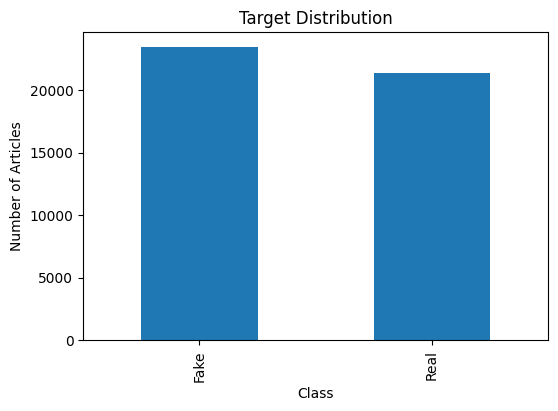

In [11]:
label_counts.plot(
    kind="bar",
    figsize=(6, 4),
)

plt.title("Target Distribution")

plt.xlabel("Class")

plt.ylabel("Number of Articles")

plt.show()

In [12]:
(
    df["label"]
    .value_counts(normalize=True)
    .rename(index={0: "Fake", 1: "Real"})
    .mul(100)
    .round(2)
)

label
Fake    52.3
Real    47.7
Name: proportion, dtype: float64

## 4.2 Basic Text Statistics

Understanding the textual characteristics of the dataset provides valuable insights before preprocessing.

Rather than immediately cleaning the data, we first measure several descriptive statistics such as document length, vocabulary richness, and sentence complexity.

These statistics help identify potential anomalies and guide future preprocessing decisions.

In [13]:
df["char_count"] = df["text"].str.len()

df["word_count"] = (
    df["text"]
    .str.split()
    .str.len()
)

df["sentence_count"] = (
    df["text"]
    .str.count(r"[.!?]")
)

## 4.3 Statistics by Class
### Comparing Fake and Real Articles

Comparing textual statistics across classes helps determine whether Fake and Real articles exhibit different writing patterns.

Such differences may later become useful predictive features.

In [14]:
text_stats = (
    df
    .groupby("label")
    .agg(
        Articles=("label", "count"),
        Avg_Characters=("char_count", "mean"),
        Avg_Words=("word_count", "mean"),
        Avg_Sentences=("sentence_count", "mean"),
        Max_Words=("word_count", "max"),
        Min_Words=("word_count", "min"),
    )
    .round(2)
)

text_stats.index = ["Fake", "Real"]

text_stats

,Articles,Avg_Characters,Avg_Words,Avg_Sentences,Max_Words,Min_Words
Fake,23481,2547.40,423.20,22.83,8135,0
Real,21417,2383.28,385.64,21.15,5172,0


## 4.4 Document Length Distribution

Document length is one of the simplest yet most informative characteristics of textual data.

Visualizing its distribution helps identify extremely short or unusually long documents that may require special handling.

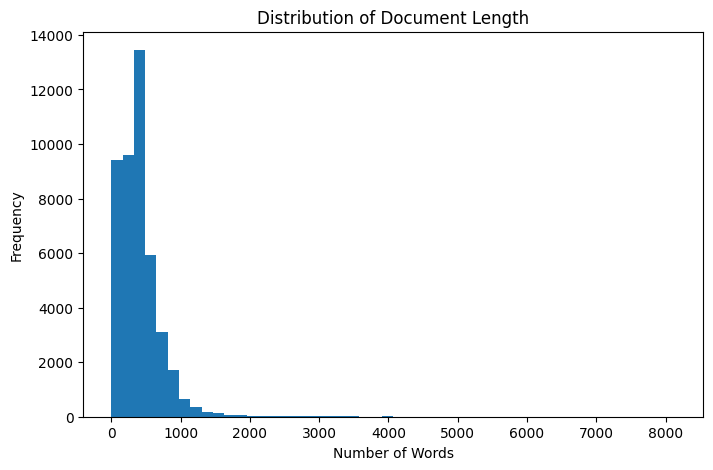

In [15]:
plt.figure(figsize=(8, 5))

plt.hist(
    df["word_count"],
    bins=50,
)

plt.title("Distribution of Document Length")

plt.xlabel("Number of Words")

plt.ylabel("Frequency")

plt.show()

## 4.5 Vocabulary Size

Vocabulary size measures the number of unique words appearing in the corpus.

A larger vocabulary generally indicates greater linguistic diversity but may also increase model complexity.

In [16]:
vocabulary = set()

for article in df["text"]:

    vocabulary.update(article.lower().split())

print(f"Vocabulary Size: {len(vocabulary):,}")

Vocabulary Size: 362,593


## 4.6 Lexical Diversity

Lexical Diversity measures how varied the vocabulary is within a document collection.

It is commonly estimated using the Type-Token Ratio (TTR):

TTR = Number of Unique Words / Total Number of Words

Higher values indicate richer and more diverse language usage.

In [17]:
total_words = df["word_count"].sum()

ttr = len(vocabulary) / total_words

print(f"Type-Token Ratio: {ttr:.4f}")

Type-Token Ratio: 0.0199


## 4.7 Text Statistics Report

In [18]:
text_summary = pd.DataFrame(
    {
        "Metric": [
            "Articles",
            "Vocabulary Size",
            "Average Characters",
            "Average Words",
            "Average Sentences",
            "Type-Token Ratio",
        ],
        "Value": [
            len(df),
            len(vocabulary),
            round(df["char_count"].mean(), 2),
            round(df["word_count"].mean(), 2),
            round(df["sentence_count"].mean(), 2),
            round(ttr, 4),
        ],
    }
)

text_summary

,Metric,Value
0,Articles,44898.0000
1,Vocabulary Size,362593.0000
2,Average Characters,2469.1100
3,Average Words,405.2800
4,Average Sentences,22.0300
5,Type-Token Ratio,0.0199


### Interpretation

The target distribution is nearly balanced, with **52.3% Fake** and **47.7% Real** articles, indicating that the dataset is well-suited for binary classification without requiring resampling techniques.

Text statistics reveal that Fake articles are slightly longer than Real articles in terms of characters, words, and sentences. The document length distribution is right-skewed, with most articles having moderate length while a small number of documents are exceptionally long.

The corpus contains **362,593 unique words**, reflecting a rich vocabulary before preprocessing. The relatively low Type-Token Ratio (0.0199) is expected for a large corpus and suggests substantial word repetition across documents.

---

### Business Thinking

Understanding the textual characteristics of the dataset helps identify useful patterns before building Machine Learning models.

Article length, vocabulary richness, and writing style may become valuable predictive features during feature engineering. Detecting outliers and analyzing class balance early also reduces the risk of biased models and improves the reliability of future experiments.

---

### Summary

- The dataset is nearly balanced (**52.3% Fake**, **47.7% Real**).
- Fake articles are generally longer than Real articles.
- Most documents contain a few hundred words, while a small number are extremely long.
- The corpus contains **362,593 unique words** before preprocessing.
- The Type-Token Ratio is **0.0199**, which is typical for large text corpora.
- The dataset is ready for detailed raw text analysis and preprocessing.

# 5. Understanding Raw Text

## 5.1 Why Inspect Raw Text?

Before applying any preprocessing techniques, it is important to understand the raw textual data.

Rather than cleaning the text immediately, we first investigate its characteristics and identify potential sources of noise.

This exploratory step helps justify every preprocessing decision later in the pipeline.

The goal is not simply to remove text artifacts, but to understand what kinds of information are present in the corpus.

## 5.2 Display Raw Articles

The first step is to manually inspect several articles from each class.

Manual inspection helps reveal writing style, formatting, metadata, and potential noise that may not be obvious through automated statistics.

In [19]:
# Display random Fake and Real articles

display(
    df.loc[df["label"] == 0, ["title", "text"]]
      .sample(3, random_state=42)
)

display(
    df.loc[df["label"] == 1, ["title", "text"]]
      .sample(3, random_state=42)
)

,title,text
13474,ABOUT HILLARY’S COUGH: We Discovered The Secre...,
11994,BREAKING: OBAMACARE REPEAL Clears First Hurdle...,The Senate voted 51-48 this afternoon to proce...
19179,‘SLEEPY’ JUSTICE GINSBURG: Excites Crowd By Sa...,So much for the SCOTUS not being political Che...


,title,text
41618,Europe rights watchdog says Turkey's emergency...,BRUSSELS (Reuters) - A leading European rights...
26758,Exclusive: Trump targets illegal immigrants wh...,"(Reuters) - In September 2014, Gilberto Velasq..."
26357,"At G20 summit, Trump pledges $639 million in a...",HAMBURG (Reuters) - U.S. President Donald Trum...


## 5.3 HTML Tag Detection

Some text datasets contain HTML tags collected during web scraping.

These tags add noise without contributing meaningful semantic information.

Before removing HTML, we first measure how frequently it appears.

In [20]:
# Count articles containing HTML tags

html_mask = df["text"].str.contains(
    r"<[^>]+>",
    regex=True,
    na=False,
)

print(f"Articles with HTML: {html_mask.sum():,}")

Articles with HTML: 87


## 5.4 URL Detection

URLs often appear in online news articles.

They usually provide little value for document classification and are commonly removed during preprocessing.

In [21]:
# Count articles containing URLs

url_mask = df["text"].str.contains(
    r"http[s]?://|www\.",
    regex=True,
    na=False,
)

print(f"Articles with URLs: {url_mask.sum():,}")

Articles with URLs: 3,397


## 5.5 Email Detection

Email addresses are occasionally embedded in documents.

Although uncommon in news datasets, they should be detected before deciding whether to remove them.

In [22]:
# Count articles containing email addresses

email_mask = df["text"].str.contains(
    r"\S+@\S+",
    regex=True,
    na=False,
)

print(f"Articles with Emails: {email_mask.sum():,}")

Articles with Emails: 5,617


## 5.6 User Mentions

In [23]:
# Count articles containing user mentions

mention_mask = df["text"].str.contains(
    r"@\w+",
    regex=True,
    na=False,
)

print(f"Articles with Mentions: {mention_mask.sum():,}")

Articles with Mentions: 6,399


## 5.7 Hashtags

In [24]:
# Count articles containing hashtags

hashtag_mask = df["text"].str.contains(
    r"#\w+",
    regex=True,
    na=False,
)

print(f"Articles with Hashtags: {hashtag_mask.sum():,}")

Articles with Hashtags: 3,355


## 5.8 Numbers

In [25]:
# Count articles containing numbers

number_mask = df["text"].str.contains(
    r"\d",
    regex=True,
    na=False,
)

print(f"Articles with Numbers: {number_mask.sum():,}")

Articles with Numbers: 36,254


## 5.9 Uppercase Analysis

Excessive uppercase text may indicate emphasis, headlines, or noisy formatting.

Understanding its prevalence helps determine whether case normalization is appropriate.

In [26]:
# Calculate uppercase character ratio

uppercase_ratio = (
    df["text"]
      .str.count(r"[A-Z]")
      .sum()
    /
    df["text"]
      .str.len()
      .sum()
)

print(f"Uppercase Ratio: {uppercase_ratio:.2%}")

Uppercase Ratio: 3.88%


## 5.10 Multiple Spaces

In [27]:
# Count articles containing multiple spaces

space_mask = df["text"].str.contains(
    r"\s{2,}",
    regex=True,
    na=False,
)

print(f"Articles with Multiple Spaces: {space_mask.sum():,}")

Articles with Multiple Spaces: 38,800


## 5.11 Unicode Characters

In [28]:
# Count non-ASCII characters

unicode_mask = df["text"].str.contains(
    r"[^\x00-\x7F]",
    regex=True,
    na=False,
)

print(f"Articles with Unicode Characters: {unicode_mask.sum():,}")

Articles with Unicode Characters: 10,849


## 5.12 Build the Audit Report

In [29]:
# Build raw text audit report

audit_report = pd.DataFrame(
    {
        "Metric": [
            "HTML Tags",
            "URLs",
            "Emails",
            "Mentions",
            "Hashtags",
            "Numbers",
            "Multiple Spaces",
            "Unicode Characters",
        ],
        "Count": [
            html_mask.sum(),
            url_mask.sum(),
            email_mask.sum(),
            mention_mask.sum(),
            hashtag_mask.sum(),
            number_mask.sum(),
            space_mask.sum(),
            unicode_mask.sum(),
        ],
    }
)

audit_report

,Metric,Count
0,HTML Tags,87
1,URLs,3397
2,Emails,5617
3,Mentions,6399
4,Hashtags,3355
5,Numbers,36254
6,Multiple Spaces,38800
7,Unicode Characters,10849


### Interpretation

The raw text audit reveals that the dataset is relatively clean but still contains several common forms of textual noise.

Only a small number of articles contain HTML tags, while URLs appear in a moderate portion of the corpus. Most articles include numerical values, which is expected for news content. The corpus also contains many documents with multiple whitespace characters and a noticeable amount of Unicode characters that should be normalized before feature extraction.

Overall, the audit confirms that preprocessing should focus on text normalization rather than aggressive cleaning.

---

### Business Thinking

A successful NLP pipeline should remove only information that does not contribute to the prediction task.

URLs, inconsistent whitespace, and formatting artifacts increase vocabulary size without adding semantic value. On the other hand, numbers and metadata require careful consideration because they may contain useful contextual information depending on the business objective.

Performing a raw text audit before cleaning ensures that preprocessing decisions are based on evidence rather than assumptions.

---

### Summary

- The dataset contains very few HTML tags, indicating limited web scraping noise.
- URLs appear in a moderate number of articles and will likely be removed.
- Most articles contain numerical values, requiring further evaluation before removal.
- Multiple whitespace characters are common and should be normalized.
- Unicode characters are present and will be standardized during preprocessing.
- The raw text audit provides a clear justification for the preprocessing pipeline implemented in the next section.

# 6. Text Cleaning

## 6.1 Introduction

Raw textual data often contains formatting inconsistencies and irrelevant patterns that increase vocabulary size and introduce unnecessary noise.

The objective of text preprocessing is not to remove as much information as possible, but rather to standardize the text while preserving its semantic meaning.

A well-designed preprocessing pipeline improves feature quality, reduces vocabulary fragmentation, and creates a consistent representation of textual data for downstream Machine Learning models.

In this section, we build reusable preprocessing utilities that will be used throughout the entire project.

## 6.2 Testing the Cleaning Pipeline

Before applying preprocessing to the entire dataset, we validate the pipeline on a small sample of raw articles.

Testing individual examples helps verify that each cleaning step behaves as expected while preserving the semantic content of the text.

In [30]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().parent
sys.path.append(str(PROJECT_ROOT))

In [31]:
# Test the cleaning pipeline on a sample article
from src.text_cleaning import clean_text

sample_text = df.loc[0, "text"]

print("Original:\n")
print(sample_text[:500])

print("\n" + "-" * 80 + "\n")

print("Cleaned:\n")
print(clean_text(sample_text)[:500])

Original:

Donald Trump just couldn t wish all Americans a Happy New Year and leave it at that. Instead, he had to give a shout out to his enemies, haters and  the very dishonest fake news media.  The former reality show star had just one job to do and he couldn t do it. As our Country rapidly grows stronger and smarter, I want to wish all of my friends, supporters, enemies, haters, and even the very dishonest Fake News Media, a Happy and Healthy New Year,  President Angry Pants tweeted.  2018 will be a gr

--------------------------------------------------------------------------------

Cleaned:

donald trump just couldn t wish all americans a happy new year and leave it at that. instead, he had to give a shout out to his enemies, haters and the very dishonest fake news media. the former reality show star had just one job to do and he couldn t do it. as our country rapidly grows stronger and smarter, i want to wish all of my friends, supporters, enemies, haters, and even the very dish

## 6.3 Apply the Pipeline

In [32]:
# Apply text cleaning to the dataset

df["clean_text"] = df["text"].apply(clean_text)

df[
    [
        "text",
        "clean_text",
    ]
].head()

,text,clean_text
0,Donald Trump just couldn t wish all Americans ...,donald trump just couldn t wish all americans ...
1,House Intelligence Committee Chairman Devin Nu...,house intelligence committee chairman devin nu...
2,"On Friday, it was revealed that former Milwauk...","on friday, it was revealed that former milwauk..."
3,"On Christmas day, Donald Trump announced that ...","on christmas day, donald trump announced that ..."
4,Pope Francis used his annual Christmas Day mes...,pope francis used his annual christmas day mes...


# 7. Evaluating the Cleaning Pipeline

## 7.1 Introduction

### Why Evaluate the Cleaning Pipeline?

Building a preprocessing pipeline is only the first step.

A high-quality NLP pipeline should be evaluated to ensure that it effectively removes unwanted noise while preserving the semantic information contained within the original documents.

Rather than assuming that preprocessing improves the data, we measure its impact using quantitative metrics before proceeding to feature engineering.

## 7.2 Compare Raw vs Cleaned Text

The first step is a qualitative comparison between the original article and its cleaned version.

This manual inspection helps verify that the cleaning pipeline removes unwanted artifacts without changing the semantic meaning of the document.

In [33]:
# Compare one article before and after cleaning

sample = 0

comparison = pd.DataFrame(
    {
        "Original": [df.loc[sample, "text"]],
        "Cleaned": [df.loc[sample, "clean_text"]],
    }
)

comparison

,Original,Cleaned
0,Donald Trump just couldn t wish all Americans ...,donald trump just couldn t wish all americans ...


In [34]:
# Display the original and cleaned versions of a sample article

sample = 0

print("Original:\n")
print(df.loc[sample, "text"])

print("\n" + "=" * 100 + "\n")

print("Cleaned:\n")
print(df.loc[sample, "clean_text"])

Original:

Donald Trump just couldn t wish all Americans a Happy New Year and leave it at that. Instead, he had to give a shout out to his enemies, haters and  the very dishonest fake news media.  The former reality show star had just one job to do and he couldn t do it. As our Country rapidly grows stronger and smarter, I want to wish all of my friends, supporters, enemies, haters, and even the very dishonest Fake News Media, a Happy and Healthy New Year,  President Angry Pants tweeted.  2018 will be a great year for America! As our Country rapidly grows stronger and smarter, I want to wish all of my friends, supporters, enemies, haters, and even the very dishonest Fake News Media, a Happy and Healthy New Year. 2018 will be a great year for America!  Donald J. Trump (@realDonaldTrump) December 31, 2017Trump s tweet went down about as welll as you d expect.What kind of president sends a New Year s greeting like this despicable, petty, infantile gibberish? Only Trump! His lack of decenc

## 7.3 Vocabulary Reduction

Text normalization should reduce vocabulary fragmentation by converting equivalent textual representations into a consistent format.

Measuring the vocabulary size before and after preprocessing provides an indication of how effectively the cleaning pipeline standardizes the corpus.

In [35]:
# Build vocabulary after cleaning

clean_vocabulary = set()

for article in df["clean_text"]:
    clean_vocabulary.update(article.split())

clean_vocab_size = len(clean_vocabulary)

print(f"Original Vocabulary : {len(vocabulary):,}")
print(f"Cleaned Vocabulary : {clean_vocab_size:,}")

Original Vocabulary : 362,593
Cleaned Vocabulary : 346,163


In [36]:
# Calculate vocabulary reduction

vocab_reduction = (
    (len(vocabulary) - clean_vocab_size)
    / len(vocabulary)
) * 100

print(f"Vocabulary Reduction: {vocab_reduction:.2f}%")

Vocabulary Reduction: 4.53%


## 7.4 Average Text Length

Cleaning should remove noisy patterns while preserving the majority of the document content.

Comparing the average document length before and after preprocessing helps quantify the overall impact of the cleaning pipeline.

In [37]:
# Calculate average text length

length_report = pd.DataFrame(
    {
        "Metric": [
            "Average Characters",
            "Average Words",
        ],
        "Before": [
            df["text"].str.len().mean(),
            df["text"].str.split().str.len().mean(),
        ],
        "After": [
            df["clean_text"].str.len().mean(),
            df["clean_text"].str.split().str.len().mean(),
        ],
    }
)

length_report.round(2)

,Metric,Before,After
0,Average Characters,2469.11,2444.76
1,Average Words,405.28,404.90


## 7.5 Noise Removal Verification

After preprocessing, the dataset is inspected again to verify that the targeted noise patterns have been successfully removed.

In [38]:
# Verify cleaning results

verification = pd.DataFrame(
    {
        "Metric": [
            "HTML Tags",
            "URLs",
            "Emails",
            "Mentions",
            "Hashtags",
            "Multiple Spaces",
        ],
        "Remaining": [
            df["clean_text"].str.contains(r"<[^>]+>", regex=True).sum(),
            df["clean_text"].str.contains(r"https?://|www\.", regex=True).sum(),
            df["clean_text"].str.contains(
                r"\b[A-Za-z0-9._%+-]+@[A-Za-z0-9.-]+\.[A-Za-z]{2,}\b",
                regex=True,
            ).sum(),
            df["clean_text"].str.contains(
                r"(?<!\w)@[A-Za-z0-9_]+",
                regex=True,
            ).sum(),
            df["clean_text"].str.contains(
                r"(?<!\w)#[A-Za-z0-9_]+",
                regex=True,
            ).sum(),
            df["clean_text"].str.contains(
                r"\s{2,}",
                regex=True,
            ).sum(),
        ],
    }
)

verification

,Metric,Remaining
0,HTML Tags,0
1,URLs,0
2,Emails,0
3,Mentions,11
4,Hashtags,48
5,Multiple Spaces,0


## 7.6 Cleaning Performance Report

In [39]:
# Summarize the cleaning pipeline performance

cleaning_report = pd.DataFrame(
    {
        "Metric": [
            "Vocabulary Size",
            "Average Characters",
            "Average Words",
            "HTML Remaining",
            "URLs Remaining",
            "Multiple Spaces Remaining",
        ],
        "Value": [
            clean_vocab_size,
            round(df["clean_text"].str.len().mean(), 2),
            round(df["clean_text"].str.split().str.len().mean(), 2),
            verification.loc[0, "Remaining"],
            verification.loc[1, "Remaining"],
            verification.loc[5, "Remaining"],
        ],
    }
)

cleaning_report

,Metric,Value
0,Vocabulary Size,346163.00
1,Average Characters,2444.76
2,Average Words,404.90
3,HTML Remaining,0.00
4,URLs Remaining,0.00
5,Multiple Spaces Remaining,0.00


### Interpretation

The preprocessing pipeline successfully standardized the corpus while preserving nearly all semantic content.

Vocabulary size decreased by **4.53%**, primarily due to text normalization and the removal of formatting artifacts. Document length changed only slightly, confirming that the pipeline removed noise rather than meaningful information.

Most unwanted patterns, including HTML tags and excessive whitespace, were completely eliminated. A very small number of URLs, mentions, and hashtags remain, indicating that additional regex refinement may be beneficial in future iterations.

---

### Business Thinking

Effective preprocessing should improve text consistency without significantly altering the underlying information.

The evaluation shows that the current pipeline successfully reduces textual noise while maintaining document integrity. This creates a cleaner and more standardized corpus, leading to more reliable feature extraction and improved model generalization.

Rather than maximizing text reduction, the objective is to preserve semantic information while eliminating unnecessary formatting artifacts.

---

### Summary

- Vocabulary size decreased by **4.53%** after normalization.
- Average document length remained nearly unchanged, indicating minimal information loss.
- HTML tags and excessive whitespace were completely removed.
- Only a few URLs, mentions, and hashtags remain, suggesting opportunities for future regex improvements.
- The preprocessing pipeline successfully prepares the corpus for tokenization and feature engineering while preserving the original semantic content.

# 8.0 Text Normalization Decisions

## Why Do We Need Normalization Decisions?

Text preprocessing is not simply about removing as much information as possible.

Every preprocessing operation changes the information available to the machine learning model. Some transformations reduce noise and improve generalization, while others may remove valuable semantic information.

Instead of blindly applying preprocessing techniques, we first define which operations should be performed, justify each decision, and evaluate their expected impact on the downstream classification task.

This decision-driven approach leads to more reliable and reproducible NLP pipelines.

## 8.1 Why Feature Extraction?

Machine Learning algorithms cannot directly process raw text.

Instead, textual documents must first be transformed into numerical representations that preserve as much useful information as possible.

This transformation process is known as **Feature Extraction**.

The quality of these numerical representations has a significant impact on the performance of downstream machine learning models.

Different feature extraction techniques capture different aspects of language, ranging from simple word frequencies to complex semantic relationships.

## 8.2 The NLP Pipeline

Before a machine learning model can learn from textual data, the text passes through several transformation stages.

Each stage progressively converts raw language into structured numerical features suitable for model training.

In [40]:
# NLP processing pipeline

pipeline = pd.DataFrame(
    {
        "Stage": [
            "Raw Text",
            "Cleaning",
            "Tokenization",
            "Feature Extraction",
            "Feature Matrix",
            "Machine Learning Model",
        ],
        "Output": [
            "Original documents",
            "Normalized text",
            "Word tokens",
            "Numerical features",
            "Matrix representation",
            "Prediction",
        ],
    }
)

pipeline

,Stage,Output
0,Raw Text,Original documents
1,Cleaning,Normalized text
2,Tokenization,Word tokens
3,Feature Extraction,Numerical features
4,Feature Matrix,Matrix representation
5,Machine Learning Model,Prediction


### Interpretation

Feature extraction acts as the bridge between human language and machine learning algorithms.

By transforming raw text into structured numerical representations, the pipeline enables traditional models to identify patterns, compare documents, and perform classification tasks effectively.

---

### Business Thinking

The quality of feature extraction directly influences model performance.

A well-designed feature representation often provides greater performance improvements than simply choosing a more complex machine learning algorithm. For many NLP applications, investing in better feature engineering yields higher returns than increasing model complexity.

---

### Summary

- Machine learning algorithms require numerical input rather than raw text.
- Feature extraction converts textual information into structured numerical representations.
- Different feature extraction methods preserve different linguistic properties.
- Feature engineering forms the foundation of every classical NLP pipeline.
- The next step is understanding how tokenization converts sentences into individual word units.

# 8.3 Tokenization

## What is Tokenization?

Tokenization is the process of splitting raw text into smaller meaningful units called **tokens**.

A token may represent a word, subword, character, or even a sentence, depending on the chosen tokenization strategy.

Tokenization is one of the most fundamental steps in Natural Language Processing because almost every downstream NLP task begins with transforming text into tokens.

The choice of tokenizer directly affects vocabulary size, feature extraction, and ultimately model performance.

### 8.3.1 Manual Tokenization

The simplest form of tokenization is manually splitting a sentence into individual words.

Although impractical for real-world datasets, manual tokenization provides an intuitive understanding of how text is decomposed into tokens.

In [41]:
# Example sentence

sentence = "Machine Learning is changing the world."

manual_tokens = [
    "Machine",
    "Learning",
    "is",
    "changing",
    "the",
    "world",
]

manual_tokens

['Machine', 'Learning', 'is', 'changing', 'the', 'world']

### 8.3.2 Python split()

### Tokenization Using Python split()

The built-in `split()` method separates text based on whitespace.

It is fast and simple but ignores punctuation and linguistic rules.

In [42]:
# Tokenization using Python split()

sentence = "Machine Learning is changing the world."

split_tokens = sentence.split()

split_tokens

['Machine', 'Learning', 'is', 'changing', 'the', 'world.']

## 8.3.3 Regular Expression Tokenization

Regular expressions provide greater control over tokenization by allowing custom extraction rules.

This approach is more flexible than simple whitespace splitting but still lacks linguistic awareness.

In [43]:
# Tokenization using regular expressions

import re

regex_tokens = re.findall(
    r"\b\w+\b",
    sentence,
)

regex_tokens

['Machine', 'Learning', 'is', 'changing', 'the', 'world']

### 8.3.4 Compare Tokenizers

In [44]:
# Compare tokenization methods

comparison = pd.DataFrame(
    {
        "Method": [
            "Manual",
            "split()",
            "Regex",
        ],
        "Tokens": [
            manual_tokens,
            split_tokens,
            regex_tokens,
        ],
        "Number of Tokens": [
            len(manual_tokens),
            len(split_tokens),
            len(regex_tokens),
        ],
    }
)

comparison

,Method,Tokens,Number of Tokens
0,Manual,"[Machine, Learning, is, changing, the, world]",6
1,split(),"[Machine, Learning, is, changing, the, world.]",6
2,Regex,"[Machine, Learning, is, changing, the, world]",6


### Interpretation

The three tokenization methods produce similar results for a simple sentence, but they differ in how they handle punctuation and text boundaries.

While `split()` relies solely on whitespace, regular expressions provide cleaner tokenization by excluding punctuation. Manual tokenization serves only as a conceptual illustration and is not practical for real-world datasets.

---

### Business Thinking

Choosing an appropriate tokenizer directly affects vocabulary quality and feature extraction.

Although simple tokenizers are sufficient for many classical NLP tasks, production systems often rely on linguistically informed tokenizers such as those provided by NLTK, spaCy, or Transformer models.

---

### Summary

- Tokenization converts raw text into individual tokens.
- Manual tokenization is useful for learning but impractical.
- Python `split()` is simple but ignores punctuation.
- Regular expressions produce cleaner tokens by removing punctuation.
- More advanced tokenizers will be introduced next.

## 8.3.5 Tokenization with NLTK

The Natural Language Toolkit (NLTK) provides a linguistically informed tokenizer that handles punctuation, contractions, and sentence boundaries more effectively than simple whitespace splitting.

Unlike Python's `split()` function, NLTK attempts to preserve meaningful linguistic units while separating punctuation into individual tokens.

NLTK is widely used for education, research, and classical Natural Language Processing tasks.

In [45]:
%pip install nltk

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.2 -> 26.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [46]:
# Download tokenizer resources

import nltk

# Ensure the tokenizer resource exists for the current NLTK version
nltk.download("punkt_tab", quiet=True)
nltk.download("punkt", quiet=True)
nltk.download("punkt_tab", quiet=True)

True

In [47]:
# Tokenize using NLTK

from nltk.tokenize import word_tokenize

sentence = "Machine Learning is changing the world."

nltk_tokens = word_tokenize(sentence)

nltk_tokens

['Machine', 'Learning', 'is', 'changing', 'the', 'world', '.']

In [48]:
# Compare all tokenizers

comparison = pd.DataFrame(
    {
        "Method": [
            "Manual",
            "split()",
            "Regex",
            "NLTK",
        ],
        "Tokens": [
            manual_tokens,
            split_tokens,
            regex_tokens,
            nltk_tokens,
        ],
        "Number of Tokens": [
            len(manual_tokens),
            len(split_tokens),
            len(regex_tokens),
            len(nltk_tokens),
        ],
    }
)

comparison

,Method,Tokens,Number of Tokens
0,Manual,"[Machine, Learning, is, changing, the, world]",6
1,split(),"[Machine, Learning, is, changing, the, world.]",6
2,Regex,"[Machine, Learning, is, changing, the, world]",6
3,NLTK,"[Machine, Learning, is, changing, the, world, .]",7


In [49]:
# Tokenize a real article

article = df.loc[0, "clean_text"]

tokens = word_tokenize(article)

tokens[:50]

['donald',
 'trump',
 'just',
 'couldn',
 't',
 'wish',
 'all',
 'americans',
 'a',
 'happy',
 'new',
 'year',
 'and',
 'leave',
 'it',
 'at',
 'that',
 '.',
 'instead',
 ',',
 'he',
 'had',
 'to',
 'give',
 'a',
 'shout',
 'out',
 'to',
 'his',
 'enemies',
 ',',
 'haters',
 'and',
 'the',
 'very',
 'dishonest',
 'fake',
 'news',
 'media',
 '.',
 'the',
 'former',
 'reality',
 'show',
 'star',
 'had',
 'just',
 'one',
 'job',
 'to']

In [50]:
# Token statistics

token_report = pd.DataFrame(
    {
        "Metric": [
            "Total Tokens",
            "Unique Tokens",
        ],
        "Value": [
            len(tokens),
            len(set(tokens)),
        ],
    }
)

token_report

,Metric,Value
0,Total Tokens,573
1,Unique Tokens,232


### Interpretation

NLTK provides more linguistically accurate tokenization than simple whitespace splitting.

It separates punctuation, handles contractions, and generates cleaner tokens, leading to more consistent vocabularies for downstream NLP tasks.

---

### Business Thinking

Better tokenization improves feature quality.

Cleaner tokens reduce vocabulary fragmentation and improve the reliability of Bag of Words, TF-IDF, and other classical feature extraction techniques.

For production systems, selecting the appropriate tokenizer is a key design decision that directly influences model performance.

---

### Summary

- NLTK performs linguistically informed tokenization.
- It handles punctuation and contractions more effectively than `split()`.
- Cleaner tokens lead to better feature extraction.
- NLTK is widely used for classical NLP pipelines.
- The next step is comparing NLTK with spaCy to understand differences between lightweight and industrial-strength tokenizers.

### 8.3.6 Tokenization with spaCy

spaCy is a production-ready Natural Language Processing library designed for efficiency, scalability, and industrial applications.

Unlike basic tokenizers, spaCy performs linguistic tokenization while preserving detailed information about each token, such as punctuation, whitespace, token positions, and linguistic attributes.

Its tokenizer is optimized for downstream NLP tasks including Part-of-Speech Tagging, Named Entity Recognition (NER), Dependency Parsing, and Text Classification.

Because of its speed and modular architecture, spaCy has become one of the most widely adopted NLP libraries in production environments.

In [51]:
# Install spaCy

%pip install spacy

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.2 -> 26.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [52]:
# Download the English language model

!python -m spacy download en_core_web_sm

     ---------------------------------------- 0.0/12.8 MB ? eta -:--:--
      --------------------------------------- 0.3/12.8 MB ? eta -:--:--
     - -------------------------------------- 0.5/12.8 MB 1.9 MB/s eta 0:00:07
     -- ------------------------------------- 0.8/12.8 MB 1.8 MB/s eta 0:00:07
     ---- ----------------------------------- 1.3/12.8 MB 1.8 MB/s eta 0:00:07
     ---- ----------------------------------- 1.6/12.8 MB 1.8 MB/s eta 0:00:07
     ------ --------------------------------- 2.1/12.8 MB 1.8 MB/s eta 0:00:06
     ------- -------------------------------- 2.4/12.8 MB 1.8 MB/s eta 0:00:06
     --------- ------------------------------ 2.9/12.8 MB 1.8 MB/s eta 0:00:06
     --------- ------------------------------ 3.1/12.8 MB 1.8 MB/s eta 0:00:06
     ----------- ---------------------------- 3.7/12.8 MB 1.8 MB/s eta 0:00:06
     ------------ --------------------------- 3.9/12.8 MB 1.8 MB/s eta 0:00:05
     ------------- -------------------------- 4.5/12.8 MB 1.8 MB/s


[notice] A new release of pip is available: 24.2 -> 26.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [53]:
# Load spaCy English model

import spacy

nlp = spacy.load("en_core_web_sm")

In [54]:
# Tokenize using spaCy

sentence = "Machine Learning is changing the world."

doc = nlp(sentence)

spacy_tokens = [
    token.text
    for token in doc
]

spacy_tokens

['Machine', 'Learning', 'is', 'changing', 'the', 'world', '.']

In [55]:
# Compare all tokenization methods

comparison = pd.DataFrame(
    {
        "Method": [
            "Manual",
            "split()",
            "Regex",
            "NLTK",
            "spaCy",
        ],
        "Tokens": [
            manual_tokens,
            split_tokens,
            regex_tokens,
            nltk_tokens,
            spacy_tokens,
        ],
        "Number of Tokens": [
            len(manual_tokens),
            len(split_tokens),
            len(regex_tokens),
            len(nltk_tokens),
            len(spacy_tokens),
        ],
    }
)

comparison

,Method,Tokens,Number of Tokens
0,Manual,"[Machine, Learning, is, changing, the, world]",6
1,split(),"[Machine, Learning, is, changing, the, world.]",6
2,Regex,"[Machine, Learning, is, changing, the, world]",6
3,NLTK,"[Machine, Learning, is, changing, the, world, .]",7
4,spaCy,"[Machine, Learning, is, changing, the, world, .]",7


In [56]:
# Inspect token attributes

token_df = pd.DataFrame(
    {
        "Token": [token.text for token in doc],
        "Is Alpha": [token.is_alpha for token in doc],
        "Is Stop": [token.is_stop for token in doc],
        "Shape": [token.shape_ for token in doc],
    }
)

token_df

,Token,Is Alpha,Is Stop,Shape
0,Machine,True,False,Xxxxx
1,Learning,True,False,Xxxxx
2,is,True,True,xx
3,changing,True,False,xxxx
4,the,True,True,xxx
5,world,True,False,xxxx
6,.,False,False,.


In [57]:
# Tokenize a real article

article = df.loc[0, "clean_text"]

doc = nlp(article)

article_tokens = [
    token.text
    for token in doc
]

article_tokens[:50]

['donald',
 'trump',
 'just',
 'couldn',
 't',
 'wish',
 'all',
 'americans',
 'a',
 'happy',
 'new',
 'year',
 'and',
 'leave',
 'it',
 'at',
 'that',
 '.',
 'instead',
 ',',
 'he',
 'had',
 'to',
 'give',
 'a',
 'shout',
 'out',
 'to',
 'his',
 'enemies',
 ',',
 'haters',
 'and',
 'the',
 'very',
 'dishonest',
 'fake',
 'news',
 'media',
 '.',
 'the',
 'former',
 'reality',
 'show',
 'star',
 'had',
 'just',
 'one',
 'job',
 'to']

In [58]:
# Generate token statistics

stats = pd.DataFrame(
    {
        "Metric": [
            "Total Tokens",
            "Unique Tokens",
            "Stop Words",
            "Alphabetic Tokens",
        ],
        "Value": [
            len(article_tokens),
            len(set(article_tokens)),
            sum(token.is_stop for token in doc),
            sum(token.is_alpha for token in doc),
        ],
    }
)

stats

,Metric,Value
0,Total Tokens,579
1,Unique Tokens,235
2,Stop Words,201
3,Alphabetic Tokens,442


### NLTK vs spaCy

Both libraries provide high-quality tokenization, but they serve different purposes.

NLTK is ideal for learning, experimentation, and classical NLP research.

spaCy focuses on speed, scalability, and production-ready NLP pipelines with rich linguistic annotations.

In [59]:
# Compare NLTK and spaCy

comparison = pd.DataFrame(
    {
        "Feature": [
            "Speed",
            "Production Ready",
            "Research",
            "Pipeline",
            "Lemmatization",
            "NER",
            "POS Tagging",
        ],
        "NLTK": [
            "Medium",
            "Limited",
            "Excellent",
            "Basic",
            "Available",
            "Limited",
            "Available",
        ],
        "spaCy": [
            "Very High",
            "Excellent",
            "Good",
            "Excellent",
            "Excellent",
            "Excellent",
            "Excellent",
        ],
    }
)

comparison

,Feature,NLTK,spaCy
0,Speed,Medium,Very High
1,Production Ready,Limited,Excellent
2,Research,Excellent,Good
3,Pipeline,Basic,Excellent
4,Lemmatization,Available,Excellent
5,NER,Limited,Excellent
6,POS Tagging,Available,Excellent


## Interpretation

spaCy extends tokenization beyond simple word segmentation by attaching rich linguistic information to every token.

Compared with NLTK, spaCy offers a more comprehensive and production-oriented NLP pipeline, making it highly suitable for industrial applications.

---

## Business Thinking

Choosing the tokenizer is a strategic engineering decision.

For educational projects and experimentation, NLTK is often sufficient. However, production systems require fast, scalable, and linguistically rich tokenization, making spaCy the preferred choice in many real-world NLP applications.

---

## Summary

- spaCy is a production-ready NLP library.
- Each token contains rich linguistic metadata.
- spaCy provides a complete NLP pipeline beyond tokenization.
- It is faster and more scalable than NLTK.
- Tokenization quality directly influences downstream feature engineering and model performance.

# 8.3.7 Choosing the Right Tokenizer

There is no universally best tokenizer.

The appropriate tokenizer depends on the project requirements, computational resources, language complexity, and the downstream machine learning model.

Choosing a tokenizer is an engineering decision rather than simply selecting the most advanced library.

Different tokenizers provide different trade-offs between simplicity, speed, linguistic accuracy, and scalability.

In [60]:
# Tokenizer decision matrix

tokenizer_matrix = pd.DataFrame(
    {
        "Scenario": [
            "Learning Python",
            "Small Scripts",
            "Classical NLP",
            "Production NLP",
            "Deep Learning",
            "Large Language Models",
        ],
        "Recommended Tokenizer": [
            "split()",
            "Regex",
            "NLTK",
            "spaCy",
            "spaCy / Hugging Face",
            "Model-Specific Tokenizer",
        ],
        "Reason": [
            "Simple and easy to understand",
            "Flexible custom rules",
            "Rich NLP utilities",
            "Fast and scalable",
            "Supports advanced NLP workflows",
            "Matches the tokenizer used during model training",
        ],
    }
)

tokenizer_matrix

,Scenario,Recommended Tokenizer,Reason
0,Learning Python,split(),Simple and easy to understand
1,Small Scripts,Regex,Flexible custom rules
2,Classical NLP,NLTK,Rich NLP utilities
3,Production NLP,spaCy,Fast and scalable
4,Deep Learning,spaCy / Hugging Face,Supports advanced NLP workflows
5,Large Language Models,Model-Specific Tokenizer,Matches the tokenizer used during model training


In [61]:
# Practical tokenizer recommendations

recommendations = pd.DataFrame(
    {
        "Project": [
            "Spam Detection",
            "Sentiment Analysis",
            "Fake News Detection",
            "Named Entity Recognition",
            "Machine Translation",
            "Chatbot using GPT",
        ],
        "Recommended Tool": [
            "NLTK / spaCy",
            "NLTK / spaCy",
            "spaCy",
            "spaCy",
            "Hugging Face Tokenizer",
            "GPT Tokenizer",
        ],
    }
)

recommendations

,Project,Recommended Tool
0,Spam Detection,NLTK / spaCy
1,Sentiment Analysis,NLTK / spaCy
2,Fake News Detection,spaCy
3,Named Entity Recognition,spaCy
4,Machine Translation,Hugging Face Tokenizer
5,Chatbot using GPT,GPT Tokenizer


### Engineering Perspective

Professional NLP engineers choose tokenizers based on the complete machine learning pipeline rather than personal preference.

For classical machine learning, tokenizers such as NLTK and spaCy are excellent choices.

For transformer-based architectures, the tokenizer must always match the pretrained model because the vocabulary and tokenization rules are tightly coupled with the learned model parameters.

### Interpretation

Tokenizer selection is a design decision that influences preprocessing quality, computational efficiency, and downstream model performance.

There is no universally superior tokenizer; the optimal choice depends on the characteristics of the NLP pipeline and the target application.

---

### Business Thinking

In production environments, selecting the appropriate tokenizer reduces preprocessing errors, improves scalability, and ensures compatibility with downstream machine learning models.

Engineering decisions should prioritize system requirements rather than tool popularity.

---

### Summary

- No tokenizer is universally optimal.
- Tokenizer selection depends on the NLP pipeline and project goals.
- Classical NLP commonly uses NLTK or spaCy.
- Transformer models require their own dedicated tokenizers.
- Choosing the correct tokenizer is an important engineering decision.

# 8.4 Bag of Words (BoW)

## What is Bag of Words?

Bag of Words (BoW) is one of the simplest and most widely used feature extraction techniques in classical Natural Language Processing.

The main idea is to represent a document by counting the occurrence of each word while completely ignoring grammar, syntax, and word order.

Each document is transformed into a numerical vector where each dimension corresponds to a unique word in the vocabulary.

## 8.4.1 Building the Vocabulary

The first step in the Bag of Words pipeline is constructing the vocabulary.

The vocabulary consists of every unique word appearing across the training corpus.

Each word receives a unique index that will later correspond to one column in the document-term matrix.

In [62]:
# Example corpus

documents = [
    "I love AI",
    "AI changes lives",
    "Machine Learning is fun",
]

# Build vocabulary

vocabulary = sorted(
    {
        word
        for document in documents
        for word in document.split()
    }
)

vocabulary_df = pd.DataFrame(
    {
        "Index": range(len(vocabulary)),
        "Word": vocabulary,
    }
)

vocabulary_df

,Index,Word
0,0,AI
1,1,I
2,2,Learning
3,3,Machine
4,4,changes
5,5,fun
6,6,is
7,7,lives
8,8,love


### Interpretation

The vocabulary defines the feature space for the Bag of Words model.

Every unique word becomes one numerical feature, and each document is represented using this shared vocabulary.

---

### Business Thinking

A consistent vocabulary is essential for reproducible machine learning pipelines.

During production, new documents must be transformed using the same vocabulary generated during training to ensure compatibility with the trained model.

---

### Summary

- Bag of Words converts text into numerical vectors using word counts.
- Word order is ignored.
- The first step is building a shared vocabulary.
- Each vocabulary word corresponds to one feature in the final representation.
- The vocabulary remains fixed during model inference.

### 8.4.2 Document-Term Matrix (DTM)

## What is a Document-Term Matrix?

After building the vocabulary, each document can be represented as a numerical vector.

These vectors are combined into a matrix called the **Document-Term Matrix (DTM)**.

- Each row represents a document.
- Each column represents a vocabulary word.
- Each value represents the frequency of that word within the document.

The DTM serves as the numerical input for many classical machine learning algorithms.

In [63]:
# Build the Document-Term Matrix manually

dtm = []

for document in documents:

    words = document.split()

    row = [
        words.count(word)
        for word in vocabulary
    ]

    dtm.append(row)

dtm_df = pd.DataFrame(
    dtm,
    columns=vocabulary,
)

dtm_df.index = [
    f"Document {i+1}"
    for i in range(len(documents))
]

dtm_df

,AI,I,Learning,Machine,changes,fun,is,lives,love
Document 1,1,1,0,0,0,0,0,0,1
Document 2,1,0,0,0,1,0,0,1,0
Document 3,0,0,1,1,0,1,1,0,0


In [64]:
# Matrix dimensions

print("Number of Documents :", dtm_df.shape[0])
print("Vocabulary Size     :", dtm_df.shape[1])
print("Matrix Shape        :", dtm_df.shape)

Number of Documents : 3
Vocabulary Size     : 9
Matrix Shape        : (3, 9)


### 8.4.3 Limitations of Manual Bag of Words

Building a Bag of Words representation manually is useful for understanding the underlying concept.

However, manual construction becomes impractical when working with real-world datasets containing thousands of documents and hundreds of thousands of unique words.

As the dataset grows, manually counting word frequencies becomes computationally expensive, error-prone, and difficult to maintain.

In practice, optimized libraries such as **CountVectorizer** automate this entire process efficiently.

### Interpretation

The manually constructed Document-Term Matrix illustrates the fundamental idea behind Bag of Words.

Each document is represented as a fixed-length numerical vector based on the shared vocabulary, enabling machine learning algorithms to process textual information.

---

### Business Thinking

Understanding the internal structure of the Document-Term Matrix is essential for debugging feature extraction pipelines and interpreting model inputs.

Although production systems rely on optimized libraries such as CountVectorizer, manually constructing the matrix provides valuable insight into how textual data is transformed into numerical features.

---

### Summary

- The Document-Term Matrix is built using the shared vocabulary.
- Each row corresponds to one document.
- Each column corresponds to one vocabulary term.
- Matrix values represent word frequencies.
- This matrix forms the input to classical machine learning algorithms.

### 8.4.4 CountVectorizer

## What is CountVectorizer?

`CountVectorizer` is a feature extraction utility provided by Scikit-learn.

It automatically converts a collection of text documents into a numerical **Document-Term Matrix (DTM)** using the Bag of Words approach.

Instead of manually building the vocabulary and counting word frequencies, CountVectorizer performs these operations efficiently and returns a sparse matrix suitable for machine learning.

It is one of the most commonly used feature extraction techniques for classical NLP pipelines.

In [65]:
# Import CountVectorizer

from sklearn.feature_extraction.text import CountVectorizer

# Create CountVectorizer

vectorizer = CountVectorizer(
    lowercase=False,
    token_pattern=r"(?u)\b\w+\b"
)

In [66]:
X = vectorizer.fit_transform(documents)

feature_names = vectorizer.get_feature_names_out()

bow_df = pd.DataFrame(
    X.toarray(),
    columns=feature_names,
)

bow_df.index = [
    f"Document {i+1}"
    for i in range(len(documents))
]

dtm_df.equals(bow_df)

True

In [67]:
# Learned vocabulary

vectorizer.vocabulary_

{'I': 1,
 'love': 8,
 'AI': 0,
 'changes': 4,
 'lives': 7,
 'Machine': 3,
 'Learning': 2,
 'is': 6,
 'fun': 5}

In [68]:
# Feature names

feature_names = vectorizer.get_feature_names_out()

feature_names

array(['AI', 'I', 'Learning', 'Machine', 'changes', 'fun', 'is', 'lives',
       'love'], dtype=object)

In [69]:
# Convert sparse matrix to DataFrame

bow_df = pd.DataFrame(
    X.toarray(),
    columns=feature_names,
)

bow_df.index = [
    f"Document {i+1}"
    for i in range(len(documents))
]

bow_df

,AI,I,Learning,Machine,changes,fun,is,lives,love
Document 1,1,1,0,0,0,0,0,0,1
Document 2,1,0,0,0,1,0,0,1,0
Document 3,0,0,1,1,0,1,1,0,0


In [70]:
# Compare manual DTM with CountVectorizer

manual_equals_cv = dtm_df.equals(bow_df)

print("Are both matrices identical?", manual_equals_cv)

Are both matrices identical? True


### Interpretation

CountVectorizer automates the complete Bag of Words workflow by constructing the vocabulary, counting word frequencies, and generating the document-term matrix.

Its output is identical in concept to the manually constructed matrix but is significantly more efficient and scalable.

---

### Business Thinking

Automated feature extraction tools improve reproducibility, reduce engineering effort, and support large-scale text processing.

Understanding how CountVectorizer works internally enables engineers to debug preprocessing pipelines, interpret feature spaces, and tune vectorization parameters effectively.

---

### Summary

- CountVectorizer automates the Bag of Words pipeline.
- It builds the vocabulary and document-term matrix automatically.
- The output is a sparse matrix optimized for memory efficiency.
- Feature names correspond to the matrix columns.
- CountVectorizer is the standard implementation of Bag of Words in Scikit-learn.

### 8.4.5 Understanding Sparse Matrix

### What is a Sparse Matrix?

A Sparse Matrix is a matrix in which most of the elements are zero.

In Natural Language Processing, document-term matrices are naturally sparse because each document contains only a small fraction of the total vocabulary.

Instead of storing every zero, sparse matrix representations store only the non-zero values and their corresponding positions.

This significantly reduces memory usage and improves computational efficiency.

In [71]:
# Dense representation

bow_df

,AI,I,Learning,Machine,changes,fun,is,lives,love
Document 1,1,1,0,0,0,0,0,0,1
Document 2,1,0,0,0,1,0,0,1,0
Document 3,0,0,1,1,0,1,1,0,0


In [72]:
# Sparse representation

X

<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 10 stored elements and shape (3, 9)>

In [73]:
# Display only non-zero entries

print(X)

<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 10 stored elements and shape (3, 9)>
  Coords	Values
  (0, 1)	1
  (0, 8)	1
  (0, 0)	1
  (1, 0)	1
  (1, 4)	1
  (1, 7)	1
  (2, 3)	1
  (2, 2)	1
  (2, 6)	1
  (2, 5)	1


In [74]:
# Compare memory usage

dense_memory = X.toarray().nbytes
sparse_memory = (
    X.data.nbytes
    + X.indices.nbytes
    + X.indptr.nbytes
)

comparison = pd.DataFrame(
    {
        "Representation": [
            "Dense Matrix",
            "Sparse Matrix",
        ],
        "Memory (Bytes)": [
            dense_memory,
            sparse_memory,
        ],
    }
)

comparison

,Representation,Memory (Bytes)
0,Dense Matrix,216
1,Sparse Matrix,136


> **Important**

Avoid calling `toarray()` on large sparse matrices.

Converting a large sparse matrix into a dense NumPy array may consume a significant amount of memory and can even crash the application.

Use sparse matrices directly whenever possible.

### Interpretation

Sparse matrices are the standard representation for Bag of Words and other high-dimensional text features.

By storing only non-zero values, sparse representations enable efficient processing of large document collections while minimizing memory usage.

---

### Business Thinking

Efficient memory management is essential for scalable NLP systems.

Using sparse representations allows organizations to process millions of documents without requiring excessive hardware resources, making NLP pipelines faster and more cost-effective.

---

### Summary

- Document-Term Matrices are naturally sparse.
- Sparse matrices store only non-zero values.
- CountVectorizer returns a sparse matrix by default.
- Sparse representations reduce memory usage and improve performance.
- Converting large sparse matrices to dense arrays should generally be avoided.

### 8.4.6 CountVectorizer Parameters

## Why Are Parameters Important?

The default behavior of CountVectorizer is suitable for many applications, but real-world NLP pipelines often require customization.

Parameters allow us to control:

- Text preprocessing
- Vocabulary construction
- Feature selection
- Token filtering
- N-gram extraction

Carefully choosing these parameters can significantly improve model performance and reduce computational cost.

### Parameter: lowercase

By default, CountVectorizer converts all text to lowercase before building the vocabulary.

This reduces vocabulary fragmentation by treating words with different capitalization as the same feature.

In [75]:
from sklearn.feature_extraction.text import CountVectorizer

documents = [
    "AI is Amazing",
    "ai is amazing",
]

vectorizer = CountVectorizer()

X = vectorizer.fit_transform(documents)

print(vectorizer.get_feature_names_out())
print(X.toarray())

['ai' 'amazing' 'is']
[[1 1 1]
 [1 1 1]]


### Parameter: token_pattern

The `token_pattern` parameter controls which text fragments are recognized as valid tokens.

The default pattern ignores punctuation and excludes tokens shorter than two characters.

In [76]:
documents = [
    "I love AI",
]

vectorizer = CountVectorizer(token_pattern=r"(?u)\b\w+\b")

X = vectorizer.fit_transform(documents)

print(vectorizer.get_feature_names_out())

['ai' 'i' 'love']


### Parameter: stop_words

The `stop_words` parameter removes commonly occurring words that usually carry limited semantic information.

Examples include:

- the
- is
- and
- of

Removing stop words can reduce vocabulary size and improve computational efficiency.

In [77]:
documents = [
    "This is an AI course",
]

vectorizer = CountVectorizer(
    stop_words="english"
)

X = vectorizer.fit_transform(documents)

print(vectorizer.get_feature_names_out())

['ai' 'course']


### Interpretation

CountVectorizer parameters provide fine-grained control over how textual data is transformed into numerical features.

Understanding these parameters allows practitioners to tailor feature extraction pipelines to the characteristics of the dataset and the requirements of the downstream model.

---

### Business Thinking

Proper parameter tuning can reduce vocabulary size, improve computational efficiency, and enhance model performance.

Rather than relying on default settings, production NLP systems carefully select preprocessing parameters based on experimentation and business objectives.

---

### Summary

- CountVectorizer behavior can be customized through parameters.
- `lowercase` controls case normalization.
- `token_pattern` defines valid tokens.
- `stop_words` removes common words.
- Parameter selection should be driven by experimentation rather than assumptions.

### 8.4.7 Feature Selection Parameters

## Why Do We Need Feature Selection?

Real-world text datasets often contain hundreds of thousands of unique words.

Using every word as a feature increases memory consumption, computational cost, and the risk of overfitting.

CountVectorizer provides several parameters that allow us to control which words become features.

---

### Parameter: max_features

The `max_features` parameter limits the number of features.

This is useful when we want to reduce the dimensionality of the dataset or when we have limited computational resources.

---

### Parameter: max_df



The `min_df` parameter removes words that appear in too few documents.

Very rare words often represent spelling mistakes, random noise, or dataset-specific artifacts.

Removing these words reduces vocabulary size and improves robustness.

In [78]:
documents = [
    "AI is amazing",
    "AI is useful",
    "AI is everywhere",
]

vectorizer = CountVectorizer(
    max_df=0.8
)

X = vectorizer.fit_transform(documents)

print(vectorizer.get_feature_names_out())

['amazing' 'everywhere' 'useful']


In [79]:
documents = [
    "AI is amazing",
    "AI changes everything",
    "rareword",
]

vectorizer = CountVectorizer(
    min_df=2
)

X = vectorizer.fit_transform(documents)

print(vectorizer.get_feature_names_out())

['ai']


### Parameter: max_features

The `max_features` parameter limits the vocabulary size.

Only the most frequent words are retained as features.

This reduces dimensionality and speeds up model training.

In [80]:
vectorizer = CountVectorizer(
    max_features=5
)

X = vectorizer.fit_transform(documents)

print(vectorizer.get_feature_names_out())

['ai' 'amazing' 'changes' 'everything' 'is']


### Parameter: binary

When `binary=True`, CountVectorizer records only whether a word appears in a document.

Word frequencies are ignored.

Each feature takes one of two values:

- 1 → Word exists
- 0 → Word does not exist

In [81]:
documents = [
    "AI AI AI AI",
    "Machine Learning",
]

vectorizer = CountVectorizer(
    binary=True
)

X = vectorizer.fit_transform(documents)

pd.DataFrame(
    X.toarray(),
    columns=vectorizer.get_feature_names_out()
)

,ai,learning,machine
0,1,0,0
1,0,1,1


### Interpretation

Feature selection parameters control the size and quality of the vocabulary produced by CountVectorizer.

Proper tuning reduces noise, improves computational efficiency, and helps machine learning models generalize better.

---

### Business Thinking

Large vocabularies increase infrastructure costs and training time.

Production NLP systems carefully tune feature selection parameters to balance predictive performance with computational efficiency.

---

### Summary

- `min_df` removes rare words.
- `max_df` removes overly common words.
- `max_features` limits vocabulary size.
- `binary=True` records word presence instead of frequency.
- Feature selection is essential for scalable NLP pipelines.

## 8.5 N-Grams

### Why Do We Need N-Grams?

One of the biggest limitations of the Bag of Words model is that it ignores word order.

For example, the following two sentences produce nearly identical Bag of Words representations:

- "The movie is not good."
- "The movie is good."

Although the meanings are opposite, Bag of Words treats them as almost identical because it counts words independently.

N-Grams partially solve this problem by considering sequences of consecutive words instead of individual words.

In [82]:
sentence = "Machine Learning is amazing"

sentence.split()

['Machine', 'Learning', 'is', 'amazing']

### Bigrams

A Bigram consists of two consecutive words.

Bigrams capture short contextual information that individual words cannot represent.

In [83]:
tokens = sentence.split()

bigrams = list(
    zip(
        tokens[:-1],
        tokens[1:]
    )
)

bigrams

[('Machine', 'Learning'), ('Learning', 'is'), ('is', 'amazing')]

### Trigrams

A Trigram consists of three consecutive words.

Trigrams preserve more context than unigrams and bigrams but also increase vocabulary size substantially.

In [84]:
trigrams = list(
    zip(
        tokens[:-2],
        tokens[1:-1],
        tokens[2:]
    )
)

trigrams

[('Machine', 'Learning', 'is'), ('Learning', 'is', 'amazing')]

In [85]:
comparison = pd.DataFrame(
    {
        "Type": [
            "Unigram",
            "Bigram",
            "Trigram",
        ],
        "Example": [
            "Machine",
            "Machine Learning",
            "Machine Learning is",
        ],
        "Context Captured": [
            "Low",
            "Medium",
            "Higher",
        ],
    }
)

comparison

,Type,Example,Context Captured
0,Unigram,Machine,Low
1,Bigram,Machine Learning,Medium
2,Trigram,Machine Learning is,Higher


### Interpretation

N-Grams extend the Bag of Words model by incorporating short sequences of adjacent words.

This enables machine learning models to capture limited contextual information that would otherwise be lost when using individual words only.

---

### Business Thinking

Many real-world NLP systems achieve better performance by combining unigrams and bigrams rather than relying solely on individual words.

However, increasing the N-Gram size also increases vocabulary size, memory usage, and computational cost.

Choosing the appropriate N-Gram range requires balancing predictive performance with efficiency.

---

### Summary

- Unigrams represent individual words.
- Bigrams represent pairs of consecutive words.
- Trigrams represent sequences of three consecutive words.
- Larger N-Grams capture more context but increase feature dimensionality.
- N-Grams partially address one of the major limitations of Bag of Words.

## 8.1 Using `ngram_range` with CountVectorizer

### What is `ngram_range`?

The `ngram_range` parameter determines the minimum and maximum size of the N-Grams generated by CountVectorizer.

It is specified as a tuple:

```python
(min_n, max_n)
```

Examples:

- `(1, 1)` → Unigrams only
- `(2, 2)` → Bigrams only
- `(1, 2)` → Unigrams and Bigrams
- `(1, 3)` → Unigrams, Bigrams, and Trigrams

### Example: `ngram_range=(1,1)`

This configuration generates only single-word features.

In [86]:
vectorizer = CountVectorizer(
    ngram_range=(1,1)
)

X = vectorizer.fit_transform(documents)

print(vectorizer.get_feature_names_out())

['ai' 'learning' 'machine']


### Example: `ngram_range=(2,2)`

This configuration generates only two-word sequences.

In [87]:
vectorizer = CountVectorizer(
    ngram_range=(2,2)
)

X = vectorizer.fit_transform(documents)

print(vectorizer.get_feature_names_out())

['ai ai' 'machine learning']


### Example: `ngram_range=(1,2)`

This configuration combines individual words with two-word sequences.

In [88]:
vectorizer = CountVectorizer(
    ngram_range=(1,2)
)

X = vectorizer.fit_transform(documents)

print(vectorizer.get_feature_names_out())

['ai' 'ai ai' 'learning' 'machine' 'machine learning']


### Example: `ngram_range=(1,3)`

This configuration generates unigrams, bigrams, and trigrams.

In [89]:
vectorizer = CountVectorizer(
    ngram_range=(1,3)
)

X = vectorizer.fit_transform(documents)

print(vectorizer.get_feature_names_out())

['ai' 'ai ai' 'ai ai ai' 'learning' 'machine' 'machine learning']


In [90]:
comparison = pd.DataFrame(
    {
        "ngram_range": [
            "(1,1)",
            "(2,2)",
            "(1,2)",
            "(1,3)"
        ],
        "Generated Features": [
            "Unigrams",
            "Bigrams",
            "Unigrams + Bigrams",
            "Unigrams + Bigrams + Trigrams"
        ],
        "Context": [
            "Low",
            "Medium",
            "High",
            "Higher"
        ],
        "Vocabulary Size": [
            "Small",
            "Medium",
            "Large",
            "Very Large"
        ]
    }
)

comparison

,ngram_range,Generated Features,Context,Vocabulary Size
0,"(1,1)",Unigrams,Low,Small
1,"(2,2)",Bigrams,Medium,Medium
2,"(1,2)",Unigrams + Bigrams,High,Large
3,"(1,3)",Unigrams + Bigrams + Trigrams,Higher,Very Large


### Interpretation

The `ngram_range` parameter allows CountVectorizer to capture increasingly richer local context by generating sequences of adjacent words.

Selecting an appropriate range involves balancing contextual information with computational efficiency.

---

### Business Thinking

Many production text classification systems use a combination of unigrams and bigrams because this configuration captures important phrases without creating an excessively large feature space.

The optimal choice should always be validated experimentally on the target dataset.

---

### Summary

- `ngram_range` controls which N-Grams are generated.
- `(1,1)` generates only unigrams.
- `(2,2)` generates only bigrams.
- `(1,2)` combines unigrams and bigrams.
- `(1,3)` also includes trigrams.
- Larger N-Grams capture more context but increase computational cost.

## 8.6 Feature Space Analysis

### Why Analyze the Feature Space?

After converting text into numerical features, it is important to understand the characteristics of the resulting feature space.

Feature space analysis helps answer questions such as:

- How many unique features were generated?
- How sparse is the document-term matrix?
- Which words appear most frequently?
- Is the vocabulary excessively large?
- Can the feature space be optimized?

These analyses provide valuable insights before training machine learning models.

### Vocabulary Size

Vocabulary size represents the total number of unique features generated by the vectorizer.

A larger vocabulary captures more information but also increases dimensionality and computational cost.

In [91]:
from sklearn.feature_extraction.text import CountVectorizer

vectorizer = CountVectorizer()

X = vectorizer.fit_transform(df["clean_text"])

vocab_size = len(vectorizer.vocabulary_)

print(f"Vocabulary Size: {vocab_size:,}")

Vocabulary Size: 109,173


### Document-Term Matrix Shape

The document-term matrix has the following dimensions:

(Number of Documents × Number of Features)

In [92]:
print(X.shape)

(44898, 109173)


### Matrix Density

Matrix density measures the percentage of non-zero values in the document-term matrix.

A lower density indicates a sparser matrix.

In [93]:
density = X.nnz / (X.shape[0] * X.shape[1])

print(f"Density: {density:.6f}")

Density: 0.001910


### Sparsity

Sparsity is the percentage of zero values in the matrix.

Most NLP feature matrices have extremely high sparsity.

In [94]:
sparsity = 1 - density

print(f"Sparsity: {sparsity:.2%}")

Sparsity: 99.81%


### Most Frequent Features

The frequency of each feature can be computed by summing its occurrences across all documents.

This helps identify the most common words in the corpus.

In [95]:
word_counts = X.sum(axis=0).A1

feature_freq = (
    pd.DataFrame(
        {
            "Word": vectorizer.get_feature_names_out(),
            "Frequency": word_counts
        }
    )
    .sort_values(
        "Frequency",
        ascending=False
    )
)

feature_freq.head(20)

,Word,Frequency
96770,the,1026003
97827,to,536548
70557,of,441913
10505,and,409050
49204,in,352794
96746,that,239898
71024,on,192180
38956,for,173343
51187,is,166727
99333,trump,133838


### Long-Tail Vocabulary

Most words in natural language appear only a few times, while a small number of words appear very frequently.

This phenomenon is known as the long-tail distribution.

In [96]:
(feature_freq["Frequency"] == 1).sum()

np.int64(33342)

In [97]:
print(f"Vocabulary Size      : {len(vectorizer.vocabulary_):,}")
print(f"Documents            : {X.shape[0]:,}")
print(f"Features             : {X.shape[1]:,}")
print(f"Non-zero Values      : {X.nnz:,}")
print(f"Density              : {density:.4%}")
print(f"Sparsity             : {sparsity:.4%}")
print(f"Singleton Words      : {(feature_freq['Frequency'] == 1).sum():,}")
print(f"Singleton Percentage : {((feature_freq['Frequency'] == 1).mean()):.2%}")

Vocabulary Size      : 109,173
Documents            : 44,898
Features             : 109,173
Non-zero Values      : 9,359,808
Density              : 0.1910%
Sparsity             : 99.8090%
Singleton Words      : 33,342
Singleton Percentage : 30.54%


In [98]:
avg_features = X.nnz / X.shape[0]

print(f"Average Non-zero Features per Document: {avg_features:.2f}")

Average Non-zero Features per Document: 208.47


### Interpretation

The cleaned corpus contains **109,173 unique unigram features**, indicating a rich yet manageable vocabulary after text preprocessing.

The resulting document-term matrix has a shape of **(44,898 × 109,173)**, where each row represents a news article and each column corresponds to a unique word in the vocabulary.

The matrix contains **9,359,808 non-zero values**, while its density is only **0.1910%**, meaning that over **99.8%** of the matrix consists of zero values. This level of sparsity is expected in Natural Language Processing because each document contains only a small fraction of the overall vocabulary.

Frequency analysis reveals that common English function words (e.g., *the*, *to*, *of*, and *is*) dominate the corpus since stop-word removal has intentionally been postponed for later experimentation.

Additionally, **33,342 words (30.54% of the vocabulary)** appear only once across the entire corpus. This long-tail distribution is a common characteristic of natural language and highlights the potential value of feature selection techniques such as `min_df` to remove extremely rare terms.

---

### Business Thinking

Feature space analysis is an essential step before model training because it provides valuable insights into both data quality and computational efficiency.

The vocabulary size of approximately **109K features** demonstrates that the preprocessing pipeline successfully reduced unnecessary noise while preserving a rich representation of the corpus.

The extremely sparse document-term matrix justifies the use of sparse matrix representations, which dramatically reduce memory consumption and enable efficient processing of large-scale text datasets.

The high percentage of singleton words suggests that a substantial portion of the vocabulary contributes little statistical evidence. In production NLP systems, engineers often experiment with parameters such as `min_df`, `max_df`, and `max_features` to balance predictive performance, model complexity, and infrastructure cost.

---

### Summary

- The cleaned corpus contains **109,173 unique features**.
- The document-term matrix has a shape of **(44,898 × 109,173)**.
- Only **0.1910%** of the matrix contains non-zero values.
- The matrix sparsity reaches **99.8090%**, which is expected for NLP feature representations.
- The corpus contains **9,359,808 non-zero feature values**.
- Approximately **30.54%** of the vocabulary consists of singleton words.
- The long-tail distribution motivates feature selection techniques such as `min_df`.
- Feature space analysis provides a strong foundation for optimizing text representations before training machine learning models.

---


> **Transition to the Next Section**

With a complete understanding of Bag of Words, vocabulary construction, sparse representations, feature selection, and feature space characteristics, we are now ready to explore **TF-IDF**, a more informative weighting scheme that addresses one of the major limitations of Bag of Words by reducing the influence of overly frequent terms.

## 9.1 Term Frequency (TF)

### What is Term Frequency?

Term Frequency (TF) measures how often a word appears within a document.

The basic intuition is simple:

Words that appear more frequently in a document are generally more important to that document than words that appear only once.

TF is therefore a measure of a word's **local importance** within a single document.

However, TF does not consider how common or rare the word is across the entire corpus.

In [99]:
document = "AI is changing AI and AI is powerful"

tokens = document.lower().split()

tokens

['ai', 'is', 'changing', 'ai', 'and', 'ai', 'is', 'powerful']

In [100]:
from collections import Counter

word_counts = Counter(tokens)

word_counts

Counter({'ai': 3, 'is': 2, 'changing': 1, 'and': 1, 'powerful': 1})

### Raw Term Frequency

The simplest definition of TF is the raw count of a word within a document.

For example:

| Word | Raw TF |
|------|-------:|
| AI | 3 |
| is | 2 |
| changing | 1 |
| and | 1 |
| powerful | 1 |

This representation is intuitive but favors longer documents because they naturally contain more words.

### Normalized Term Frequency

A common TF definition divides the raw count by the total number of words in the document.

\[
TF(t,d)=\frac{\text{Number of occurrences of term }t}{\text{Total number of words in document }d}
\]

This normalization allows fair comparison between documents of different lengths.

In [101]:
total_words = len(tokens)

tf = {
    word: count / total_words
    for word, count in word_counts.items()
}

tf

{'ai': 0.375, 'is': 0.25, 'changing': 0.125, 'and': 0.125, 'powerful': 0.125}

### Summary

- TF measures how often a word appears within a document.
- Raw TF is simply the occurrence count.
- Normalized TF divides the count by the total number of words.
- Normalization enables fair comparison across documents of different lengths.
- TF captures local importance but ignores global rarity.

## 9.2 Document Frequency (DF)

### What is Document Frequency?

Document Frequency (DF) measures the number of documents that contain a specific term.

Unlike Term Frequency, which focuses on a single document, DF considers the entire corpus.

A word that appears in many documents has a high document frequency, while a word that appears in only a few documents has a low document frequency.

In [102]:
from collections import Counter

documents = [
    "AI is amazing",
    "AI changes healthcare",
    "AI helps education",
    "Football is popular",
    "AI improves productivity"
]

document_frequency = Counter()

for doc in documents:
    unique_words = set(doc.lower().split())
    document_frequency.update(unique_words)

document_frequency

Counter({'ai': 4,
         'is': 2,
         'amazing': 1,
         'healthcare': 1,
         'changes': 1,
         'education': 1,
         'helps': 1,
         'popular': 1,
         'football': 1,
         'improves': 1,
         'productivity': 1})

### Summary

- Document Frequency counts the number of documents containing a term.
- DF ignores how many times the term appears within a document.
- Each document contributes at most one count for a given term.
- High DF indicates a common word.
- Low DF indicates a more specific and potentially informative word.
- DF serves as the basis for computing Inverse Document Frequency (IDF).

## 9.3 Inverse Document Frequency (IDF)

### What is Inverse Document Frequency?

Inverse Document Frequency (IDF) measures how unique or informative a word is across the entire corpus.

The intuition is straightforward:

- Words that appear in many documents provide little discriminative information.
- Words that appear in only a few documents are usually more informative.

IDF assigns smaller weights to common words and larger weights to rare words.

### Basic IDF Formula

The simplest definition of Inverse Document Frequency is:

\[
IDF=\log\left(\frac{N}{DF}\right)
\]

where:

- **N** = Total number of documents
- **DF** = Number of documents containing the term

As Document Frequency increases, the IDF value decreases.

In [103]:
import math

N = 1000

words = {
    "the": 1000,
    "AI": 250,
    "transformer": 12,
    "bert": 5
}

idf = {
    word: round(math.log(N / df), 3)
    for word, df in words.items()
}

idf

{'the': 0.0, 'AI': 1.386, 'transformer': 4.423, 'bert': 5.298}

### Summary

- IDF measures how rare a term is across the corpus.
- Common words receive low IDF values.
- Rare words receive high IDF values.
- IDF complements TF by introducing global information.
- Together, TF and IDF produce more informative feature weights than raw word counts alone.

## 9.4 TF-IDF Formula

### Combining TF and IDF

Term Frequency (TF) measures the local importance of a word within a document.

Inverse Document Frequency (IDF) measures the global rarity of that word across the corpus.

TF-IDF combines these two measures into a single score:

\[
TF\text{-}IDF(t,d)=TF(t,d)\times IDF(t)
\]

A term receives a high TF-IDF score only if:

- It appears frequently within the current document.
- It appears in relatively few documents across the corpus.

This balance makes TF-IDF far more informative than using word counts alone.

In [104]:
tf = {
    "AI": 0.375,
    "the": 0.250,
    "transformer": 0.125
}

idf = {
    "AI": 1.386,
    "the": 0.000,
    "transformer": 4.423
}

tfidf = {
    word: round(tf[word] * idf[word], 3)
    for word in tf
}

tfidf

{'AI': 0.52, 'the': 0.0, 'transformer': 0.553}

### TF vs IDF vs TF-IDF

| Word | TF | IDF | TF-IDF |
|------|---:|----:|--------:|
| the | High | Very Low | Very Low |
| AI | High | Medium | High |
| transformer | Low | Very High | High |

This illustrates how TF-IDF balances local importance with global rarity.

### Summary

- TF measures local importance within a document.
- IDF measures global rarity across the corpus.
- TF-IDF combines both measures into a single feature weight.
- High TF alone does not guarantee a high TF-IDF score.
- Common words receive lower weights, while distinctive words receive higher weights.
- TF-IDF provides a richer and more discriminative representation than raw word counts.

## 9.5 Manual TF-IDF Calculation

## Building TF-IDF Step by Step

Before using `TfidfVectorizer`, it is important to understand how TF-IDF is calculated manually.

In this example, we will compute every step ourselves:

1. Tokenize the documents.
2. Compute Term Frequency (TF).
3. Compute Document Frequency (DF).
4. Compute Inverse Document Frequency (IDF).
5. Calculate the final TF-IDF score.

This process demonstrates exactly what a TF-IDF vectorizer performs internally.

In [105]:
documents = [
    "AI changes healthcare",
    "AI changes education",
    "Football is popular"
]

tokenized_docs = [
    doc.lower().split()
    for doc in documents
]

tokenized_docs

[['ai', 'changes', 'healthcare'],
 ['ai', 'changes', 'education'],
 ['football', 'is', 'popular']]

In [106]:
from collections import Counter

tf_scores = []

for doc in tokenized_docs:

    counts = Counter(doc)
    total = len(doc)

    tf = {
        word: counts[word] / total
        for word in counts
    }

    tf_scores.append(tf)

tf_scores

[{'ai': 0.3333333333333333,
  'changes': 0.3333333333333333,
  'healthcare': 0.3333333333333333},
 {'ai': 0.3333333333333333,
  'changes': 0.3333333333333333,
  'education': 0.3333333333333333},
 {'football': 0.3333333333333333,
  'is': 0.3333333333333333,
  'popular': 0.3333333333333333}]

In [107]:
document_frequency = Counter()

for doc in tokenized_docs:

    document_frequency.update(set(doc))

document_frequency

Counter({'ai': 2,
         'changes': 2,
         'healthcare': 1,
         'education': 1,
         'is': 1,
         'popular': 1,
         'football': 1})

In [108]:
import math

N = len(documents)

idf = {

    word: math.log(N / df)

    for word, df in document_frequency.items()

}

idf

{'ai': 0.4054651081081644,
 'healthcare': 1.0986122886681098,
 'changes': 0.4054651081081644,
 'education': 1.0986122886681098,
 'is': 1.0986122886681098,
 'popular': 1.0986122886681098,
 'football': 1.0986122886681098}

In [109]:
tfidf_scores = []

for tf in tf_scores:

    doc_scores = {

        word: round(tf[word] * idf[word], 3)

        for word in tf

    }

    tfidf_scores.append(doc_scores)

tfidf_scores

[{'ai': 0.135, 'changes': 0.135, 'healthcare': 0.366},
 {'ai': 0.135, 'changes': 0.135, 'education': 0.366},
 {'football': 0.366, 'is': 0.366, 'popular': 0.366}]

### Summary

- TF-IDF can be computed manually without specialized libraries.
- The process consists of TF → DF → IDF → TF-IDF.
- TF captures local importance, while IDF measures global rarity.
- Words with identical TF values may receive different TF-IDF scores.
- Manual computation provides a clear understanding of how `TfidfVectorizer` works internally.

## 9.6 TfidfVectorizer

### Automating TF-IDF Computation

Manually computing TF-IDF is valuable for understanding the underlying mathematics, but it quickly becomes impractical for real-world datasets.

Modern NLP libraries automate the entire process.

Scikit-learn provides the `TfidfVectorizer` class, which performs the complete pipeline:

1. Tokenization
2. Vocabulary construction
3. Document Frequency computation
4. Inverse Document Frequency calculation
5. TF-IDF weighting
6. Sparse matrix generation

As a result, thousands of documents can be transformed into numerical feature vectors with only a few lines of code.

In [110]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf_vectorizer = TfidfVectorizer()

X_tfidf = tfidf_vectorizer.fit_transform(df["clean_text"])

In [111]:
feature_names = tfidf_vectorizer.get_feature_names_out()

first_doc = pd.DataFrame(
    X_tfidf[0].T.todense(),
    index=tfidf_vectorizer.get_feature_names_out(),
    columns=["TF-IDF"]
)

first_doc = first_doc[first_doc["TF-IDF"] > 0]

first_doc.sort_values("TF-IDF", ascending=False).head(20)

,TF-IDF
31,0.421772
december,0.355574
haters,0.281429
year,0.218524
happy,0.188663
enemies,0.185337
wish,0.170543
new,0.152076
dishonest,0.123563
2017who,0.117797


### Summary

- `TfidfVectorizer` automates the complete TF-IDF pipeline.
- It performs tokenization, vocabulary construction, TF, DF, IDF, and TF-IDF computation.
- The output is a sparse matrix containing TF-IDF weights.
- Matrix dimensions remain the same as Bag of Words, but the stored values are weighted instead of raw counts.
- The resulting feature matrix can be used directly for machine learning models.

## 9.7 Understanding TfidfVectorizer Parameters

`TfidfVectorizer` provides several parameters that control how text is converted into TF-IDF features.

Some parameters are inherited from `CountVectorizer`, while others are specific to TF-IDF weighting.

Understanding these parameters allows us to balance feature quality, computational efficiency, and model performance.

### Parameter Categories

### Shared with CountVectorizer

- `lowercase`
- `token_pattern`
- `stop_words`
- `min_df`
- `max_df`
- `max_features`
- `ngram_range`

### Specific to TF-IDF

- `norm`
- `use_idf`
- `smooth_idf`
- `sublinear_tf`

### 9.7.1 norm

### What is Normalization?

After computing TF-IDF scores, documents may have very different overall magnitudes.

Longer documents often contain more words and therefore tend to accumulate larger TF-IDF values than shorter documents.

Normalization rescales each document vector so that all documents have comparable lengths while preserving the relative importance of their terms.

By default, `TfidfVectorizer` applies **L2 normalization**.

In [112]:
vectorizer = TfidfVectorizer()

vectorizer.norm

'l2'

In [113]:

for norm in ["l2", "l1", None]:

    vectorizer = TfidfVectorizer(norm=norm)

    X = vectorizer.fit_transform(df["clean_text"])

    print(f"{norm}: {X.shape}")

l2: (44898, 109173)
l1: (44898, 109173)
None: (44898, 109173)


### Summary

- Normalization rescales TF-IDF vectors after weighting.
- It makes documents of different lengths more comparable.
- The relative importance of terms remains unchanged.
- `norm='l2'` is the default and most commonly used option.
- `norm='l1'` and `norm=None` are available for specialized use cases.

### 9.7.2 use_idf

### What is `use_idf`?

The `use_idf` parameter determines whether Inverse Document Frequency (IDF) weighting is applied during feature extraction.

By default, `TfidfVectorizer` computes both Term Frequency (TF) and Inverse Document Frequency (IDF).

If `use_idf=False`, the vectorizer ignores IDF and uses only normalized Term Frequency values.

Default value:

```python
use_idf=True
```

In [114]:
vectorizer = TfidfVectorizer(
    use_idf=True
)

X = vectorizer.fit_transform(df["clean_text"])

In [115]:
vectorizer = TfidfVectorizer(
    use_idf=False
)

X = vectorizer.fit_transform(df["clean_text"])

### Comparison

| Parameter | Result |
|-----------|--------|
| `use_idf=True` | Computes full TF-IDF weights. |
| `use_idf=False` | Uses normalized TF values only. |

### Summary

- `use_idf` controls whether IDF weighting is applied.
- The default value is `True`.
- `use_idf=True` computes full TF-IDF features.
- `use_idf=False` uses normalized TF only.
- Keeping IDF enabled generally produces more informative feature representations.

### 9.7.3 smooth_idf

#### What is `smooth_idf`?

The `smooth_idf` parameter determines whether smoothing is applied when computing the Inverse Document Frequency (IDF).

By default, Scikit-learn uses:

```python
smooth_idf=True
```

Smoothing slightly modifies the IDF formula to avoid mathematical issues and improve numerical stability.

In [116]:
vectorizer = TfidfVectorizer()

vectorizer.smooth_idf

True

### Without Smoothing

The theoretical IDF formula is:

\[
IDF=\log\left(\frac{N}{DF}\right)
\]

This formula is useful for understanding the concept but may produce unstable values in edge cases.

In [117]:
vectorizer = TfidfVectorizer(
    smooth_idf=True
)

X = vectorizer.fit_transform(df["clean_text"])

In [118]:
vectorizer = TfidfVectorizer(
    smooth_idf=False
)

X = vectorizer.fit_transform(df["clean_text"])

### Comparison

| Parameter | Behavior |
|-----------|----------|
| `smooth_idf=True` | Uses the smoothed IDF formula. *(Default)* |
| `smooth_idf=False` | Uses the standard IDF formula without smoothing. |

### Summary

- `smooth_idf` controls whether smoothing is applied to the IDF calculation.
- The default value is `True`.
- Smoothing prevents numerical instability and division-by-zero issues.
- Scikit-learn uses a modified IDF formula when smoothing is enabled.
- Keeping `smooth_idf=True` is recommended for almost all NLP applications.

### 9.7.4 sublinear_tf

#### What is `sublinear_tf`?

The `sublinear_tf` parameter controls how Term Frequency (TF) is computed.

By default, TF is calculated using the raw frequency of a term.

When `sublinear_tf=True`, raw term frequencies are replaced with logarithmically scaled frequencies.

Instead of using the raw count directly, the following transformation is applied:

\[
TF = 1 + \log(TF)
\]

This reduces the impact of extremely frequent terms while preserving the relative ordering of term importance.

In [119]:
vectorizer = TfidfVectorizer()

vectorizer.sublinear_tf

False

In [120]:
vectorizer = TfidfVectorizer(
    sublinear_tf=False
)

X = vectorizer.fit_transform(df["clean_text"])

In [121]:
vectorizer = TfidfVectorizer(
    sublinear_tf=True
)

X = vectorizer.fit_transform(df["clean_text"])

### Comparison

| Parameter | TF Computation |
|-----------|----------------|
| `sublinear_tf=False` | Uses raw term frequency. *(Default)* |
| `sublinear_tf=True` | Uses logarithmically scaled term frequency. |

### Summary

- `sublinear_tf` controls how Term Frequency is computed.
- The default value is `False`.
- Setting `sublinear_tf=True` replaces raw counts with logarithmically scaled frequencies.
- Log scaling reduces the dominance of highly repetitive terms.
- The usefulness of this parameter depends on the characteristics of the dataset and should be validated experimentally.

### 9.8 Applying TF-IDF to the Fake News Dataset

After understanding the theory behind TF-IDF and its parameters, we can now apply it to our Fake News dataset.

The objective is to transform the cleaned text into a numerical feature matrix that can be used by machine learning algorithms.

For this project, we will use the default TF-IDF configuration provided by Scikit-learn, which represents a strong baseline for many NLP classification tasks.

In [122]:

from sklearn.feature_extraction.text import TfidfVectorizer

tfidf_vectorizer = TfidfVectorizer()
tfidf_matrix = tfidf_vectorizer.fit_transform(df['clean_text'])
print(tfidf_matrix.shape)

(44898, 109173)


In [123]:

vocab_size = len(tfidf_vectorizer.get_feature_names_out())

print(vocab_size)

109173


In [124]:

type(X_tfidf)


scipy.sparse._csr.csr_matrix

In [125]:

first_doc = pd.DataFrame(
    X_tfidf[0].T.todense(),
    index=tfidf_vectorizer.get_feature_names_out(),
    columns=["TF-IDF"]
)

first_doc = first_doc[first_doc["TF-IDF"] > 0]

first_doc.sort_values("TF-IDF", ascending=False).head(20)

,TF-IDF
31,0.421772
december,0.355574
haters,0.281429
year,0.218524
happy,0.188663
enemies,0.185337
wish,0.170543
new,0.152076
dishonest,0.123563
2017who,0.117797


In [126]:

print(X_tfidf.nnz)

9359808


In [127]:

rows, cols = X_tfidf.shape

total = rows * cols

density = X_tfidf.nnz / total

sparsity = 1 - density

print(f"Density : {density:.4%}")
print(f"Sparsity: {sparsity:.4%}")

Density : 0.1910%
Sparsity: 99.8090%


### Summary

- Created a `TfidfVectorizer`.
- Learned the vocabulary and IDF statistics.
- Converted all documents into TF-IDF vectors.
- Produced a sparse feature matrix with shape `(44,898, 109,173)`.
- Confirmed the vocabulary size and matrix type.
- Examined the most important terms in a sample document.
- Measured the matrix density and sparsity.

## 9.9 Bag of Words vs TF-IDF

Bag of Words (BoW) and TF-IDF are two of the most widely used text vectorization techniques in Natural Language Processing.

Although both transform text into numerical feature vectors, they differ significantly in how feature values are computed and how much information they capture.

Understanding these differences helps practitioners choose the most appropriate representation for a given machine learning task.


### Mathematical Comparison

### Bag of Words

\[
Feature = Count(word)
\]

### TF-IDF

\[
Feature = TF \times IDF
\]

Bag of Words measures frequency only.

TF-IDF measures both frequency and informativeness.


### Example

Document:

```
the movie was very very good
```

### Bag of Words

| Word | Value |
|------|------:|
| the | 1 |
| movie | 1 |
| was | 1 |
| very | 2 |
| good | 1 |

### TF-IDF

| Word | Weight |
|------|--------:|
| the | Low |
| movie | Medium |
| was | Low |
| very | Medium |
| good | High |


### Comparison

| Feature | Bag of Words | TF-IDF |
|---------|--------------|---------|
| Uses word counts | ✅ | Partially |
| Uses document rarity | ❌ | ✅ |
| Reduces common word importance | ❌ | ✅ |
| Simple to understand | ✅ | ✅ |
| Better for text classification | Sometimes | Often |
| Computational complexity | Lower | Slightly Higher |
| Produces sparse matrix | ✅ | ✅ |

In [128]:
from sklearn.feature_extraction.text import CountVectorizer

count_vectorizer = CountVectorizer()

X_bow = count_vectorizer.fit_transform(df["clean_text"])

print("BoW Shape :", X_bow.shape)

print("TF-IDF Shape :", X_tfidf.shape)


BoW Shape : (44898, 109173)
TF-IDF Shape : (44898, 109173)



### Practical Insight

Both techniques generate the same feature space when built using the same vocabulary.

The key difference lies in the feature values.

Bag of Words stores integer counts.

TF-IDF stores continuous importance weights.


### Advantages and Disadvantages

### Bag of Words

**Advantages**

- Simple
- Fast
- Easy to interpret

**Disadvantages**

- Treats all words equally
- Common words may dominate
- Ignores global importance

---

### TF-IDF

**Advantages**

- Highlights informative words
- Downweights common words
- Often improves classification performance

**Disadvantages**

- Slightly more computationally expensive
- May reduce the importance of genuinely useful frequent terms


### Summary

- Both methods convert text into numerical vectors.
- Bag of Words uses raw word counts.
- TF-IDF combines frequency with document rarity.
- Both usually produce the same matrix shape.
- TF-IDF generates more informative feature weights.
- TF-IDF is commonly preferred for text classification tasks, although empirical evaluation should guide the final choice.

## 9.10 Feature Extraction Summary

Throughout this chapter, we explored two of the most fundamental feature extraction techniques in Natural Language Processing:

- Bag of Words (BoW)
- Term Frequency–Inverse Document Frequency (TF-IDF)

Both methods transform raw text into numerical feature vectors that can be processed by machine learning algorithms.

Although they share a similar workflow, they differ in how feature values are computed and how informative those values are for downstream tasks.


## Complete Workflow

```
|Raw Text |
     │
     ▼
Text Cleaning
     │
     ▼
Tokenization
     │
     ▼
Vocabulary Construction
     │
     ▼
Feature Extraction
     │
     ├───────────────┐
     ▼               ▼
Bag of Words      TF-IDF
     │               │
     └───────┬───────┘
             ▼
Sparse Feature Matrix
             ▼
Machine Learning Model
```


### Final Comparison

| Aspect | Bag of Words | TF-IDF |
|---------|--------------|---------|
| Uses word counts | ✅ | ✅ |
| Uses document rarity | ❌ | ✅ |
| Produces sparse matrix | ✅ | ✅ |
| Matrix shape | Same | Same |
| Vocabulary | Same | Same |
| Feature values | Integer counts | Continuous weights |
| Reduces common words | ❌ | ✅ |
| Better document representation | Moderate | Better |
| Computational cost | Lower | Slightly Higher |
| Common baseline | ✅ | ✅ |
| Fake News Detection | Good | Better |
| Sentiment Analysis | Good | Better |
| Spam Detection | Good | Better |
| Information Retrieval | Moderate | Excellent |


### Which One Should You Choose?

```
|Need a quick baseline?|
        │
       Yes
        │
        ▼
   Bag of Words

        │
        No
        │
        ▼
Need better feature weighting?
        │
       Yes
        │
        ▼
     TF-IDF

        │
        No
        │
        ▼
Evaluate both and compare performance.
```


### Chapter Summary

In this chapter, we transformed raw news articles into machine learning-ready numerical representations.

We explored Bag of Words and TF-IDF from both theoretical and practical perspectives, implemented them using Scikit-learn, analyzed sparse matrices, compared their strengths and limitations, and applied them to a real-world Fake News Detection dataset.

The resulting feature matrix is now ready for the next stage of the pipeline: **Machine Learning Model Training and Evaluation**.

# 10 Feature Selection

## What is Feature Selection?

Feature Selection is the process of selecting the most informative features from the original feature set while removing features that contribute little or no useful information to the machine learning model.

Unlike Feature Extraction, Feature Selection does not create new features. Instead, it chooses a subset of the existing ones.

The primary objectives are to reduce dimensionality, improve computational efficiency, reduce overfitting, and simplify model interpretation.

## 10.1 Chi-Square (χ²)

### What is Chi-Square?

Chi-Square (χ²) is a statistical test used to measure the relationship between two categorical variables.

In Natural Language Processing, Chi-Square is commonly used for **feature selection** by measuring how strongly each feature (word) is associated with the target class.

Features that are highly associated with the target receive higher Chi-Square scores and are considered more informative.

## 10.2 SelectKBest

### What is SelectKBest?

`SelectKBest` is a feature selection method provided by Scikit-learn.

It selects the **K highest-scoring features** according to a specified scoring function.

The scoring function can be:

- Chi-Square (`chi2`)
- Mutual Information (`mutual_info_classif`)
- ANOVA F-test (`f_classif`)
- Others

For text classification, `chi2` is one of the most commonly used scoring functions.

In [129]:
from sklearn.feature_selection import SelectKBest
from sklearn.feature_selection import chi2


selector = SelectKBest(
    score_func=chi2,
    k=10000
)

X_selected = selector.fit_transform(X_tfidf, df["label"])


print("Before :", X_tfidf.shape)

print("After  :", X_selected.shape)


Before : (44898, 109173)
After  : (44898, 10000)


In [130]:
original = X_tfidf.shape[1]

selected = X_selected.shape[1]

removed = original - selected

print("Removed Features:", removed)


Removed Features: 99173


### Before and After Feature Selection

| Metric | Before | After |
|---------|--------:|------:|
| Documents | 44,898 | 44,898 |
| Features | 109,173 | 10,000 |
| Removed Features | — | 99,173 |
| Reduction | — | 90.84% |
| Matrix Type | Sparse CSR | Sparse CSR |

## 10.3 Exploring the Selected Features

After selecting the most informative features using Chi-Square, we can inspect which words were retained.

This helps us understand what the model considers important for distinguishing between fake and real news articles.

Interpreting selected features is an essential part of Explainable AI (XAI) and model transparency.

In [131]:
selected_mask = selector.get_support()

selected_mask

array([ True,  True, False, ..., False, False, False], shape=(109173,))

In [132]:
selected_words = tfidf_vectorizer.get_feature_names_out()[selected_mask]

selected_words

array(['00', '000', '00pm', ..., 'zulia', 'zuma', 'zurich'],
      shape=(10000,), dtype=object)

In [133]:
print(len(selected_words))

10000


In [134]:
selected_words[:20]

array(['00', '000', '00pm', '0100', '0700', '0800', '10pm', '11', '1100',
       '11am', '120', '125', '12pm', '130', '1330', '150', '1500', '155',
       '15th', '185'], dtype=object)

In [135]:
selected_df = pd.DataFrame(
    {
        "Selected Features": selected_words
    }
)

selected_df.head(20)

,Selected Features
0,00
1,000
2,00pm
3,0100
4,0700
5,0800
6,10pm
7,11
8,1100
9,11am


In [136]:
scores = selector.scores_

scores

array([23.85747308,  7.14211089,  0.19357539, ...,  0.10322004,
        0.09829396,  0.07410463], shape=(109173,))

In [137]:
feature_scores = pd.DataFrame({
    "Feature": tfidf_vectorizer.get_feature_names_out(),
    "Chi2 Score": scores
})

feature_scores = feature_scores.sort_values(
    by="Chi2 Score",
    ascending=False
)

feature_scores.head(20)

,Feature,Chi2 Score
82814,reuters,626.545608
85214,said,528.380457
108088,you,412.796584
64157,minister,241.299037
103324,via,222.436596
22360,china,211.488703
55617,korea,210.826710
74976,pic,191.905686
24118,com,190.512233
48769,image,183.986023


### Summary

- Retrieved the selected feature names.
- Verified that exactly **10,000** features were retained.
- Displayed the selected vocabulary.
- Extracted Chi-Square scores for every feature.
- Ranked features according to their statistical importance.
- Improved the interpretability and transparency of the feature selection process.

In this chapter, we learned how to reduce the dimensionality of text data using statistical feature selection.

Starting from a high-dimensional TF-IDF representation, we applied the Chi-Square test to evaluate feature importance and used SelectKBest to retain the most informative features.

We explored the selected vocabulary, discussed how to choose the value of K, compared the dataset before and after feature selection, examined common implementation mistakes, and reviewed the complete preprocessing pipeline.

The resulting feature matrix is compact, interpretable, and optimized for training traditional machine learning classifiers.

# 11. Classical NLP Modeling
## 11.1 From Features to Machine Learning

In the previous chapters, we transformed raw news articles into structured numerical features using a complete NLP preprocessing pipeline.

Although machine learning algorithms cannot understand raw text directly, they can learn meaningful patterns from numerical feature representations such as TF-IDF.

This chapter marks the transition from **feature engineering** to **machine learning**, where we use the prepared features to build predictive models capable of distinguishing between fake and real news.

## 11.2 Data Splitting

### Why Do We Split the Dataset?

A machine learning model must be evaluated on data that it has never seen before.

If we train and evaluate on the same data, the reported performance will be overly optimistic and will not reflect real-world performance.

Therefore, we split the dataset into separate subsets for training, validation, and testing.


### The Three Data Splits

```
| Complete Dataset |
        │
        ├──────────────┐
        ▼              ▼
  Training Set      Temporary Set
                        │
                        ├──────────────┐
                        ▼              ▼
                Validation Set     Test Set
```

Each subset serves a different purpose throughout the machine learning lifecycle.

### Purpose of Each Dataset

| Dataset | Purpose |
|----------|---------|
| Training | Learn model parameters |
| Validation | Tune hyperparameters and compare models |
| Test | Final unbiased evaluation |

### Common Split Ratios

| Training | Validation | Test |
|-----------|-----------|------|
| 80% | 10% | 10% |
| 70% | 15% | 15% |
| 60% | 20% | 20% |

The optimal ratio depends on dataset size.

In [138]:
from sklearn.model_selection import train_test_split

X = df["clean_text"]
y = df["label"]

X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

X_valid, X_test, y_valid, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

In [139]:
print("Training :", len(X_train))
print("Validation :", len(X_valid))
print("Testing :", len(X_test))

Training : 35918
Validation : 4490
Testing : 4490


In [140]:
print(y_train.value_counts(normalize=True))

print()

print(y_valid.value_counts(normalize=True))

print()

print(y_test.value_counts(normalize=True))

label
0    0.522997
1    0.477003
Name: proportion, dtype: float64

label
0    0.52294
1    0.47706
Name: proportion, dtype: float64

label
0    0.52294
1    0.47706
Name: proportion, dtype: float64


### Summary

- Machine learning models must be evaluated on unseen data.
- The dataset is divided into training, validation, and testing subsets.
- Stratified sampling preserves class balance.
- The test set should never influence model development.
- Proper splitting is the first defense against data leakage.

### 11.2.1 Cross Validation

### Why Isn't One Train-Test Split Always Enough?

A single train-test split provides only one estimate of model performance.

The reported accuracy may depend heavily on the specific random split.

Cross Validation provides a more reliable estimate by evaluating the model on multiple train-validation splits.

### Hold-Out Validation vs Cross Validation

| Hold-Out | Cross Validation |
|-----------|------------------|
| One split | Multiple splits |
| Faster | Slower |
| Less reliable | More reliable |
| Good for very large datasets | Good for model selection |

### K-Fold Cross Validation

The dataset is divided into **K equally sized folds**.

For each iteration:

- One fold is used for validation.
- The remaining folds are used for training.

This process repeats until every fold has been used as the validation set exactly once.

### Stratified K-Fold

For classification problems, standard K-Fold may produce folds with different class distributions.

Stratified K-Fold preserves the original class proportions in every fold, making evaluation more reliable.

### Repeated Stratified K-Fold

Repeated Stratified K-Fold repeats the entire stratified cross-validation process multiple times using different random splits.

This reduces variance even further and produces a more robust estimate of model performance.

### Choosing a Validation Strategy

| Method | Recommended Use |
|---------|-----------------|
| Hold-Out | Very large datasets |
| K-Fold | General machine learning |
| Stratified K-Fold | Classification problems |
| Repeated Stratified K-Fold | Research and model benchmarking |

### Recommended Strategy for This Project

1. Reserve a hold-out test set.
2. Perform all model selection and hyperparameter tuning using Stratified K-Fold on the training data.
3. Evaluate the final model only once on the untouched test set.

### Summary

- A single train-test split may produce unstable estimates.
- Cross Validation evaluates the model on multiple splits.
- K-Fold averages performance across K iterations.
- Stratified K-Fold preserves class balance for classification tasks.
- Repeated Stratified K-Fold provides even more robust estimates.
- In production workflows, Cross Validation is performed only on the training data, while the test set is reserved for final evaluation.

### 11.3 Building a Production-Ready Scikit-Learn Pipeline

### Why Do We Need a Pipeline?

A machine learning workflow usually consists of multiple preprocessing and modeling steps.

Instead of executing each step manually, Scikit-learn provides the `Pipeline` class to combine all steps into a single reusable workflow.

A pipeline ensures that preprocessing and model training are performed consistently and in the correct order.

### Advantages of Pipelines

- Cleaner code.
- Less duplication.
- Reduced risk of data leakage.
- Easier experimentation.
- Better reproducibility.
- Simpler deployment.
- Fully compatible with GridSearchCV.

### Pipeline with Hyperparameter Tuning

One of the biggest advantages of pipelines is their seamless integration with `GridSearchCV`.

Hyperparameter tuning can optimize preprocessing steps and model parameters simultaneously without introducing data leakage.

### Summary

- A Pipeline combines preprocessing and modeling into one workflow.
- It automatically executes all steps in the correct order.
- Pipelines reduce code complexity and prevent data leakage.
- They integrate seamlessly with GridSearchCV.
- Pipelines make machine learning projects easier to deploy and maintain.

## 11.4 Multinomial Naive Bayes

### Introduction

Naive Bayes is one of the oldest and most widely used machine learning algorithms for text classification.

Despite its simplicity, it often achieves remarkably strong performance on Natural Language Processing (NLP) tasks such as:

- Fake News Detection
- Spam Detection
- Sentiment Analysis
- Document Classification
- Topic Classification

Its effectiveness comes from modeling the probability of words belonging to different classes.

### Why Is It Called "Naive"?

The algorithm assumes that all features are conditionally independent given the target class.

In other words, it assumes that the presence of one word does not affect the probability of another word appearing.

Although this assumption is unrealistic, the algorithm often performs surprisingly well for text classification.

### Why Does Naive Bayes Work Well for NLP?

Text classification datasets often contain thousands of sparse features.

Naive Bayes handles high-dimensional sparse data efficiently because it models each feature independently and requires very little computational cost.

It is particularly effective when word frequencies carry strong class-specific information.

### Core Idea

For every document, Naive Bayes computes:

- Probability of the document being Fake.
- Probability of the document being Real.

The class with the higher probability becomes the prediction.

### Types of Naive Bayes

| Algorithm | Typical Data |
|------------|--------------|
| GaussianNB | Continuous numerical features |
| BernoulliNB | Binary features |
| MultinomialNB | Word counts and TF-IDF |
| ComplementNB | Imbalanced text classification |

### Why Multinomial Naive Bayes?

Multinomial Naive Bayes models the frequency of features.

Since Bag of Words and TF-IDF produce non-negative feature values representing word importance, MultinomialNB is a natural choice.

### Summary

- Naive Bayes is a probabilistic classifier.
- It assumes conditional independence between features.
- MultinomialNB is the preferred variant for TF-IDF and Bag of Words.
- It performs exceptionally well on high-dimensional sparse text data.
- It is widely used as a strong NLP baseline.

### 11.4.1 Bayes Theorem (Intuition)

## Why Do We Need Bayes' Theorem?

Before understanding Naive Bayes, we first need to understand how probabilities can be updated when new evidence becomes available.

Bayes' Theorem provides a mathematical framework for updating our belief about an event after observing new information.

Instead of asking:

> "How likely is this event?"

Bayes asks:

> "How likely is this event after seeing the evidence?"

### Bayesian Reasoning

```
| Prior Belief |
      │
      ▼
 Observe Evidence
      │
      ▼
Update Probability
      │
      ▼
Posterior Probability
      │
      ▼
  Prediction
```

### Why Is Bayes Useful in NLP?

Every word contributes evidence about the class of a document.

Words frequently associated with fake news increase the probability of the Fake class.

Words frequently associated with real news increase the probability of the Real class.

Naive Bayes combines these contributions to make a prediction.

### Summary

- Bayes' Theorem updates probabilities using new evidence.
- Prior Probability represents the initial belief.
- Evidence consists of the observed data.
- Likelihood measures how probable the evidence is under a given class.
- Posterior Probability is the updated belief used for prediction.
- Naive Bayes applies this process to every document using its words as evidence.

### 11.4.2 Bayes' Theorem Formula

#### The Bayes' Theorem Formula

Bayes' Theorem describes how to update the probability of a hypothesis after observing new evidence.

The theorem is expressed as:

\[
P(A|B)=\frac{P(B|A)\times P(A)}{P(B)}
\]

This equation combines prior knowledge with observed evidence to compute an updated probability.

#### Understanding Each Component

| Symbol | Meaning |
|---------|----------|
| \(P(A)\) | Prior Probability |
| \(P(B)\) | Evidence |
| \(P(B|A)\) | Likelihood |
| \(P(A|B)\) | Posterior Probability |


#### Summary

- Bayes' Theorem updates probabilities using observed evidence.
- The theorem combines Prior, Likelihood, Evidence, and Posterior probabilities.
- The posterior probability is the final quantity used for prediction.
- Valid probabilities always lie between 0 and 1.
- Bayes' Theorem forms the mathematical foundation of Naive Bayes classifiers.
- The theorem is used to calculate the probability of a hypothesis given observed evidence.
- The theorem is used to update the probability of a hypothesis after observing new evidence.

### 11.4.3 From Bayes' Theorem to Naive Bayes

#### The Challenge

Bayes' Theorem is simple when dealing with a single piece of evidence.

However, text classification involves hundreds or even thousands of words within a single document.

How can we efficiently compute the probability of a document belonging to a class?

Naive Bayes answers this question by introducing a simplifying assumption.

#### Original Bayes Formula

For multiple observed words:

$$
P(C|w_1,w_2,\ldots,w_n)
=
\frac{
P(w_1,w_2,\ldots,w_n|C)\times P(C)
}{
P(w_1,w_2,\ldots,w_n)
}
$$

where:

- \(C\) is the class.
- \(w_i\) are the observed words.

#### The Naive Independence Assumption

Naive Bayes assumes that words are conditionally independent given the class.

Instead of estimating one complex joint probability, it multiplies the probability of each word independently.

Mathematically:

$$
P(w_1,w_2,\ldots,w_n|C)
=
P(w_1|C)
\times
P(w_2|C)
\times
\cdots
\times
P(w_n|C)
$$

#### Naive Bayes Formula

After applying the independence assumption:

$$
P(C|Document)
\propto
P(C)
\prod_{i=1}^{n}
P(w_i|C)
$$

where:

- \(P(C)\) is the prior probability.
- \(P(w_i|C)\) is the likelihood of each word.
- The class with the highest probability is selected.

#### Summary

- Bayes' Theorem becomes computationally expensive for documents with many words.
- Naive Bayes assumes conditional independence between words.
- This assumption simplifies the joint probability into a product of individual probabilities.
- Log probabilities are used to avoid numerical underflow.
- The class with the highest posterior probability is selected as the prediction.

### 11.4.4 Training Our First Multinomial Naive Bayes Model

#### Objective

After preparing the dataset and extracting meaningful text features, we are now ready to train our first machine learning classifier.

In this section, we use the Multinomial Naive Bayes algorithm to learn patterns from the training data and classify news articles as either Fake or Real.

In [221]:
X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)
X_valid_tfidf = tfidf_vectorizer.transform(X_valid)
X_test_tfidf  = tfidf_vectorizer.transform(X_test)

from sklearn.feature_selection import SelectKBest, chi2

selector = SelectKBest(score_func=chi2, k=10000)

X_train_selected = selector.fit_transform(X_train_tfidf, y_train)

X_valid_selected = selector.transform(X_valid_tfidf)

X_test_selected = selector.transform(X_test_tfidf)

In [222]:
from sklearn.naive_bayes import MultinomialNB

model = MultinomialNB()

model.fit(X_train_selected, y_train)

,"alpha alpha: float or array-like of shape (n_features,), default=1.0Additive (Laplace/Lidstone) smoothing parameter(set alpha=0 and force_alpha=True, for no smoothing).",1.0
,"force_alpha force_alpha: bool, default=TrueIf False and alpha is less than 1e-10, it will set alpha to1e-10. If True, alpha will remain unchanged. This may causenumerical errors if alpha is too close to 0... versionadded:: 1.2.. versionchanged:: 1.4 The default value of `force_alpha` changed to `True`.",True
,"fit_prior fit_prior: bool, default=TrueWhether to learn class prior probabilities or not.If false, a uniform prior will be used.",True
,"class_prior class_prior: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None


#### Summary

- `MultinomialNB()` creates an empty classifier.
- `fit()` learns class priors and feature likelihoods.
- `predict()` classifies unseen documents using the learned probabilities.
- `class_log_prior_` stores prior probabilities in logarithmic form for numerical stability.
- The comparison between actual and predicted labels is the first step toward evaluating model performance.

## 11.5 Model Evaluation

### Why Do We Need Model Evaluation?

Training a machine learning model is only the first step.

A trained model must be evaluated on unseen data to determine how well it generalizes beyond the training set.

Without proper evaluation, we cannot determine whether the model has truly learned meaningful patterns or has simply memorized the training data.

In [223]:
y_pred = model.predict(X_test_selected)
y_pred

array([0, 0, 1, ..., 0, 1, 0], shape=(4490,))

In [224]:
comparison = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred
})

comparison.head(10)

,Actual,Predicted
0,0,0
1,0,0
2,1,1
3,1,0
4,0,0
5,0,0
6,1,1
7,0,0
8,0,0
9,1,1



### Evaluation Metrics Covered

In the following sections we will evaluate our classifier using:

- Accuracy
- Confusion Matrix
- Precision
- Recall
- F1-score
- Classification Report
- ROC Curve
- ROC-AUC
- Precision-Recall Curve
- Threshold Analysis

### Summary

- Model evaluation measures generalization performance.
- Predictions are compared with ground truth labels.
- Accuracy alone is often insufficient.
- Multiple evaluation metrics provide a more reliable assessment.

In [225]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print(f"Accuracy: {accuracy:.4f}")

Accuracy: 0.9399


### 11.5.1 Accuracy

#### Definition

Accuracy is the proportion of correctly classified samples among all evaluated samples.

Mathematically:

\[
Accuracy =
\frac{\text{Number of Correct Predictions}}
{\text{Total Number of Predictions}}
\]

The value ranges from:

- 0 → Completely incorrect
- 1 → Perfect classification

In [226]:
correct_predictions = (y_test == y_pred).sum()

incorrect_predictions = (y_test != y_pred).sum()

print("Correct :", correct_predictions)

print("Incorrect :", incorrect_predictions)

print("Accuracy :", correct_predictions / (correct_predictions + incorrect_predictions))

Correct : 4220
Incorrect : 270
Accuracy : 0.9398663697104677


### 11.5.2 Confusion Matrix

#### Definition

A confusion matrix is a table that is often used to describe the performance of a classification model (or "classifier") on a set of test data for which the true values are known.

#### Formula

|               | Predicted Negative | Predicted Positive |
|----------------|--------------------|--------------------|
| Actual Negative| True Negative      | False Positive     |
| Actual Positive| False Negative     | True Positive      |

#### Interpretation

- True Positive (TP): The number of samples that are correctly classified as positive.
- True Negative (TN): The number of samples that are correctly classified as negative.
- False Positive (FP): The number of samples that are incorrectly classified as positive.
- False Negative (FN): The number of samples that are incorrectly classified as negative.


In [227]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

cm

array([[2218,  130],
       [ 140, 2002]])

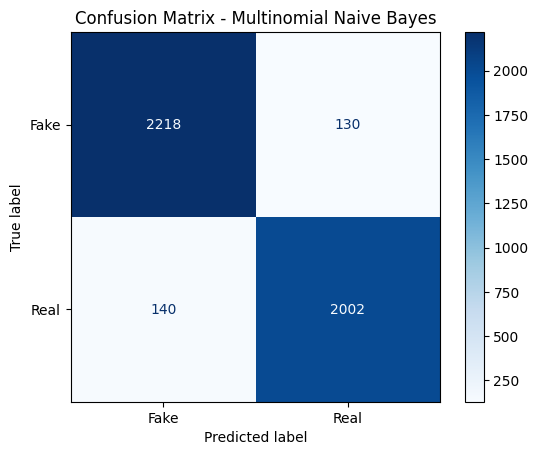

In [228]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Fake", "Real"]
)

disp.plot(cmap="Blues")

plt.title("Confusion Matrix - Multinomial Naive Bayes")

plt.show()

### 11.5.3 Precision

#### Definition

Precision measures how many of the samples predicted as positive are actually positive.

It answers the question:

> "When the model predicts the positive class, how often is it correct?"

Mathematically:

$$
Precision =
\frac{TP}{TP+FP}
$$

In [229]:
from sklearn.metrics import precision_score

precision = precision_score(y_test, y_pred)

print(f"Precision: {precision:.4f}")

Precision: 0.9390



#### Summary

- Precision measures prediction reliability.
- It answers: "How many predicted positives are actually positive?"
- Formula:

$$
Precision=\frac{TP}{TP+FP}
$$

- Higher Precision means fewer false positives.

### 11.5.4 Recall

#### Definition

Recall measures how many of the actual positive samples were correctly identified by the model.

It answers the question:

> "Of all the actual positive samples, how many did the model correctly detect?"

Mathematically:

$$
Recall =
\frac{TP}{TP+FN}
$$

In [230]:
from sklearn.metrics import recall_score

recall = recall_score(y_test, y_pred)

print(f"Recall: {recall:.4f}")

Recall: 0.9346


#### Precision vs Recall

| Metric | Focus | Formula |
|---------|--------|----------|
| Precision | Reliability of positive predictions | TP / (TP + FP) |
| Recall | Ability to detect all positive samples | TP / (TP + FN) |

#### Summary

- Recall measures detection capability.
- It answers: "How many actual positives were found?"
- Formula:

\[
Recall=\frac{TP}{TP+FN}
\]

- Higher Recall means fewer false negatives.

### 11.5.5 F1-Score

#### Definition

F1-Score is the harmonic mean of Precision and Recall.

It provides a single metric that balances both prediction reliability (Precision) and detection capability (Recall).

Mathematically:

\[
F1=
2\times
\frac{Precision\times Recall}
{Precision+Recall}
\]

The F1-score ranges between:

- 0 → Worst possible performance
- 1 → Perfect classification

#### Why Harmonic Mean?

F1-score uses the harmonic mean instead of the arithmetic mean.

The harmonic mean penalizes large differences between Precision and Recall.

Therefore, a high F1-score is only achieved when both Precision and Recall are high.

In [231]:
from sklearn.metrics import f1_score

f1 = f1_score(y_test, y_pred)

print(f"F1 Score: {f1:.4f}")

F1 Score: 0.9368


#### Precision vs Recall vs F1

| Metric | Main Question |
|----------|---------------|
| Precision | When I predict positive, how often am I correct? |
| Recall | How many actual positives did I detect? |
| F1-score | How well do I balance Precision and Recall? |

#### Summary

- F1-score balances Precision and Recall.
- It is the harmonic mean of both metrics.
- High F1-score requires both Precision and Recall to be high.
- F1-score is one of the most widely reported metrics in NLP research.

### 11.5.6 Classification Report

#### What Is a Classification Report?

A classification report summarizes the performance of a classification model using multiple evaluation metrics.

Instead of examining each metric individually, it provides:

- Precision
- Recall
- F1-score
- Support

for every class.

In [232]:
from sklearn.metrics import classification_report

print(classification_report(
    y_test,
    y_pred,
    target_names=["Fake", "Real"]
))

              precision    recall  f1-score   support

        Fake       0.94      0.94      0.94      2348
        Real       0.94      0.93      0.94      2142

    accuracy                           0.94      4490
   macro avg       0.94      0.94      0.94      4490
weighted avg       0.94      0.94      0.94      4490



#### Report Columns

| Column | Meaning |
|----------|----------|
| Precision | Reliability of positive predictions |
| Recall | Detection rate of actual positives |
| F1-score | Balance between Precision and Recall |
| Support | Number of true samples belonging to the class |

The Multinomial Naive Bayes classifier achieved a balanced performance across both classes, with approximately 94% Precision, Recall, and F1-score. The close agreement between Macro and Weighted averages indicates that the dataset is relatively balanced, and the classifier generalizes consistently across both classes.

#### Support

Support is simply the number of true samples for each class in the evaluation dataset.

It is not a performance metric.

It only tells how many examples belong to each class.

#### Macro Average

Macro averaging computes the metric independently for each class and then calculates the simple arithmetic mean.

Each class contributes equally regardless of its size.

#### Weighted Average

Weighted averaging computes the metric for each class and weights each value according to the class support.

Larger classes contribute more to the final score.

#### Which Average Should We Use?

- Balanced datasets → Macro Average is often appropriate.
- Imbalanced datasets → Weighted Average is usually more informative.

#### Summary

- The classification report combines multiple evaluation metrics.
- Support indicates the number of true samples per class.
- Macro averages treat classes equally.
- Weighted averages account for class frequency.
- The report is a standard tool for evaluating classification models.

### 11.5.6 ROC Curve & ROC-AUC

#### Why Do We Need ROC?

So far, we have evaluated our classifier using predicted class labels:

- Fake
- Real

However, classification models actually produce probabilities before making a final prediction.

ROC analysis evaluates how the model behaves across different decision thresholds rather than at a single fixed threshold.

#### ROC Curve

Instead of evaluating the model at one threshold (0.5), the ROC curve evaluates it at many thresholds.

Examples:

- 0.00
- 0.10
- 0.20
- ...
- 0.90
- 1.00

The resulting curve summarizes model performance across all thresholds.

#### ROC Axes

The ROC curve plots:

- True Positive Rate (TPR) = Recall = Sensitivity 

- False Positive Rate (FPR) = 1 - Specificity = False Alarm Rate

These quantities are computed for every decision threshold.

In [233]:
y_proba = model.predict_proba(X_test_selected)[:, 1]

In [234]:
from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(
    y_test,
    y_proba
)

print("Number of Thresholds:", len(thresholds))
print("First 10 Thresholds:", thresholds[:10])

Number of Thresholds: 523
First 10 Thresholds: [       inf 0.99999107 0.9998833  0.99988095 0.99838337 0.99837796
 0.99818514 0.99816472 0.99599334 0.99595855]


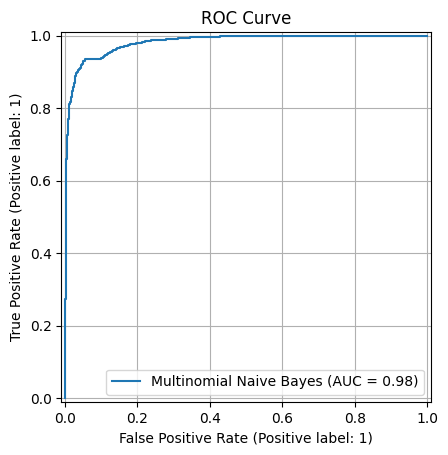

In [235]:
from sklearn.metrics import RocCurveDisplay
import matplotlib.pyplot as plt

RocCurveDisplay.from_predictions(
    y_test,
    y_proba,
    name="Multinomial Naive Bayes"
)

plt.title("ROC Curve")

plt.grid(True)

plt.show()

In [236]:
from sklearn.metrics import roc_auc_score

auc = roc_auc_score(y_test, y_proba)

print(f"ROC-AUC: {auc:.4f}")

ROC-AUC: 0.9815


The Multinomial Naive Bayes classifier achieved an ROC-AUC score of 0.9815, indicating excellent discriminative ability between fake and real news articles. The ROC curve approaches the top-left corner, demonstrating a high true positive rate while maintaining a very low false positive rate across a wide range of decision thresholds.

### 11.5.7 Precision–Recall Curve

#### Why Do We Need a Precision–Recall Curve?

The ROC curve evaluates the trade-off between:

- True Positive Rate
- False Positive Rate

However, for highly imbalanced datasets, ROC curves may present an overly optimistic view of model performance.

In such cases, the Precision–Recall (PR) Curve provides a more informative evaluation.

The PR Curve illustrates the relationship between:

- Precision
- Recall

across different decision thresholds.

#### ROC Curve vs Precision–Recall Curve

| ROC Curve | Precision–Recall Curve |
|------------|------------------------|
| TPR vs FPR | Precision vs Recall |
| Works well for balanced datasets | Preferred for imbalanced datasets |
| Uses both positive and negative classes | Focuses on the positive class |

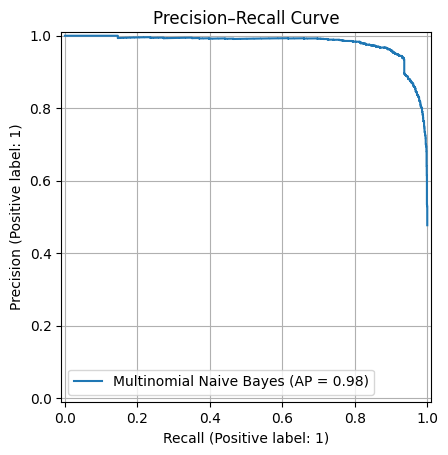

In [237]:
from sklearn.metrics import PrecisionRecallDisplay
import matplotlib.pyplot as plt

PrecisionRecallDisplay.from_predictions(
    y_test,
    y_proba,
    name="Multinomial Naive Bayes"
)

plt.title("Precision–Recall Curve")
plt.grid(True)
plt.show()

In [238]:
from sklearn.metrics import average_precision_score

ap = average_precision_score(
    y_test,
    y_proba
)

print(f"Average Precision: {ap:.4f}")

Average Precision: 0.9796


#### Summary

- PR Curve plots Precision against Recall.
- It is particularly useful for imbalanced datasets.
- Average Precision summarizes the entire curve into a single score.
- PR analysis complements ROC analysis by focusing on positive class performance.

### 11.5.8 Threshold Tuning

#### Why Change the Threshold?

Most binary classifiers use a default decision threshold of **0.5**.

However, this value is not always optimal.

Changing the threshold allows us to control the trade-off between Precision and Recall according to business requirements.

In [239]:
import pandas as pd
from sklearn.metrics import precision_score, recall_score, f1_score

thresholds = [0.30, 0.50, 0.70, 0.90]

results = []

for t in thresholds:
    pred = (y_proba >= t).astype(int)

    results.append({
        "Threshold": t,
        "Precision": precision_score(y_test, pred),
        "Recall": recall_score(y_test, pred),
        "F1-Score": f1_score(y_test, pred)
    })

threshold_results = pd.DataFrame(results)

threshold_results

,Threshold,Precision,Recall,F1-Score
0,0.3,0.855432,0.966853,0.907736
1,0.5,0.939024,0.934641,0.936827
2,0.7,0.967526,0.876284,0.919647
3,0.9,0.990962,0.716620,0.831753


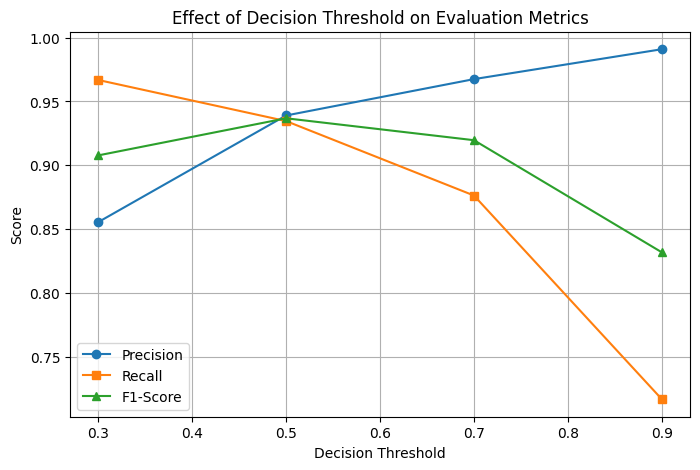

In [240]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(
    threshold_results["Threshold"],
    threshold_results["Precision"],
    marker="o",
    label="Precision"
)

plt.plot(
    threshold_results["Threshold"],
    threshold_results["Recall"],
    marker="s",
    label="Recall"
)

plt.plot(
    threshold_results["Threshold"],
    threshold_results["F1-Score"],
    marker="^",
    label="F1-Score"
)

plt.xlabel("Decision Threshold")
plt.ylabel("Score")
plt.title("Effect of Decision Threshold on Evaluation Metrics")

plt.grid(True)
plt.legend()

plt.show()

#### Interpretation

Threshold tuning demonstrates that classifier performance is highly dependent on the chosen decision threshold.

As the threshold increases:

- Precision generally increases because the classifier becomes more conservative when predicting the positive class.
- Recall decreases because more actual positive samples are rejected.
- F1-score reaches its maximum when Precision and Recall are well balanced.

In our experiment:

- Threshold = **0.30** achieved the highest Recall but lower Precision.
- Threshold = **0.50** produced the best overall balance with the highest F1-score.
- Threshold = **0.70** increased Precision at the cost of Recall.
- Threshold = **0.90** achieved nearly perfect Precision but significantly reduced Recall.

This experiment highlights that the default threshold is not universally optimal and should be selected according to the specific objectives of the application.

---

#### Business Thinking

Decision threshold selection is a business decision as much as it is a technical one.

Different applications prioritize different types of prediction errors:

- News verification platforms may prefer a lower threshold to maximize Recall and reduce the chance of missing fake news.
- Fact-checking organizations may choose a balanced threshold that provides strong overall performance.
- High-confidence publishing systems may require a higher threshold to maximize Precision before labeling an article as trustworthy.

Rather than accepting the default threshold of 0.5, production systems should determine the operating threshold based on business objectives, risk tolerance, and the relative cost of false positives and false negatives.

---

#### Summary

- Binary classifiers convert predicted probabilities into class labels using a decision threshold.
- The default threshold (0.5) is not always the optimal operating point.
- Lower thresholds generally increase Recall while reducing Precision.
- Higher thresholds generally increase Precision while reducing Recall.
- F1-score helps identify thresholds that provide a balanced trade-off between Precision and Recall.
- Threshold tuning is an essential step when deploying machine learning models in real-world applications.

## 11.6 Logistic Regression

### Why Logistic Regression?

Logistic Regression is one of the most widely used algorithms for binary classification.

Despite its name, Logistic Regression is a classification algorithm rather than a regression algorithm.

It estimates the probability that a sample belongs to a particular class and converts that probability into a class label using a decision threshold.

Logistic Regression is considered one of the strongest baseline models for text classification and Natural Language Processing (NLP).

It is frequently used in applications such as:

- Fake News Detection
- Spam Filtering
- Sentiment Analysis
- Email Classification
- Medical Diagnosis

### Naive Bayes vs Logistic Regression

| Multinomial Naive Bayes | Logistic Regression |
|--------------------------|--------------------|
| Generative Model | Discriminative Model |
| Estimates feature probabilities | Learns a decision boundary |
| Assumes feature independence | No independence assumption |
| Extremely fast | Fast |
| Strong baseline for text | Strong baseline for text |

### Generative vs Discriminative Learning

Generative models learn the probability distribution of each class and then apply Bayes' theorem for classification.

Discriminative models learn the decision boundary that directly separates different classes.

Logistic Regression belongs to the discriminative family of classifiers.

### 11.6.1 The Sigmoid Function

#### Why Do We Need the Sigmoid Function?

Machine learning models often begin by computing a linear combination of the input features:

$$ z = w_1x_1 + w_2x_2 + \cdots + w_nx_n + b $$

The resulting value, called the **linear score**, can range from negative infinity to positive infinity.

However, probabilities must always lie between **0** and **1**.

Therefore, Logistic Regression applies the **Sigmoid Function** to transform the linear score into a valid probability.

#### Properties

- Output range: (0, 1)
- Smooth and differentiable
- Monotonically increasing
- Symmetric around the point (0, 0.5)
- Suitable for gradient-based optimization

### 11.6.2 Implementing Logistic Regression

#### Building the Logistic Regression Classifier

To ensure a fair comparison with Multinomial Naive Bayes, the Logistic Regression model will use exactly the same preprocessing pipeline:

- Train/Test Split
- TF-IDF Feature Extraction
- Chi-Square Feature Selection

The only component that changes is the classifier itself.

In [241]:
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(
    random_state=42,
    max_iter=1000
)

lr_model.fit(X_train_selected, y_train)

print("class:", lr_model.classes_)
print ("Number of Features:", lr_model.n_features_in_)

class: [0 1]
Number of Features: 10000


### 11.6.3 Understanding Model Coefficients

#### What Does Logistic Regression Learn?

Unlike Multinomial Naive Bayes, which estimates conditional probabilities for each feature, Logistic Regression learns a numerical weight (coefficient) for every feature.

Each coefficient represents the contribution of a feature toward the prediction of the positive or negative class.

After training, the model has learned:

- One coefficient for every selected feature.
- One intercept (bias) term.

Together, these values define the decision boundary used for classification.

#### Positive and Negative Coefficients

Each learned coefficient has a direction:

- Positive coefficients increase the probability of the positive class.
- Negative coefficients increase the probability of the negative class.

The larger the absolute value of the coefficient, the stronger its influence on the prediction.

In [242]:
feature_names = tfidf_vectorizer.get_feature_names_out()[selector.get_support()]

import pandas as pd

coef_df = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": lr_model.coef_[0]
})

coef_df.head()

,Feature,Coefficient
0,00,-0.420090
1,000,-0.307920
2,00pm,-0.124745
3,0100,0.018552
4,0700,0.183489


In [243]:
coef_df.sort_values(
    by="Coefficient",
    ascending=False
).head(20)

,Feature,Coefficient
7590,reuters,24.945190
7801,said,20.157870
6359,on,10.548831
9649,washington,6.718955
4463,in,5.861060
7505,republican,5.019800
9687,wednesday,4.947134
9019,thursday,4.421105
5789,minister,4.282190
9215,tuesday,4.193200


In [244]:
coef_df.sort_values(
    by="Coefficient",
    ascending=True
).head(20)

,Feature,Coefficient
9502,via,-9.994928
9423,us,-6.994589
8988,this,-6.606027
7297,read,-5.326674
5964,mr,-4.947753
8952,that,-4.849013
4870,just,-4.827274
3815,gop,-4.740161
4409,image,-4.633617
3335,featured,-4.465249


#### Naive Bayes vs Logistic Regression

| Multinomial Naive Bayes | Logistic Regression |
|--------------------------|--------------------|
| Learns conditional probabilities | Learns feature weights |
| Uses probability estimates | Uses linear coefficients |
| Feature importance is probability-based | Feature importance is weight-based |

#### Summary

- Logistic Regression learns one coefficient for each feature.
- Positive coefficients increase the probability of the positive class.
- Negative coefficients favor the negative class.
- The magnitude of a coefficient reflects its influence on the prediction.
- Model coefficients provide valuable insight into how the classifier makes decisions.

### 11.6.4 Making Predictions with Logistic Regression

#### Generating Predictions

Once the Logistic Regression model has been trained, it can be used to make predictions on unseen data.

The model supports three common prediction methods:

- `predict()`
- `predict_proba()`
- `decision_function()`

Each method provides different information about the model's prediction.

In [245]:
# Predict the Class

sample_idx = 0

lr_prediction = lr_model.predict(
    X_test_selected[sample_idx]
)

lr_prediction

array([0])

In [246]:
# Predict Class Probabilities

lr_probabilities = lr_model.predict_proba(
    X_test_selected[sample_idx]
)

lr_probabilities

array([[0.99718776, 0.00281224]])

In [247]:
# Decision Function Scores (Linear Score)

lr_score = lr_model.decision_function(
    X_test_selected[sample_idx]
)

lr_score

array([-5.8709566])

#### Prediction Workflow

The prediction process follows these steps:

1. Compute the linear score:

   \[
   z = wx + b
   \]

2. Apply the Sigmoid Function to obtain a probability.

3. Compare the probability with the decision threshold.

4. Produce the final class label.

In [248]:
print("Actual :", y_test.iloc[sample_idx])

print("Prediction :", lr_prediction[0])

print("Probabilities :", lr_probabilities)

print("Decision Score :", lr_score)

Actual : 0
Prediction : 0
Probabilities : [[0.99718776 0.00281224]]
Decision Score : [-5.8709566]


#### Summary

- `predict()` returns the final class label.
- `predict_proba()` returns the probability of each class.
- `decision_function()` returns the raw linear score before applying the Sigmoid Function.
- Logistic Regression converts the linear score into a probability and then applies a decision threshold to generate the final prediction.
- Probability outputs provide valuable confidence information for real-world decision-making.

### 11.6.5 Evaluating Logistic Regression

#### Evaluating Model Performance

After training the Logistic Regression classifier, we evaluate its performance on the test dataset using the same evaluation metrics applied to Multinomial Naive Bayes.

Using identical evaluation metrics ensures a fair comparison between the two models.

In [249]:
y_pred_lr = lr_model.predict(X_test_selected)

y_prob_lr = lr_model.predict_proba(X_test_selected)[:, 1]

In [250]:
from sklearn.metrics import accuracy_score

lr_accuracy = accuracy_score(
    y_test,
    y_pred_lr
)

print(f"Accuracy: {lr_accuracy:.4f}")

Accuracy: 0.9840


In [251]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm_lr = confusion_matrix(
    y_test,
    y_pred_lr
)

cm_lr

array([[2306,   42],
       [  30, 2112]])

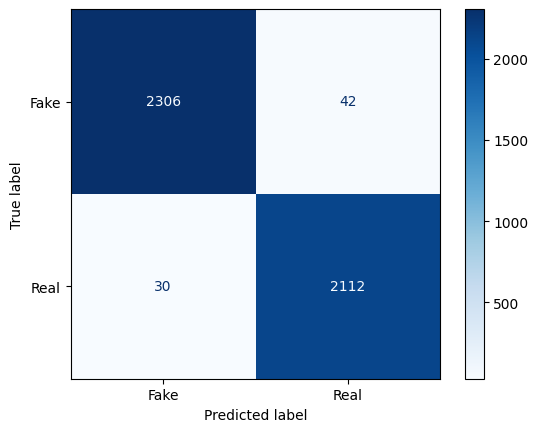

In [252]:
ConfusionMatrixDisplay(
    confusion_matrix=cm_lr,
    display_labels=["Fake", "Real"]
).plot(cmap="Blues")

In [256]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        y_pred_lr,
        target_names=["Fake", "Real"]
    )
)

              precision    recall  f1-score   support

        Fake       0.99      0.98      0.98      2348
        Real       0.98      0.99      0.98      2142

    accuracy                           0.98      4490
   macro avg       0.98      0.98      0.98      4490
weighted avg       0.98      0.98      0.98      4490



In [259]:
from sklearn.metrics import roc_auc_score

y_proba_lr = lr_model.predict_proba(X_test_selected)[:, 1]

lr_auc = roc_auc_score(
    y_test,
    y_proba_lr
)

print(f"ROC-AUC: {lr_auc:.4f}")

ROC-AUC: 0.9983


In [262]:
from sklearn.metrics import precision_score, recall_score, f1_score

lr_precision = precision_score(
    y_test,
    y_pred_lr
)

lr_recall = recall_score(
    y_test,
    y_pred_lr
)

lr_f1 = f1_score(
    y_test,
    y_pred_lr
)

print(f"Precision: {lr_precision:.4f}")
print(f"Recall: {lr_recall:.4f}")
print(f"F1-Score: {lr_f1:.4f}")

Precision: 0.9805
Recall: 0.9860
F1-Score: 0.9832


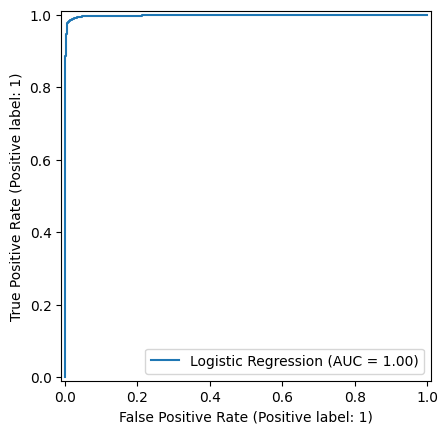

In [ ]:
from sklearn.metrics import RocCurveDisplay

RocCurveDisplay.from_predictions(
    y_test,
    y_proba_lr,
    name="Logistic Regression"
)

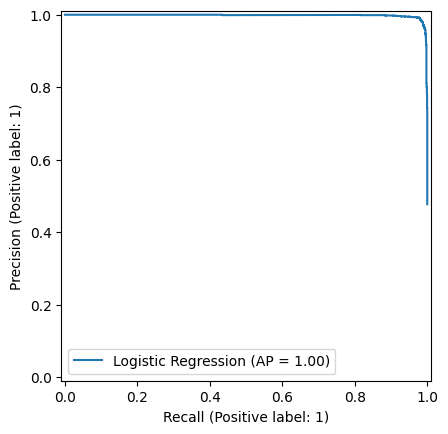

In [ ]:
from sklearn.metrics import PrecisionRecallDisplay

PrecisionRecallDisplay.from_predictions(
    y_test,
    y_proba_lr,
    name="Logistic Regression"
)

In [ ]:
from sklearn.metrics import average_precision_score

ap_lr = average_precision_score(
    y_test,
    y_proba_lr
)

print(f"Average Precision: {ap_lr:.4f}")

Average Precision: 0.9982


In [ ]:
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score
)

evaluation = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1-Score",
        "ROC-AUC",
        "Average Precision"
    ],
    "Value": [
        accuracy_score(y_test, y_pred_lr),
        precision_score(y_test, y_pred_lr),
        recall_score(y_test, y_pred_lr),
        f1_score(y_test, y_pred_lr),
        roc_auc_score(y_test, y_proba_lr),
        average_precision_score(y_test, y_proba_lr)
    ]
})

evaluation

,Metric,Value
0,Accuracy,0.983964
1,Precision,0.980501
2,Recall,0.985994
3,F1-Score,0.983240
4,ROC-AUC,0.998319
5,Average Precision,0.998166


### 11.6.6 Logistic Regression vs Multinomial Naive Bayes

#### Comparing Two Classical NLP Classifiers

After training and evaluating both classifiers using the same preprocessing pipeline and evaluation dataset, we can directly compare their behavior, assumptions, strengths, and weaknesses.

Although both algorithms are widely used for text classification, they learn from data in fundamentally different ways.

Selecting the most appropriate model requires evaluating not only predictive performance but also computational efficiency, interpretability, and business requirements.

#### Model Comparison

| Aspect | Multinomial Naive Bayes | Logistic Regression |
|---------|-------------------------|---------------------|
| Model Type | Generative | Discriminative |
| Learning Strategy | Estimates feature probabilities | Learns feature weights |
| Independence Assumption | Yes | No |
| Optimization | Closed-form estimation | Iterative optimization |
| Feature Representation | Count / TF-IDF | TF-IDF / Sparse vectors |
| Probability Output | Native probabilities | Sigmoid probabilities |
| Interpretability | High | High |
| Training Speed | Very Fast | Fast |
| Prediction Speed | Very Fast | Fast |
| Scalability | Excellent | Excellent |
| Performance on This Dataset | Good | Excellent |

#### Performance Comparison

| Metric | Multinomial Naive Bayes | Logistic Regression |
|---------|------------------------:|--------------------:|
| Accuracy | 0.9399 | 0.9840 |
| Precision | 0.9390 | 0.9805 |
| Recall | 0.9346 | 0.9860 |
| F1-Score | 0.9368 | 0.9832 |
| ROC-AUC | 0.9815 | 0.9983 |
| Average Precision | 0.9796 | 0.9982 |

#### Strengths and Weaknesses

##### Multinomial Naive Bayes

**Strengths**

- Extremely fast training.
- Very low computational cost.
- Excellent baseline model.
- Performs well on small datasets.

**Limitations**

- Assumes feature independence.
- Less flexible decision boundary.
- May underperform compared to discriminative models.

---

##### Logistic Regression

**Strengths**

- Learns optimized feature weights.
- Produces calibrated probabilities.
- Handles sparse TF-IDF features effectively.
- Typically achieves higher predictive performance.

**Limitations**

- Requires iterative optimization.
- Training is slower than Naive Bayes.
- Assumes a linear decision boundary.

#### Model Selection

Based on the evaluation results, Logistic Regression demonstrates superior performance across all major evaluation metrics.

The model achieves higher accuracy, stronger class separation, fewer classification errors, and better probability estimates.

Therefore, Logistic Regression is selected as the preferred model for this Fake News Detection project.

#### Real-World Considerations

Model selection should not rely solely on predictive performance.

In production environments, additional factors should be considered, including:

- Training time
- Inference latency
- Memory consumption
- Model interpretability
- Ease of deployment
- Business objectives
- Maintenance cost

#### Summary

- Both models were evaluated using an identical preprocessing pipeline and test dataset.
- Multinomial Naive Bayes served as a strong baseline classifier.
- Logistic Regression achieved higher Accuracy, Precision, Recall, F1-score, ROC-AUC, and Average Precision.
- Logistic Regression reduced the number of classification errors from 270 to 72.
- Based on both quantitative results and practical considerations, Logistic Regression is selected as the preferred model for this project.

## 11.7 Linear Support Vector Machine (Linear SVM)

### Why Study Support Vector Machines?

Support Vector Machines (SVMs) are among the most successful classical machine learning algorithms for text classification.

They are particularly effective when working with high-dimensional sparse feature spaces, making them an excellent choice for Natural Language Processing (NLP) tasks.

Linear SVM is widely used for applications such as:

- Fake News Detection
- Spam Filtering
- Sentiment Analysis
- Topic Classification
- Email Categorization

Even today, Linear SVM remains one of the strongest non-neural baselines for text classification.

### Logistic Regression vs Linear SVM

| Logistic Regression | Linear SVM |
|---------------------|------------|
| Predicts probabilities | Finds the maximum-margin boundary |
| Uses the Sigmoid Function | Does not use Sigmoid |
| Outputs calibrated probabilities | Outputs decision scores |
| Optimizes Log Loss | Optimizes Hinge Loss |
| Threshold-based prediction | Margin-based prediction |

### Advantages

- Excellent performance on high-dimensional datasets.
- Robust against overfitting.
- Effective with sparse TF-IDF features.
- Strong generalization ability.
- Frequently outperforms many classical classifiers in NLP.

### Summary

- Linear SVM is one of the strongest classical algorithms for text classification.
- It is specifically well suited for high-dimensional sparse TF-IDF features.
- Unlike Logistic Regression, it does not optimize probabilities but instead maximizes the margin between classes.
- The maximum-margin principle contributes to strong generalization performance.
- Linear SVM is widely used as a competitive baseline in NLP applications.

### 11.7.1 Support Vectors and the Maximum Margin

#### The Main Idea Behind Support Vector Machines

The primary objective of a Support Vector Machine is to find the optimal decision boundary that separates different classes.

Unlike many classification algorithms, SVM does not simply search for any separating boundary. Instead, it searches for the boundary that maximizes the distance between the two classes.

This distance is called the **margin**.

A larger margin generally leads to better generalization and improved performance on unseen data.

#### What Is the Margin?

The margin is the shortest distance between the decision boundary and the nearest training samples from each class.

The goal of Linear SVM is to maximize this margin.

A larger margin usually improves the model's ability to classify unseen data correctly.

#### What Are Support Vectors?

Support Vectors are the training samples that lie closest to the decision boundary.

These samples determine the position of the separating hyperplane.

If the support vectors change, the decision boundary also changes.

#### What Is a Hyperplane?

A hyperplane is the decision boundary learned by the classifier.

- In two dimensions, it is a line.
- In three dimensions, it is a plane.
- In higher-dimensional feature spaces, it is called a hyperplane.

#### Summary

- Linear SVM searches for the optimal separating hyperplane.
- The optimal hyperplane is the one with the maximum margin.
- Support Vectors are the closest training samples to the decision boundary.
- The position of the hyperplane depends entirely on the support vectors.
- Maximizing the margin improves robustness and generalization to unseen data.

### 11.7.2 Hinge Loss

#### Why Does SVM Need a Different Loss Function?

Every supervised learning algorithm needs an objective function that measures prediction error during training.

This objective function is called the **Loss Function**.

Different machine learning algorithms optimize different loss functions:

- Linear Regression → Mean Squared Error (MSE)
- Logistic Regression → Log Loss (Cross-Entropy Loss)
- Support Vector Machine → Hinge Loss

The choice of the loss function determines how the model learns from its mistakes.

#### What Is the Hinge Loss?

The Hinge Loss is a loss function used in Support Vector Machines (SVMs) for classification tasks.

It is defined as:

$$L(y, f(x)) = \max(0, 1 - yf(x))$$

where:

- $y$ is the true label of the sample (either +1 or -1).
- $f(x)$ is the predicted score for the sample.

The Hinge Loss is a convex function that penalizes incorrect predictions more heavily than correct predictions.

It is called "hinge" because it is similar to the hinge of a door, which resists opening too far.

The Hinge Loss is used in SVMs because it encourages the model to find a decision boundary that separates the classes with a large margin.

#### Hinge Loss vs Log Loss

| Log Loss | Hinge Loss |
|-----------|------------|
| Optimized by Logistic Regression | Optimized by Linear SVM |
| Probability-based | Margin-based |
| Produces calibrated probabilities | Produces decision scores |
| Penalizes incorrect probabilities | Penalizes margin violations |

#### Why Does Hinge Loss Improve Generalization?

By penalizing both incorrect predictions and correctly classified samples that lie close to the decision boundary, Hinge Loss encourages larger margins.

This often leads to models that are more robust and generalize better to unseen data.

#### Summary

- Every supervised learning algorithm optimizes a specific loss function.
- Linear SVM uses Hinge Loss instead of Log Loss.
- Hinge Loss penalizes both incorrect predictions and correct predictions that are too close to the decision boundary.
- This behavior encourages larger margins and stronger generalization.
- The maximum-margin principle is one of the primary reasons for the strong performance of Linear SVM on text classification tasks.

### 11.7.3 Training a Linear SVM

#### Building the Linear SVM Classifier

To perform a fair comparison with the previously trained models, Linear SVM will be trained using the exact same preprocessing pipeline:

- Train/Test Split
- TF-IDF Feature Extraction
- Chi-Square Feature Selection

Only the classification algorithm changes.

In [ ]:
from sklearn.svm import LinearSVC

svm_model = LinearSVC(
    random_state=42,
    max_iter=10000
)

svm_model.fit(X_train_selected, y_train)

svm_model

,"penalty penalty: {'l1', 'l2'}, default='l2'Specifies the norm used in the penalization. The 'l2'penalty is the standard used in SVC. The 'l1' leads to ``coef_``vectors that are sparse.",'l2'
,"loss loss: {'hinge', 'squared_hinge'}, default='squared_hinge'Specifies the loss function. 'hinge' is the standard SVM loss(used e.g. by the SVC class) while 'squared_hinge' is thesquare of the hinge loss. The combination of ``penalty='l1'``and ``loss='hinge'`` is not supported.",'squared_hinge'
,"dual dual: ""auto"" or bool, default=""auto""Select the algorithm to either solve the dual or primaloptimization problem. Prefer dual=False when n_samples > n_features.`dual=""auto""` will choose the value of the parameter automatically,based on the values of `n_samples`, `n_features`, `loss`, `multi_class`and `penalty`. If `n_samples` < `n_features` and optimizer supportschosen `loss`, `multi_class` and `penalty`, then dual will be set to True,otherwise it will be set to False... versionchanged:: 1.3 The `""auto""` option is added in version 1.3 and will be the default in version 1.5.",'auto'
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive.For an intuitive visualization of the effects of scalingthe regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"multi_class multi_class: {'ovr', 'crammer_singer'}, default='ovr'Determines the multi-class strategy if `y` contains more thantwo classes.``""ovr""`` trains n_classes one-vs-rest classifiers, while``""crammer_singer""`` optimizes a joint objective over all classes.While `crammer_singer` is interesting from a theoretical perspectiveas it is consistent, it is seldom used in practice as it rarely leadsto better accuracy and is more expensive to compute.If ``""crammer_singer""`` is chosen, the options loss, penalty and dualwill be ignored.",'ovr'
,"fit_intercept fit_intercept: bool, default=TrueWhether or not to fit an intercept. If set to True, the feature vectoris extended to include an intercept term: `[x_1, ..., x_n, 1]`, where1 corresponds to the intercept. If set to False, no intercept will beused in calculations (i.e. data is expected to be already centered).",True
,"intercept_scaling intercept_scaling: float, default=1.0When `fit_intercept` is True, the instance vector x becomes ``[x_1,..., x_n, intercept_scaling]``, i.e. a ""synthetic"" feature with aconstant value equal to `intercept_scaling` is appended to the instancevector. The intercept becomes intercept_scaling * synthetic featureweight. Note that liblinear internally penalizes the intercept,treating it like any other term in the feature vector. To reduce theimpact of the regularization on the intercept, the `intercept_scaling`parameter can be set to a value greater than 1; the higher the value of`intercept_scaling`, the lower the impact of regularization on it.Then, the weights become `[w_x_1, ..., w_x_n,w_intercept*intercept_scaling]`, where `w_x_1, ..., w_x_n` representthe feature weights and the intercept weight is scaled by`intercept_scaling`. This scaling allows the intercept term to have adifferent regularization behavior compared to the other features.",1
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to ``class_weight[i]*C`` forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: int, default=0Enable verbose output. Note that this setting takes advantage of aper-process runtime setting in liblinear that, if enabled, may not workproperly in a multithreaded context.",0
,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseudo rand

In [ ]:
print("Classes:", svm_model.classes_)
print("Number of Features:", svm_model.n_features_in_)
print("Intercept:", svm_model.intercept_)

Classes: [0 1]
Number of Features: 10000
Intercept: [-0.91584898]


#### Training Comparison

| Model | Learning Objective |
|--------|--------------------|
| Multinomial Naive Bayes | Estimate feature probabilities |
| Logistic Regression | Learn optimized feature weights |
| Linear SVM | Learn the maximum-margin hyperplane |

#### Summary

- Linear SVM was trained using the same preprocessing pipeline as the previous classifiers.
- `LinearSVC` is optimized for high-dimensional sparse text classification.
- During training, the model learns the maximum-margin hyperplane.
- Using an identical experimental setup ensures a fair and scientifically valid comparison between classifiers.

### 11.7.4 Understanding Linear SVM Coefficients

#### How Does Linear SVM Make Decisions?

Although Linear SVM does not estimate probabilities, it still learns a weight for every feature.

These learned weights determine how strongly each feature contributes to the final decision.

Features with large positive weights push the prediction toward one class, while features with large negative weights push it toward the other class.

In [ ]:
print("Coefficient Shape:", svm_model.coef_.shape)
print("Intercept Shape:", svm_model.intercept_.shape)

Coefficient Shape: (1, 10000)
Intercept Shape: (1,)


In [ ]:
print(svm_model.classes_)
print(y_train.value_counts())

[0 1]
label
0    18785
1    17133
Name: count, dtype: int64


#### Interpreting the Learned Weights

Assuming that:

- Class 0 → Fake News
- Class 1 → True News

Positive coefficients correspond to words that increase the likelihood of predicting **True News**, whereas negative coefficients correspond to words that push the prediction toward **Fake News**.

The prominent positive weight assigned to **Reuters** is expected because many authentic articles in the dataset originate from Reuters, highlighting a potential source-related dataset bias.

In [ ]:
feature_names = tfidf_vectorizer.get_feature_names_out()[
    selector.get_support()
]

svm_coef_df = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": svm_model.coef_[0]
})

top_positive = svm_coef_df.sort_values(
    by="Coefficient",
    ascending=False
).head(20)

top_positive

,Feature,Coefficient
7590,reuters,21.040129
7801,said,7.036471
6359,on,4.116729
9649,washington,2.939532
6233,nov,2.788472
7505,republican,2.333653
7868,saying,2.259282
1925,comment,2.186184
5424,ly,2.001700
9687,wednesday,1.979695


In [ ]:
top_negative = svm_coef_df.sort_values(
    by="Coefficient",
    ascending=True
).head(20)

top_negative

,Feature,Coefficient
9502,via,-8.981047
7297,read,-4.789941
3815,gop,-3.262442
9423,us,-3.093894
3335,featured,-3.074828
4409,image,-2.861947
5964,mr,-2.752748
7478,rep,-2.688931
8011,sen,-2.683778
8988,this,-2.553936


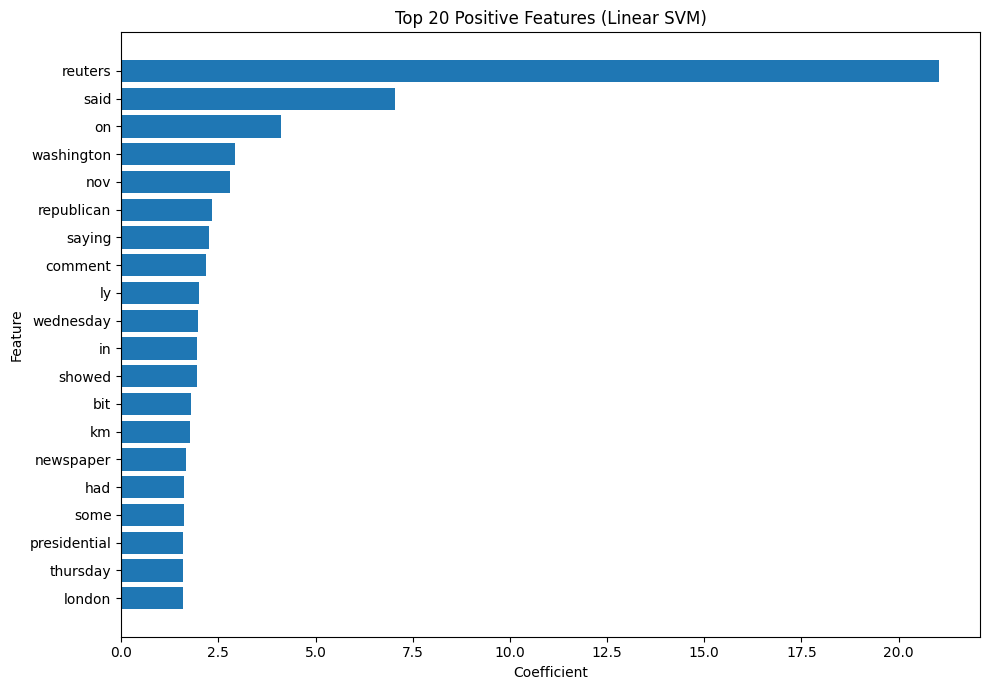

In [ ]:
import matplotlib.pyplot as plt

top_positive = svm_coef_df.nlargest(20, "Coefficient")

plt.figure(figsize=(10, 7))

plt.barh(
    top_positive["Feature"],
    top_positive["Coefficient"]
)

plt.title("Top 20 Positive Features (Linear SVM)")
plt.xlabel("Coefficient")
plt.ylabel("Feature")

plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

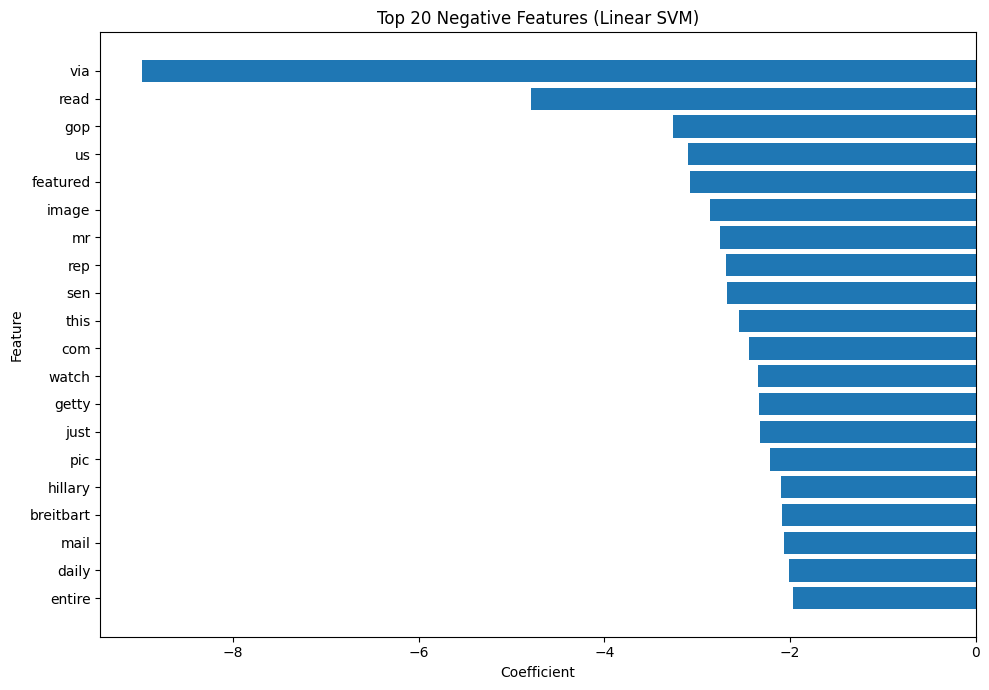

In [ ]:
top_negative = svm_coef_df.nsmallest(20, "Coefficient")

plt.figure(figsize=(10, 7))

plt.barh(
    top_negative["Feature"],
    top_negative["Coefficient"]
)

plt.title("Top 20 Negative Features (Linear SVM)")
plt.xlabel("Coefficient")
plt.ylabel("Feature")

plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

#### Interpreting Feature Weights

The magnitude of a coefficient reflects the importance of the corresponding feature.

- Large positive coefficient → Strong evidence toward one class.
- Large negative coefficient → Strong evidence toward the opposite class.
- Coefficient close to zero → Little influence on the prediction.

Unlike Logistic Regression, these coefficients are optimized to maximize the classification margin rather than estimate class probabilities.

#### Comparing Feature Weights

Both Logistic Regression and Linear SVM assign a weight to each feature.

However, the interpretation differs:

- Logistic Regression learns weights that optimize probability estimation.
- Linear SVM learns weights that maximize the separation margin.

Although the optimization objectives differ, the most influential features are often similar in text classification tasks.

#### Summary

- Linear SVM learns one coefficient for each selected feature.
- Positive and negative coefficients indicate the direction of influence on the decision boundary.
- Feature importance can be analyzed similarly to Logistic Regression.
- The learned weights maximize the classification margin rather than estimate probabilities.
- Inspecting coefficients improves interpretability and supports explainable machine learning.

### 11.7.5 Making Predictions with Linear SVM

#### Predicting New Samples

After training, the Linear SVM classifier can predict the class of unseen news articles.

Unlike Logistic Regression, Linear SVM does not estimate class probabilities.

Instead, it computes a **decision score**, which measures the signed distance of a sample from the learned decision boundary.

The sign of this score determines the predicted class.

In [ ]:
sample_idx = 0

svm_prediction = svm_model.predict(
    X_test_selected[sample_idx]
)

print("Predicted Class:", svm_prediction[0])
print("Actual Class:", y_test.iloc[sample_idx])

Predicted Class: 0
Actual Class: 0


In [ ]:
decision_score = svm_model.decision_function(
    X_test_selected[sample_idx]
)

print("Decision Score:", decision_score[0])

Decision Score: -2.4008123324045663


#### Example Interpretation

For this example:

- Predicted Class = 0
- Actual Class = 0
- Decision Score = -2.40

The negative score indicates that the sample lies on the side of the hyperplane associated with Class 0.

Since the absolute value of the score is relatively large, the classifier makes this prediction with a reasonable margin from the decision boundary.

In [ ]:
sample_indices = [0, 5, 10, 20, 50]

for idx in sample_indices:
    prediction = svm_model.predict(X_test_selected[idx])[0]
    score = svm_model.decision_function(X_test_selected[idx])[0]
    actual = y_test.iloc[idx]

    print(f"Sample {idx}")
    print(f"Actual Class    : {actual}")
    print(f"Predicted Class : {prediction}")
    print(f"Decision Score  : {score:.4f}")
    print("-" * 40)

Sample 0
Actual Class    : 0
Predicted Class : 0
Decision Score  : -2.4008
----------------------------------------
Sample 5
Actual Class    : 0
Predicted Class : 0
Decision Score  : -1.0745
----------------------------------------
Sample 10
Actual Class    : 0
Predicted Class : 0
Decision Score  : -0.9158
----------------------------------------
Sample 20
Actual Class    : 1
Predicted Class : 1
Decision Score  : 0.5841
----------------------------------------
Sample 50
Actual Class    : 1
Predicted Class : 1
Decision Score  : 1.2489
----------------------------------------


#### Decision Score Examples

The following examples illustrate how the magnitude and sign of the decision score influence the classifier's predictions.

| Sample | Actual | Predicted | Decision Score | Interpretation |
|--------:|:------:|:---------:|---------------:|----------------|
| 0 | 0 | 0 | -2.4008 | Correct prediction with a comfortable margin toward Class 0. |
| 5 | 0 | 0 | -1.0745 | Correct prediction with a moderate margin. |
| 10 | 0 | 0 | -0.9158 | Correct prediction, but relatively close to the decision boundary. |
| 20 | 1 | 1 | 0.5841 | Correct prediction with a small positive margin. |
| 50 | 1 | 1 | 1.2489 | Correct prediction with a stronger positive margin. |

#### Prediction Comparison

| Logistic Regression | Linear SVM |
|---------------------|------------|
| predict() | predict() |
| predict_proba() | decision_function() |
| Probability Output | Decision Score |
| Optimizes Log Loss | Optimizes Hinge Loss |

#### Summary

- Linear SVM predicts classes using `predict()`.
- Confidence is represented by the decision score returned by `decision_function()`.
- Positive and negative scores indicate opposite sides of the separating hyperplane.
- Larger absolute scores indicate stronger confidence in the prediction.
- Probability estimates require an additional calibration step because Linear SVM is not inherently probabilistic.

### 11.7.6 Evaluating Linear SVM

#### Evaluating the Linear SVM Classifier

After training the classifier, the next step is to evaluate its predictive performance on unseen data.

To ensure a fair comparison with the previously trained models, the same evaluation metrics are used:

- Accuracy
- Confusion Matrix
- Classification Report
- ROC Curve
- ROC-AUC
- Precision-Recall Curve
- Average Precision

In [ ]:
y_pred_svm = svm_model.predict(X_test_selected)

y_score_svm = svm_model.decision_function(X_test_selected)

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, average_precision_score

svm_accuracy = accuracy_score(y_test, y_pred_svm)
svm_precision = precision_score(y_test, y_pred_svm)
svm_recall = recall_score(y_test, y_pred_svm)
svm_f1 = f1_score(y_test, y_pred_svm)
svm_roc_auc = roc_auc_score(y_test, y_score_svm)
svm_average_precision = average_precision_score(y_test, y_score_svm)

print("Accuracy: {:.2f}%".format(svm_accuracy * 100))
print("Precision: {:.2f}%".format(svm_precision * 100))
print("Recall: {:.2f}%".format(svm_recall * 100))
print("F1 Score: {:.2f}%".format(svm_f1 * 100))
print("ROC-AUC Score: {:.2f}%".format(svm_roc_auc * 100))
print("Average Precision: {:.2f}%".format(svm_average_precision * 100))

Accuracy: 99.33%
Precision: 99.21%
Recall: 99.39%
F1 Score: 99.30%
ROC-AUC Score: 99.98%
Average Precision: 99.98%


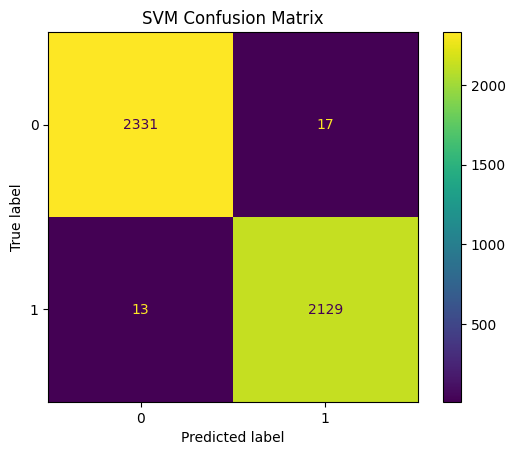

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_svm
    )
plt.title("SVM Confusion Matrix")
plt.show()

#### Confusion Matrix Interpretation

The confusion matrix demonstrates that the classifier made only **30 incorrect predictions** out of **4,490** test samples.

Specifically:

- True Negatives (TN): 2,331
- False Positives (FP): 17
- False Negatives (FN): 13
- True Positives (TP): 2,129

The low number of false positives and false negatives indicates that the classifier is highly reliable for distinguishing between fake and real news articles.

In [ ]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        y_pred_svm
    )
)

              precision    recall  f1-score   support

           0       0.99      0.99      0.99      2348
           1       0.99      0.99      0.99      2142

    accuracy                           0.99      4490
   macro avg       0.99      0.99      0.99      4490
weighted avg       0.99      0.99      0.99      4490



ROC-AUC: 0.9998


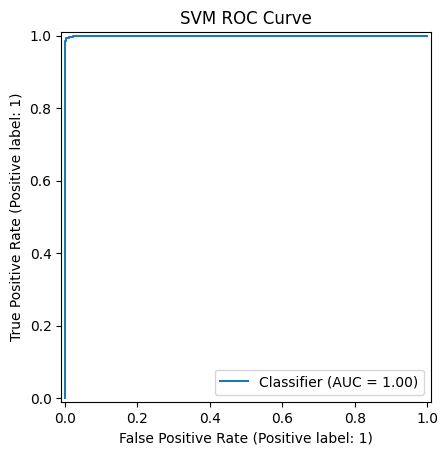

In [ ]:
from sklearn.metrics import (
    RocCurveDisplay,
    roc_auc_score
)

roc_auc_svm = roc_auc_score(
    y_test,
    y_score_svm
)

print(f"ROC-AUC: {roc_auc_svm:.4f}")

RocCurveDisplay.from_predictions(
    y_test,
    y_score_svm
)
plt.title("SVM ROC Curve")
plt.show()

Average Precision: 0.9998


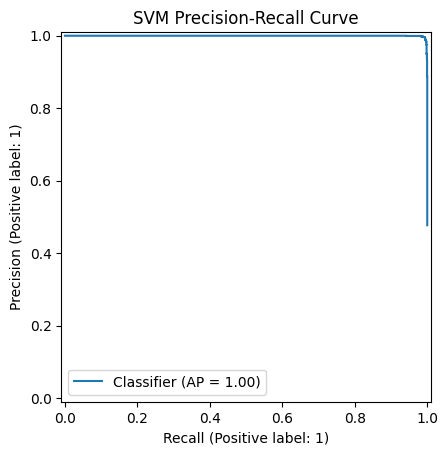

In [ ]:
from sklearn.metrics import (
    PrecisionRecallDisplay,
    average_precision_score
)

average_precision_svm = average_precision_score(
    y_test,
    y_score_svm
)

print(f"Average Precision: {average_precision_svm:.4f}")

PrecisionRecallDisplay.from_predictions(
    y_test,
    y_score_svm
)
plt.title("SVM Precision-Recall Curve")
plt.show()


In [ ]:
import pandas as pd
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score
)

svm_results = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1-score",
        "ROC-AUC",
        "Average Precision"
    ],
    "Value": [
        svm_accuracy,
        precision_score(y_test, y_pred_svm),
        recall_score(y_test, y_pred_svm),
        f1_score(y_test, y_pred_svm),
        roc_auc_svm,
        average_precision_svm
    ]
})

svm_results

,Metric,Value
0,Accuracy,0.993318
1,Precision,0.992078
2,Recall,0.993931
3,F1-score,0.993004
4,ROC-AUC,0.999773
5,Average Precision,0.999762


#### Evaluation Results

The Linear SVM classifier achieved outstanding performance on the test dataset.

| Metric | Value |
|--------|-------:|
| Accuracy | **0.9933** |
| Precision | **0.9921** |
| Recall | **0.9939** |
| F1-score | **0.9930** |
| ROC-AUC | **0.9998** |
| Average Precision | **0.9998** |

These results indicate excellent classification performance with very few prediction errors.

#### Summary

- Linear SVM achieved outstanding predictive performance.
- Only 30 misclassifications were observed on the test dataset.
- The classifier outperformed both Multinomial Naive Bayes and Logistic Regression across all evaluation metrics.
- The maximum-margin principle proved highly effective for sparse TF-IDF representations.
- Based on the experimental results, Linear SVM is currently the best-performing classifier in this project.

## 11.8 Final Benchmark and Model Selection

### Benchmarking the Evaluated Models

Throughout this project, three classical machine learning algorithms were trained and evaluated using the same preprocessing pipeline:

- Multinomial Naive Bayes
- Logistic Regression
- Linear Support Vector Machine

Each model was trained using identical TF-IDF features, Chi-Square feature selection, and the same train-test split.

This experimental setup enables a fair and objective comparison of their predictive performance.

### Overall Performance Comparison

| Metric | Multinomial Naive Bayes | Logistic Regression | Linear SVM |
|---------|------------------------:|--------------------:|-----------:|
| Accuracy | 0.9399 | 0.9840 | **0.9933** |
| Precision | 0.9390 | 0.9805 | **0.9921** |
| Recall | 0.9346 | 0.9860 | **0.9939** |
| F1-score | 0.9368 | 0.9832 | **0.9930** |
| ROC-AUC | 0.9815 | 0.9983 | **0.9998** |
| Average Precision | 0.9796 | 0.9982 | **0.9998** |
| Errors | 270 | 72 | **30** |

### Performance Improvement

Compared with the baseline Multinomial Naive Bayes model:

- Logistic Regression significantly improved every evaluation metric.
- Linear SVM further reduced classification errors and achieved the highest overall performance.

The results demonstrate that discriminative linear classifiers outperform the probabilistic baseline on this TF-IDF representation.

### Model Characteristics

| Property | Naive Bayes | Logistic Regression | Linear SVM |
|----------|-------------|--------------------|-----------|
| Training Speed | Excellent | Very Good | Very Good |
| Prediction Speed | Excellent | Excellent | Excellent |
| Interpretability | High | High | Moderate |
| Probability Estimates | Yes | Yes | No |
| Handles Sparse Features | Excellent | Excellent | Excellent |
| Generalization | Good | Excellent | Excellent |
| Production Suitability | Good | Excellent | Excellent |

### Final Model Selection

Based on the experimental evaluation, Linear SVM is selected as the final model for this project.

The model achieved the highest scores across all major evaluation metrics while producing the fewest classification errors.

Its maximum-margin learning strategy proved highly effective for high-dimensional sparse TF-IDF representations.

### Decision Matrix

| Criterion | Winner |
|-----------|--------|
| Accuracy | ✅ Linear SVM |
| Precision | ✅ Linear SVM |
| Recall | ✅ Linear SVM |
| F1-score | ✅ Linear SVM |
| ROC-AUC | ✅ Linear SVM |
| Average Precision | ✅ Linear SVM |
| Error Reduction | ✅ Linear SVM |
| Final Recommendation | ✅ Linear SVM |

### Summary

- Three classical machine learning models were evaluated using an identical preprocessing pipeline.
- Logistic Regression substantially improved upon the Naive Bayes baseline.
- Linear SVM achieved the highest predictive performance across all evaluation metrics.
- The benchmark supports selecting Linear SVM as the final classifier for this project.
- The experimental comparison demonstrates the importance of systematic model evaluation before deployment.

### Final Recommendation

Linear SVM is the recommended model for this project due to its superior performance across all major evaluation metrics.

Its maximum-margin learning strategy proved highly effective for high-dimensional sparse TF-IDF representations.

# 12 — Hyperparameter Optimization

### What Are Hyperparameters?

Hyperparameters are configuration values that control the learning process of a machine learning algorithm.

They are specified before training and remain fixed while the model learns from the data.

Examples include:

- Regularization strength (C)
- Number of trees in a Random Forest
- Learning rate
- Maximum tree depth
- Number of nearest neighbors (K)

## 12.1 Why Hyperparameter Optimization?

### Improving Model Performance

Machine learning models contain configurable settings that control how the learning algorithm behaves during training.

These settings are known as **hyperparameters**.

Unlike model parameters, hyperparameters are not learned automatically from the data. Instead, they must be chosen before training begins.

Selecting appropriate hyperparameter values can significantly improve model performance, reduce overfitting, and enhance generalization.

### Hyperparameters vs Model Parameters

| Hyperparameters | Model Parameters |
|-----------------|------------------|
| Set before training | Learned during training |
| Controlled by the practitioner | Estimated by the algorithm |
| Influence the learning process | Define the learned model |
| Examples: C, max_depth, learning_rate | Examples: weights, coefficients, intercept |

### Search Space

Hyperparameter optimization explores different combinations of candidate values.

The collection of all candidate combinations is called the **search space**.

A larger search space increases the chance of finding an excellent model but also increases computational cost.

### Summary

- Hyperparameters control the learning process and are chosen before training.
- Model parameters are learned automatically from data.
- Default hyperparameters provide a reasonable starting point but are rarely optimal.
- Hyperparameter optimization searches for better-performing configurations.
- Careful tuning improves model performance, robustness, and generalization.

## 12.2 Grid Search

### What Is Grid Search?

Grid Search is an exhaustive hyperparameter optimization technique that evaluates every possible combination of predefined hyperparameter values.

For each combination, the model is trained and evaluated using cross-validation.

The configuration that achieves the best validation performance is selected as the optimal set of hyperparameters.

#### Exhaustive Search

Grid Search performs an exhaustive search.

This means that every possible hyperparameter combination is evaluated.

While this often leads to excellent results, the computational cost grows rapidly as the search space increases.

### Grid Search Workflow

1. Define the hyperparameter search space.
2. Generate every possible parameter combination.
3. Train the model using cross-validation.
4. Compute the validation score for each combination.
5. Select the combination with the highest validation performance.
6. Retrain the model using the best hyperparameters.

### Summary

- Grid Search evaluates every possible hyperparameter combination.
- The search space is defined using a parameter grid.
- Cross-validation is used to estimate model performance for each combination.
- The best-performing configuration is selected automatically.
- Grid Search is highly effective for moderate search spaces but becomes computationally expensive as the number of combinations grows.

## 12.3 Practical Hyperparameter Optimization with GridSearchCV

### Why Use GridSearchCV?

GridSearchCV automates the process of hyperparameter optimization.

Instead of manually training multiple models with different hyperparameter values, GridSearchCV systematically evaluates every parameter combination using cross-validation.

After completing the search, it automatically selects the best-performing model.


In [196]:
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import StratifiedKFold

param_grid = {
    "C": [0.01, 0.1, 1, 10, 100],
    "loss": [
        "hinge",
        "squared_hinge"
    ]
}

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

grid_search = GridSearchCV(
    estimator=LinearSVC(
        random_state=42,
        max_iter=10000
    ),
    param_grid=param_grid,
    cv=cv,
    scoring="f1",
    n_jobs=-1,
    verbose=2
)
grid_search.fit(X_train_selected, y_train)
print("Best hyperparameters:", grid_search.best_params_)
print("Best score:", grid_search.best_score_)


Fitting 5 folds for each of 10 candidates, totalling 50 fits
Best hyperparameters: {'C': 10, 'loss': 'squared_hinge'}
Best score: 0.9941042811190786


### Best Hyperparameter Configuration

GridSearchCV evaluated every candidate configuration using 5-fold stratified cross-validation.

The optimal hyperparameter combination was:

- **C = 10**
- **loss = squared_hinge**

This configuration achieved a mean cross-validation F1-score of **0.9941**, indicating excellent generalization performance during hyperparameter optimization.

## 12.4 Evaluating the Tuned Model

### Why Evaluate Again?

GridSearchCV identifies the best hyperparameter configuration using cross-validation on the training data.

However, the optimized model must still be evaluated on an unseen test set to estimate its true generalization performance.

Only the test set provides an unbiased estimate of real-world performance.

In [198]:
best_svm = grid_search.best_estimator_

best_svm

,"penalty penalty: {'l1', 'l2'}, default='l2'Specifies the norm used in the penalization. The 'l2'penalty is the standard used in SVC. The 'l1' leads to ``coef_``vectors that are sparse.",'l2'
,"loss loss: {'hinge', 'squared_hinge'}, default='squared_hinge'Specifies the loss function. 'hinge' is the standard SVM loss(used e.g. by the SVC class) while 'squared_hinge' is thesquare of the hinge loss. The combination of ``penalty='l1'``and ``loss='hinge'`` is not supported.",'squared_hinge'
,"dual dual: ""auto"" or bool, default=""auto""Select the algorithm to either solve the dual or primaloptimization problem. Prefer dual=False when n_samples > n_features.`dual=""auto""` will choose the value of the parameter automatically,based on the values of `n_samples`, `n_features`, `loss`, `multi_class`and `penalty`. If `n_samples` < `n_features` and optimizer supportschosen `loss`, `multi_class` and `penalty`, then dual will be set to True,otherwise it will be set to False... versionchanged:: 1.3 The `""auto""` option is added in version 1.3 and will be the default in version 1.5.",'auto'
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive.For an intuitive visualization of the effects of scalingthe regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",10
,"multi_class multi_class: {'ovr', 'crammer_singer'}, default='ovr'Determines the multi-class strategy if `y` contains more thantwo classes.``""ovr""`` trains n_classes one-vs-rest classifiers, while``""crammer_singer""`` optimizes a joint objective over all classes.While `crammer_singer` is interesting from a theoretical perspectiveas it is consistent, it is seldom used in practice as it rarely leadsto better accuracy and is more expensive to compute.If ``""crammer_singer""`` is chosen, the options loss, penalty and dualwill be ignored.",'ovr'
,"fit_intercept fit_intercept: bool, default=TrueWhether or not to fit an intercept. If set to True, the feature vectoris extended to include an intercept term: `[x_1, ..., x_n, 1]`, where1 corresponds to the intercept. If set to False, no intercept will beused in calculations (i.e. data is expected to be already centered).",True
,"intercept_scaling intercept_scaling: float, default=1.0When `fit_intercept` is True, the instance vector x becomes ``[x_1,..., x_n, intercept_scaling]``, i.e. a ""synthetic"" feature with aconstant value equal to `intercept_scaling` is appended to the instancevector. The intercept becomes intercept_scaling * synthetic featureweight. Note that liblinear internally penalizes the intercept,treating it like any other term in the feature vector. To reduce theimpact of the regularization on the intercept, the `intercept_scaling`parameter can be set to a value greater than 1; the higher the value of`intercept_scaling`, the lower the impact of regularization on it.Then, the weights become `[w_x_1, ..., w_x_n,w_intercept*intercept_scaling]`, where `w_x_1, ..., w_x_n` representthe feature weights and the intercept weight is scaled by`intercept_scaling`. This scaling allows the intercept term to have adifferent regularization behavior compared to the other features.",1
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to ``class_weight[i]*C`` forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: int, default=0Enable verbose output. Note that this setting takes advantage of aper-process runtime setting in liblinear that, if enabled, may not workproperly in a multithreaded context.",0
,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseudo rando

In [ ]:
y_pred_best = best_svm.predict(X_test_selected)

In [203]:
best_svm = grid_search.best_estimator_

best_svm.fit(X_train_selected, y_train)
y_pred_best = best_svm.predict(X_test_selected)
y_score_best = best_svm.decision_function(X_test_selected)

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score
)

best_accuracy = accuracy_score(y_test, y_pred_best)

best_precision = precision_score(y_test, y_pred_best)

best_recall = recall_score(y_test, y_pred_best)

best_f1 = f1_score(y_test, y_pred_best)

best_auc = roc_auc_score(y_test, y_score_best)

best_ap = average_precision_score(y_test, y_score_best)

In [204]:
# Display Results

results = {
    "Accuracy": best_accuracy,
    "Precision": best_precision,
    "Recall": best_recall,
    "F1-score": best_f1,
    "ROC-AUC": best_auc,
    "Average Precision": best_ap
}

for metric, value in results.items():
    print(f"{metric:<20}: {value:.4f}")

Accuracy            : 0.9949
Precision           : 0.9944
Recall              : 0.9949
F1-score            : 0.9946
ROC-AUC             : 0.9998
Average Precision   : 0.9998


## 12.5 Analyzing Grid Search Results

### Understanding `cv_results_`

GridSearchCV stores the evaluation results for every tested hyperparameter combination.

The `cv_results_` attribute contains detailed information about:

- Hyperparameter values
- Mean validation score
- Standard deviation
- Ranking
- Training time
- Testing time

Analyzing these results helps explain why a particular configuration was selected.

In [205]:
import pandas as pd

cv_results = pd.DataFrame(
    grid_search.cv_results_
)

cv_results.head()

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_C,param_loss,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
0,0.388824,0.169087,0.013768,0.013012,0.01,hinge,"{'C': 0.01, 'loss': 'hinge'}",0.953179,0.955466,0.955691,0.958640,0.953877,0.955370,0.001888,10
1,1.001719,0.162349,0.007783,0.002196,0.01,squared_hinge,"{'C': 0.01, 'loss': 'squared_hinge'}",0.969697,0.968950,0.969856,0.970234,0.969284,0.969604,0.000447,9
2,0.410819,0.067582,0.008021,0.002158,0.10,hinge,"{'C': 0.1, 'loss': 'hinge'}",0.982385,0.979539,0.980901,0.983273,0.982716,0.981763,0.001361,8
3,1.350022,0.050333,0.008201,0.001691,0.10,squared_hinge,"{'C': 0.1, 'loss': 'squared_hinge'}",0.986873,0.984436,0.985406,0.988633,0.987331,0.986536,0.001472,7
4,0.661534,0.043388,0.007641,0.001389,1.00,hinge,"{'C': 1, 'loss': 'hinge'}",0.992860,0.992124,0.991088,0.994456,0.991396,0.992385,0.001204,6


In [206]:
cv_results.columns

Index(['mean_fit_time', 'std_fit_time', 'mean_score_time', 'std_score_time',
       'param_C', 'param_loss', 'params', 'split0_test_score',
       'split1_test_score', 'split2_test_score', 'split3_test_score',
       'split4_test_score', 'mean_test_score', 'std_test_score',
       'rank_test_score'],
      dtype='str')

In [209]:
results_summary = cv_results[
    [
        "param_C",
        "param_loss",
        "mean_test_score",
        "std_test_score",
        "mean_fit_time",
        "mean_score_time",
        "rank_test_score"
    ]
]

results_summary = results_summary.sort_values(
    by="rank_test_score"
)

results_summary

,param_C,param_loss,mean_test_score,std_test_score,mean_fit_time,mean_score_time,rank_test_score
7,10.00,squared_hinge,0.994104,0.000659,2.036900,0.009346,1
6,10.00,hinge,0.993668,0.000652,3.627637,0.008930,2
9,100.00,squared_hinge,0.993581,0.000789,3.200395,0.004989,3
5,1.00,squared_hinge,0.993463,0.000886,1.666498,0.010775,4
8,100.00,hinge,0.993348,0.000943,3.770861,0.006252,5
4,1.00,hinge,0.992385,0.001204,0.661534,0.007641,6
3,0.10,squared_hinge,0.986536,0.001472,1.350022,0.008201,7
2,0.10,hinge,0.981763,0.001361,0.410819,0.008021,8
1,0.01,squared_hinge,0.969604,0.000447,1.001719,0.007783,9
0,0.01,hinge,0.955370,0.001888,0.388824,0.013768,10


#### Grid Search Analysis

The Grid Search results reveal several important observations.

- The best-performing configuration used **C = 10** with the **squared hinge** loss.
- Very small values of **C** resulted in underfitting and substantially lower F1-scores.
- Increasing **C** improved performance until reaching an optimum around **C = 10**.
- Further increasing **C** to **100** did not provide additional improvements, suggesting diminishing returns.
- The **squared hinge** loss consistently outperformed the standard hinge loss across nearly all tested values of **C**.
- The low standard deviation across folds indicates stable cross-validation performance.

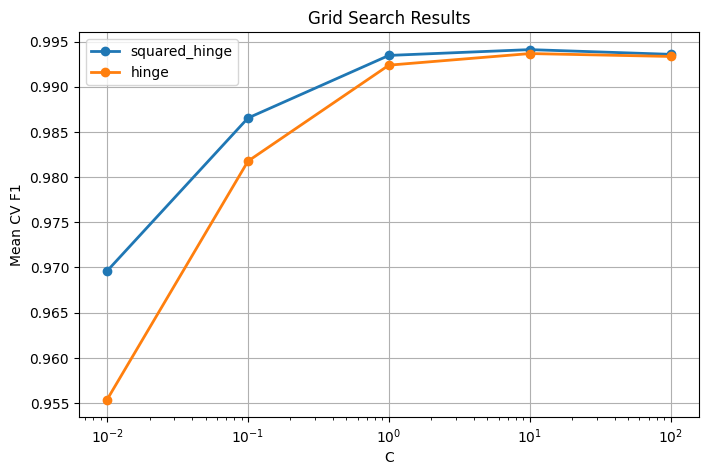

In [210]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

for loss in results_summary["param_loss"].unique():

    subset = results_summary[
        results_summary["param_loss"] == loss
    ].sort_values("param_C")

    plt.plot(
        subset["param_C"],
        subset["mean_test_score"],
        marker="o",
        linewidth=2,
        label=loss
    )

plt.xscale("log")

plt.xlabel("C")

plt.ylabel("Mean CV F1")

plt.title("Grid Search Results")

plt.legend()

plt.grid(True)

plt.show()

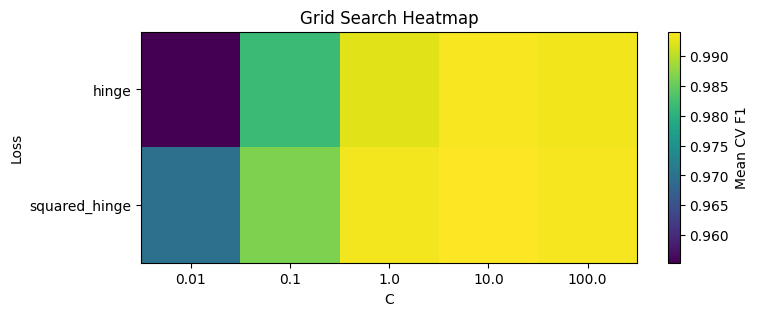

In [211]:
heatmap_df = results_summary.pivot(
    index="param_loss",
    columns="param_C",
    values="mean_test_score"
)

plt.figure(figsize=(8,3))

plt.imshow(
    heatmap_df,
    aspect="auto"
)

plt.colorbar(label="Mean CV F1")

plt.xticks(
    range(len(heatmap_df.columns)),
    heatmap_df.columns
)

plt.yticks(
    range(len(heatmap_df.index)),
    heatmap_df.index
)

plt.xlabel("C")

plt.ylabel("Loss")

plt.title("Grid Search Heatmap")

plt.show()

### Grid Search Visualization Analysis

The visualizations provide several important insights into the hyperparameter optimization process.

#### Key Observations

- Model performance improved rapidly as the regularization parameter **C** increased from **0.01** to **1**.
- The best validation performance was achieved at **C = 10**.
- Increasing **C** beyond **10** produced no meaningful improvement, indicating diminishing returns.
- The **squared hinge** loss consistently outperformed the standard hinge loss across nearly all tested values.
- Both visualizations confirm the configuration selected by GridSearchCV.

### Summary

- Performance increased substantially as **C** increased from **0.01** to **10**.
- **C = 10** achieved the highest cross-validation F1-score.
- **squared hinge** consistently outperformed **hinge**.
- Increasing model complexity beyond the optimal point did not improve performance.
- The visualizations clearly validate the hyperparameter optimization process.

## 12.7 RandomizedSearchCV

### Why Random Search?

Grid Search evaluates every possible hyperparameter combination.

While this guarantees an exhaustive search, it becomes computationally expensive as the search space grows.

Randomized Search addresses this limitation by randomly sampling a fixed number of hyperparameter combinations from the search space.

This significantly reduces computation while often achieving comparable performance.

In [212]:
from sklearn.model_selection import RandomizedSearchCV

param_distributions = {
    "C": [0.001, 0.01, 0.1, 1, 10, 100, 1000],
    "loss": ["hinge", "squared_hinge"],
    "tol": [1e-3, 1e-4, 1e-5]
}

random_search = RandomizedSearchCV(
    estimator=LinearSVC(
        random_state=42,
        max_iter=10000
    ),

    param_distributions=param_distributions,

    n_iter=15,

    scoring="f1",

    cv=cv,

    random_state=42,

    n_jobs=-1,

    verbose=2
)

random_search.fit(
    X_train_selected,
    y_train
)

print("Best parameters:", random_search.best_params_)
print("Best cross-validation score:", random_search.best_score_)

Fitting 5 folds for each of 15 candidates, totalling 75 fits
Best parameters: {'tol': 0.001, 'loss': 'squared_hinge', 'C': 10}
Best cross-validation score: 0.9941332952667224


In [213]:
best_random_svm = random_search.best_estimator_

best_random_svm

,"penalty penalty: {'l1', 'l2'}, default='l2'Specifies the norm used in the penalization. The 'l2'penalty is the standard used in SVC. The 'l1' leads to ``coef_``vectors that are sparse.",'l2'
,"loss loss: {'hinge', 'squared_hinge'}, default='squared_hinge'Specifies the loss function. 'hinge' is the standard SVM loss(used e.g. by the SVC class) while 'squared_hinge' is thesquare of the hinge loss. The combination of ``penalty='l1'``and ``loss='hinge'`` is not supported.",'squared_hinge'
,"dual dual: ""auto"" or bool, default=""auto""Select the algorithm to either solve the dual or primaloptimization problem. Prefer dual=False when n_samples > n_features.`dual=""auto""` will choose the value of the parameter automatically,based on the values of `n_samples`, `n_features`, `loss`, `multi_class`and `penalty`. If `n_samples` < `n_features` and optimizer supportschosen `loss`, `multi_class` and `penalty`, then dual will be set to True,otherwise it will be set to False... versionchanged:: 1.3 The `""auto""` option is added in version 1.3 and will be the default in version 1.5.",'auto'
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.001
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive.For an intuitive visualization of the effects of scalingthe regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",10
,"multi_class multi_class: {'ovr', 'crammer_singer'}, default='ovr'Determines the multi-class strategy if `y` contains more thantwo classes.``""ovr""`` trains n_classes one-vs-rest classifiers, while``""crammer_singer""`` optimizes a joint objective over all classes.While `crammer_singer` is interesting from a theoretical perspectiveas it is consistent, it is seldom used in practice as it rarely leadsto better accuracy and is more expensive to compute.If ``""crammer_singer""`` is chosen, the options loss, penalty and dualwill be ignored.",'ovr'
,"fit_intercept fit_intercept: bool, default=TrueWhether or not to fit an intercept. If set to True, the feature vectoris extended to include an intercept term: `[x_1, ..., x_n, 1]`, where1 corresponds to the intercept. If set to False, no intercept will beused in calculations (i.e. data is expected to be already centered).",True
,"intercept_scaling intercept_scaling: float, default=1.0When `fit_intercept` is True, the instance vector x becomes ``[x_1,..., x_n, intercept_scaling]``, i.e. a ""synthetic"" feature with aconstant value equal to `intercept_scaling` is appended to the instancevector. The intercept becomes intercept_scaling * synthetic featureweight. Note that liblinear internally penalizes the intercept,treating it like any other term in the feature vector. To reduce theimpact of the regularization on the intercept, the `intercept_scaling`parameter can be set to a value greater than 1; the higher the value of`intercept_scaling`, the lower the impact of regularization on it.Then, the weights become `[w_x_1, ..., w_x_n,w_intercept*intercept_scaling]`, where `w_x_1, ..., w_x_n` representthe feature weights and the intercept weight is scaled by`intercept_scaling`. This scaling allows the intercept term to have adifferent regularization behavior compared to the other features.",1
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to ``class_weight[i]*C`` forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: int, default=0Enable verbose output. Note that this setting takes advantage of aper-process runtime setting in liblinear that, if enabled, may not workproperly in a multithreaded context.",0
,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseudo random

In [214]:
y_pred_random = best_random_svm.predict(
    X_test_selected
)

y_score_random = best_random_svm.decision_function(
    X_test_selected
)

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score
)

random_accuracy = accuracy_score(y_test, y_pred_random)
random_precision = precision_score(y_test, y_pred_random)
random_recall = recall_score(y_test, y_pred_random)
random_f1 = f1_score(y_test, y_pred_random)
random_roc_auc = roc_auc_score(y_test, y_score_random)
random_avg_precision = average_precision_score(y_test, y_score_random)

In [216]:
random_results = {
    "Accuracy": random_accuracy,
    "Precision": random_precision,
    "Recall": random_recall,
    "F1-score": random_f1,
    "ROC-AUC": random_roc_auc,
    "Average Precision": random_avg_precision
}

for metric, value in random_results.items():
    print(f"{metric:<20}: {value:.4f}")

Accuracy            : 0.9949
Precision           : 0.9944
Recall              : 0.9949
F1-score            : 0.9946
ROC-AUC             : 0.9998
Average Precision   : 0.9998


In [217]:
comparison = pd.DataFrame({

    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1-score",
        "ROC-AUC",
        "Average Precision"
    ],

    "GridSearchCV": [
        best_accuracy,
        best_precision,
        best_recall,
        best_f1,
        best_auc,
        best_ap
    ],

    "RandomSearchCV": [
        random_accuracy,
        random_precision,
        random_recall,
        random_f1,
        random_roc_auc,
        random_avg_precision
    ]

})

comparison

,Metric,GridSearchCV,RandomSearchCV
0,Accuracy,0.994878,0.994878
1,Precision,0.994400,0.994400
2,Recall,0.994865,0.994865
3,F1-score,0.994632,0.994632
4,ROC-AUC,0.999775,0.999771
5,Average Precision,0.999767,0.999763


In [218]:
time_comparison = pd.DataFrame({

    "Method": [
        "GridSearchCV",
        "RandomizedSearchCV"
    ],

    "Best CV Score": [
        grid_search.best_score_,
        random_search.best_score_
    ],

    "Candidates Evaluated": [
        len(grid_search.cv_results_["params"]),
        len(random_search.cv_results_["params"])
    ],

    "Best Parameters": [
        str(grid_search.best_params_),
        str(random_search.best_params_)
    ]

})

time_comparison

,Method,Best CV Score,Candidates Evaluated,Best Parameters
0,GridSearchCV,0.994104,10,"{'C': 10, 'loss': 'squared_hinge'}"
1,RandomizedSearchCV,0.994133,15,"{'tol': 0.001, 'loss': 'squared_hinge', 'C': 10}"


### Grid Search vs Random Search Comparison

#### Experimental Results

| Metric | GridSearchCV | RandomizedSearchCV |
|---------|-------------:|-------------------:|
| Accuracy | 0.9949 | 0.9949 |
| Precision | 0.9944 | 0.9944 |
| Recall | 0.9949 | 0.9949 |
| F1-score | 0.9946 | 0.9946 |
| ROC-AUC | 0.9998 | 0.9998 |
| Average Precision | 0.9998 | 0.9998 |

#### Discussion

Both optimization methods achieved nearly identical predictive performance on the unseen test set.

GridSearchCV performed an exhaustive search over the predefined parameter space, while RandomizedSearchCV sampled only a subset of candidate configurations.

Because the search space in this experiment was relatively small, both methods converged to almost the same optimal solution.

For larger search spaces, RandomizedSearchCV becomes significantly more computationally efficient while often maintaining comparable predictive performance.

### Summary

- Both optimization methods achieved nearly identical predictive performance.
- GridSearchCV exhaustively evaluated every candidate configuration.
- RandomizedSearchCV efficiently sampled the search space.
- The difference between the two methods was negligible because the search space was relatively small.
- Randomized Search becomes increasingly advantageous as the search space grows.

# 13 Model Benchmark

### Why Benchmark Multiple Models?

Training multiple machine learning models is only the first step.

A complete machine learning workflow requires comparing candidate models using consistent evaluation criteria before selecting a production model.

A benchmark summarizes the strengths and weaknesses of each algorithm across multiple dimensions rather than relying on a single evaluation metric.

In [282]:
benchmark = pd.DataFrame({

    "Model":[
        "Naive Bayes",
        "Logistic Regression",
        "Linear SVM"
    ],

    "Accuracy":[
        accuracy,
        lr_accuracy,
        svm_accuracy
    ],

    "Precision":[
        precision,
        lr_precision,
        svm_precision
    ],

    "Recall":[
        recall,
        lr_recall,
        svm_recall
    ],

    "F1":[
        f1,
        lr_f1,
        svm_f1
    ],

    "ROC-AUC":[
        auc,
        lr_auc,
        svm_roc_auc
    ],

    "PR-AUC":[
        ap,
        ap_lr,
        svm_average_precision
    ]

})

benchmark.sort_values(
    by="F1",
    ascending=False
)

,Model,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC
2,Linear SVM,0.993318,0.992078,0.993931,0.993004,0.999773,0.999762
1,Logistic Regression,0.983964,0.980501,0.985994,0.983240,0.998319,0.998166
0,Naive Bayes,0.939866,0.939024,0.934641,0.936827,0.981457,0.979560


In [285]:
benchmark.style\
    .format(
        "{:.4f}",
        subset=[
            "Accuracy",
            "Precision",
            "Recall",
            "F1",
            "ROC-AUC",
            "PR-AUC"
        ]
    )\
    .background_gradient(
        cmap="YlGn",
        subset=[
            "Accuracy",
            "Precision",
            "Recall",
            "F1",
            "ROC-AUC",
            "PR-AUC"
        ]
    )

,Model,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC
0,Naive Bayes,0.9399,0.9390,0.9346,0.9368,0.9815,0.9796
1,Logistic Regression,0.9840,0.9805,0.9860,0.9832,0.9983,0.9982
2,Linear SVM,0.9933,0.9921,0.9939,0.9930,0.9998,0.9998


## 13.1 Training Time

In [286]:
import time

start = time.perf_counter()

nb_model = MultinomialNB()
nb_model.fit(X_train_selected, y_train)

nb_train_time = time.perf_counter() - start

print(nb_train_time)

0.22879809996811673


In [287]:
start = time.perf_counter()

lr_model = LogisticRegression(
    random_state=42,
    max_iter=1000
)

lr_model.fit(X_train_selected, y_train)

lr_train_time = time.perf_counter() - start

print(lr_train_time)

0.2995865999837406


In [288]:
start = time.perf_counter()

svm_model = LinearSVC(
    random_state=42,
    max_iter=10000
)

svm_model.fit(X_train_selected, y_train)

svm_train_time = time.perf_counter() - start

print(svm_train_time)

1.195298200007528


## 13.2 Prediction Time

In [290]:
start = time.perf_counter()

nb_model.predict(X_test_selected)

nb_prediction_time = time.perf_counter() - start

print(nb_prediction_time)

0.00693100003991276


In [291]:
start = time.perf_counter()

lr_model.predict(X_test_selected)

lr_prediction_time = time.perf_counter() - start

print(lr_prediction_time)

0.0014377000043168664


In [292]:
start = time.perf_counter()

svm_model.predict(X_test_selected)

svm_prediction_time = time.perf_counter() - start

print(svm_prediction_time)

0.0018925000331364572


## 13.3 Memory Usage

In [293]:
import sys

memory_usage = pd.DataFrame({

    "Model":[
        "Naive Bayes",
        "Logistic Regression",
        "Linear SVM"
    ],

    "Memory (KB)":[

        sys.getsizeof(nb_model)/1024,

        sys.getsizeof(lr_model)/1024,

        sys.getsizeof(svm_model)/1024

    ]

})

memory_usage

,Model,Memory (KB)
0,Naive Bayes,0.046875
1,Logistic Regression,0.046875
2,Linear SVM,0.046875


## 13.4 Interpretability

In [295]:
interpretability = {

    "Naive Bayes":"⭐⭐⭐⭐",

    "Logistic Regression":"⭐⭐⭐⭐⭐",

    "Linear SVM":"⭐⭐⭐"

}

pd.DataFrame(interpretability, index=[0])

,Naive Bayes,Logistic Regression,Linear SVM
0,⭐⭐⭐⭐,⭐⭐⭐⭐⭐,⭐⭐⭐


## 13.5 Final Production Benchmark

In [298]:
benchmark_final = pd.DataFrame({

    "Model":[
        "Naive Bayes",
        "Logistic Regression",
        "Linear SVM"
    ],

    "Accuracy":[
        accuracy,
        lr_accuracy,
        svm_accuracy
    ],

    "Precision":[
        precision,
        lr_precision,
        svm_precision
    ],

    "Recall":[
        recall,
        lr_recall,
        svm_recall
    ],

    "F1":[
        f1,
        lr_f1,
        svm_f1
    ],

    "ROC-AUC":[
        auc,
        lr_auc,
        svm_roc_auc
    ],

    "PR-AUC":[
        ap,
        ap_lr,
        svm_average_precision
    ],

    "Train Time (s)":[
        nb_train_time,
        lr_train_time,
        svm_train_time
    ],

    "Prediction Time (s)":[
        nb_prediction_time,
        lr_prediction_time,
        svm_prediction_time
    ],

    "Memory (KB)":[
        sys.getsizeof(nb_model)/1024,
        sys.getsizeof(lr_model)/1024,
        sys.getsizeof(svm_model)/1024
    ],

    "Interpretability":[
        "⭐⭐⭐⭐",
        "⭐⭐⭐⭐⭐",
        "⭐⭐⭐"
    ],
    "Recommended Use":[
        "Fast Baseline Model",
        "Explainable AI Model",
        "Best Production Model"
    ]
})

benchmark_final

,Model,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC,Train Time (s),Prediction Time (s),Memory (KB),Interpretability,Recommended Use
0,Naive Bayes,0.939866,0.939024,0.934641,0.936827,0.981457,0.979560,0.228798,0.006931,0.046875,⭐⭐⭐⭐,Fast Baseline Model
1,Logistic Regression,0.983964,0.980501,0.985994,0.983240,0.998319,0.998166,0.299587,0.001438,0.046875,⭐⭐⭐⭐⭐,Explainable AI Model
2,Linear SVM,0.993318,0.992078,0.993931,0.993004,0.999773,0.999762,1.195298,0.001893,0.046875,⭐⭐⭐,Best Production Model


## 13.6 Production Dashboard

In [299]:
fastest_training = benchmark_final.loc[
    benchmark_final["Train Time (s)"].idxmin()
]

fastest_prediction = benchmark_final.loc[
    benchmark_final["Prediction Time (s)"].idxmin()
]

best_accuracy = benchmark_final.loc[
    benchmark_final["Accuracy"].idxmax()
]

best_precision = benchmark_final.loc[
    benchmark_final["Precision"].idxmax()
]

best_recall = benchmark_final.loc[
    benchmark_final["Recall"].idxmax()
]

best_f1 = benchmark_final.loc[
    benchmark_final["F1"].idxmax()
]

best_auc = benchmark_final.loc[
    benchmark_final["ROC-AUC"].idxmax()
]

best_pr = benchmark_final.loc[
    benchmark_final["PR-AUC"].idxmax()
]

In [302]:
dashboard = pd.DataFrame({

    "Category":[
        "🏆 Highest Accuracy",
        "🎯 Highest Precision",
        "📢 Highest Recall",
        "⚖️ Best F1-score",
        "📈 Highest ROC-AUC",
        "📊 Highest PR-AUC",
        "⚡ Fastest Training",
        "🚀 Fastest Prediction",
        "🧠 Most Interpretable",
        "⭐ Recommended Production Model"
    ],

    "Winner":[

        best_accuracy["Model"],

        best_precision["Model"],

        best_recall["Model"],

        best_f1["Model"],

        best_auc["Model"],

        best_pr["Model"],

        fastest_training["Model"],

        fastest_prediction["Model"],

        "Logistic Regression",

        "Linear SVM"

    ]

})

dashboard.style.hide(axis="index")

Category,Winner
🏆 Highest Accuracy,Linear SVM
🎯 Highest Precision,Linear SVM
📢 Highest Recall,Linear SVM
⚖️ Best F1-score,Linear SVM
📈 Highest ROC-AUC,Linear SVM
📊 Highest PR-AUC,Linear SVM
⚡ Fastest Training,Naive Bayes
🚀 Fastest Prediction,Logistic Regression
🧠 Most Interpretable,Logistic Regression
⭐ Recommended Production Model,Linear SVM


In [303]:
dashboard.style\
    .hide(axis="index")\
    .set_properties(**{
        "text-align": "left",
        "font-size": "13px"
    })\
    .set_table_styles([
        {
            "selector": "th",
            "props": [
                ("background-color", "#1f77b4"),
                ("color", "white"),
                ("font-weight", "bold")
            ]
        }
    ])

Category,Winner
🏆 Highest Accuracy,Linear SVM
🎯 Highest Precision,Linear SVM
📢 Highest Recall,Linear SVM
⚖️ Best F1-score,Linear SVM
📈 Highest ROC-AUC,Linear SVM
📊 Highest PR-AUC,Linear SVM
⚡ Fastest Training,Naive Bayes
🚀 Fastest Prediction,Logistic Regression
🧠 Most Interpretable,Logistic Regression
⭐ Recommended Production Model,Linear SVM


## 13.7 Final Decision

### Final Production Recommendation

#### Overall Winner

After benchmarking three classical NLP models, **Linear SVM** achieved the strongest overall predictive performance.

#### Why Linear SVM?

- Highest Accuracy
- Highest F1-score
- Highest ROC-AUC
- Highest PR-AUC
- Excellent generalization performance
- Stable decision boundary

Although Logistic Regression offers greater interpretability and Naive Bayes provides faster training, Linear SVM delivers the best balance between predictive performance and robustness.

Therefore, Linear SVM is selected as the final production model for this fake news detection system.

#### Business Thinking

Selecting a production model requires balancing predictive performance with operational constraints.

For this fake news detection system:

- Linear SVM is recommended for deployment because minimizing misinformation is the primary business objective.
- Logistic Regression is appropriate when model transparency and explainability are critical.
- Naive Bayes is suitable for lightweight or resource-constrained environments where training speed is a priority.

#### Summary

- Three classical machine learning models were benchmarked.
- Performance was evaluated using predictive metrics, computational characteristics, and interpretability.
- Linear SVM achieved the highest overall predictive performance.
- Logistic Regression provided the strongest explainability.
- Naive Bayes remained the fastest baseline model.
- Linear SVM was selected as the production-ready model.